# Capstone Graduation Project - Machine Learning
## E-Commerce: Model 1, Model 2, Model 3,  Model 4 and Model5



**Models:**
- **Model 1:** Return Prediction (Binary Classification)
- **Model 2:** Delivery Delay Prediction (Binary Classification)
- **Model 3:** Customer Rating Prediction (Regression)
- **Model 4:** Customer Segmentation (Unsupervised Clustering)
- **Model 5:** Revenue Prediction (Regression
)

**Dataset:** Brazilian E-Commerce Public Dataset by Olist  
**Random State:** 42

> **Important dataset note:** The project brief requires some fields that do not exist directly in the Olist dataset. This notebook documents each substitution/proxy instead of fabricating columns.

## 1. Business Understanding

This notebook contains the shared data preparation phase followed by five machine-learning models in the requested order.

### Model 1 - Return Prediction
**Business problem:** Predict whether an order is likely to become a return/cancellation-type outcome.  
**ML task:** Binary classification using a documented cancellation proxy for returns.

### Model 2 - Delivery Delay Prediction
**Business problem:** Predict whether an order will be delivered after its estimated delivery date.  
**ML task:** Binary classification using delivery timestamps and order, seller, product, payment, and geography features.

### Model 3 - Customer Rating Prediction
**Business problem:** Predict customer review rating from order and product context.  
**ML task:** Regression on `review_score`, with raw-vs-log target comparison and diagnostic plots.

### Model 4 - Customer Segmentation
**Business problem:** Discover natural customer groups for retention, engagement, and revenue strategy.  
**ML task:** Unsupervised clustering using RFM and behavioral features.

### Model 5 - Revenue Prediction
**Business problem:** Predict the net revenue an order will generate to support revenue forecasting, pricing decisions, and promotion planning.  
**ML task:** Regression on `net_revenue`, with raw-vs-log target comparison and diagnostic plots.

The shared phase loads, audits, cleans, engineers features, and performs EDA once so all five model sections reuse the same foundation.

## 2. Imports

In [1]:
# Shared + model-specific imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix
)
# Model 4 imports
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
RANDOM_STATE = 42

print("All libraries loaded successfully.")


All libraries loaded successfully.


## Project Order

The notebook is organized as one unified capstone file:

1. **Shared Phase:** Business understanding, imports, data loading/audit, preprocessing, feature engineering, and EDA.
2. **Model 1:** Return Prediction - binary classification.
3. **Model 2:** Delivery Delay Prediction - binary classification.
4. **Model 3:** Customer Rating Prediction - regression.
5. **Model 4:** Customer Segmentation - unsupervised clustering.

This ordering keeps the common preparation steps in one place, then presents the individual model work in the requested 1 -> 2 -> 3 -> 4 sequence.

## PDF Requirement Coverage Note

This unified notebook covers the shared phase plus Models 1-4 from the capstone PDF. Model 5 is intentionally not included yet.

- **Shared phase:** load/audit, preprocessing, feature engineering, EDA, and insight blocks.
- **Model 1:** return/cancellation prediction, four classifiers, imbalance comparison, tuning, metrics, confusion matrix, ROC curve, feature importance, error analysis, recommendations, limitations, export.
- **Model 2:** delivery-delay prediction, four classifiers, imbalance comparison, tuning, final metrics, confusion matrix, ROC curve, feature importance, seller delay-rate analysis, recommendations, limitations/export.
- **Model 3:** rating regression, four regressors, target distribution, raw-vs-log comparison, tuning, MAE/RMSE/R-squared, diagnostic plots, category error analysis, business insights, export.
- **Model 4:** RFM/customer segmentation, K-Means/DBSCAN/Hierarchical comparison, elbow/silhouette analysis, Davies-Bouldin, segment sizes, segment profiles, recommendations, limitations, export.

## 3. Load Data & 4. Data Audit

Raw multi-table load, merge, and full data-quality audit (shape, `info()`, missing values, duplicates, hidden nulls).

In [2]:
# Import necessary libraries and set display options
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

import kagglehub
import os

In [3]:
# Download the Brazilian E-commerce dataset from Kaggle and list its contents
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Path to dataset files:", path)

dataset_files = os.listdir(path)
print("Files in the dataset directory:")
for f in dataset_files:
    print(" -", f)

Path to dataset files: C:\Users\Lenovo\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2
Files in the dataset directory:
 - olist_customers_dataset.csv
 - olist_geolocation_dataset.csv
 - olist_orders_dataset.csv
 - olist_order_items_dataset.csv
 - olist_order_payments_dataset.csv
 - olist_order_reviews_dataset.csv
 - olist_products_dataset.csv
 - olist_sellers_dataset.csv
 - product_category_name_translation.csv


In [4]:
# Load each CSV file into a pandas DataFrame
orders = pd.read_csv(os.path.join(path, 'olist_orders_dataset.csv'))
order_items = pd.read_csv(os.path.join(path, 'olist_order_items_dataset.csv'))
order_payments = pd.read_csv(os.path.join(path, 'olist_order_payments_dataset.csv'))
order_reviews = pd.read_csv(os.path.join(path, 'olist_order_reviews_dataset.csv'))
products = pd.read_csv(os.path.join(path, 'olist_products_dataset.csv'))
customers = pd.read_csv(os.path.join(path, 'olist_customers_dataset.csv'))
sellers = pd.read_csv(os.path.join(path, 'olist_sellers_dataset.csv'))
category_translation = pd.read_csv(os.path.join(path, 'product_category_name_translation.csv'))

# Print the shape of each DataFrame
print("orders:", orders.shape)
print("order_items:", order_items.shape)
print("order_payments:", order_payments.shape)
print("order_reviews:", order_reviews.shape)
print("products:", products.shape)
print("customers:", customers.shape)
print("sellers:", sellers.shape)

orders: (99441, 8)
order_items: (112650, 7)
order_payments: (103886, 5)
order_reviews: (99224, 7)
products: (32951, 9)
customers: (99441, 5)
sellers: (3095, 4)


In [5]:
# Merge all DataFrames into a single DataFrame 'df' for comprehensive analysis
df = orders.merge(order_items, on='order_id', how='left')

# Add product information (category, weight, dimensions)
df = df.merge(products, on='product_id', how='left')

# Translate product category names to English for better readability
df = df.merge(category_translation, on='product_category_name', how='left')

# Add customer information (location)
df = df.merge(customers, on='customer_id', how='left')

# Add seller information (location)
df = df.merge(sellers, on='seller_id', how='left')

# Aggregate payment information to avoid duplicating rows and merge with 'df'
payments_agg = (
    order_payments
    .groupby('order_id')
    .agg(
        payment_type=('payment_type', 'first'),
        payment_installments=('payment_installments', 'max'),
        payment_value=('payment_value', 'sum')
    )
    .reset_index()
)
df = df.merge(payments_agg, on='order_id', how='left')

# Deduplicate review information, keeping the most recent review per order, and merge
reviews_dedup = (
    order_reviews
    .sort_values('review_creation_date')
    .drop_duplicates(subset='order_id', keep='last')
)
df = df.merge(
    reviews_dedup[['order_id', 'review_score', 'review_comment_title',
                   'review_comment_message', 'review_creation_date',
                   'review_answer_timestamp']],
    on='order_id', how='left'
)

df_raw = df.copy()  # Preserve an untouched copy of the merged DataFrame

# Print the final shape and display the head and tail of the merged DataFrame
print("\nFinal merged shape:", df.shape)
print(df.head())
print(df.tail())


Final merged shape: (113425, 38)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          201

In [6]:
# Display DataFrame information, descriptive statistics, and missing values
df.info()
display(df.describe(include='all').T)

# Calculate and display missing values count and percentage
missing = pd.DataFrame({
    'count': df.isna().sum(),
    'percent': df.isna().mean().mul(100).round(2)
}).sort_values('percent', ascending=False)
print(missing)

# Check for exact duplicate rows and duplicate 'order_id's
print('Exact duplicates:', df.duplicated().sum())
print('Duplicate order_id (item-level rows expected):',
      df.duplicated('order_id', keep=False).sum())

# Check for hidden null values (e.g., 'NA', 'Null') in object columns before cleaning
hidden_null_values = ['NA', 'N/A', 'Null', '-', '']
print("\nHidden nulls BEFORE cleaning:")
for col in df.select_dtypes(include='object').columns:
    count = df[col].isin(hidden_null_values).sum()
    if count > 0:
        print(col, count)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 38 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  object 
 1   customer_id                    113425 non-null  object 
 2   order_status                   113425 non-null  object 
 3   order_purchase_timestamp       113425 non-null  object 
 4   order_approved_at              113264 non-null  object 
 5   order_delivered_carrier_date   111457 non-null  object 
 6   order_delivered_customer_date  110196 non-null  object 
 7   order_estimated_delivery_date  113425 non-null  object 
 8   order_item_id                  112650 non-null  float64
 9   product_id                     112650 non-null  object 
 10  seller_id                      112650 non-null  object 
 11  shipping_limit_date            112650 non-null  object 
 12  price                         

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,113425,99441,8272b63d03f5f79c56e9e4120aec44ef,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,113425,99441,fc3d1daec319d62d49bfb5e1f83123e9,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,113425,8,delivered,110197,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,113425,98875,2017-07-16 18:19:25,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_approved_at,113264,90733,2018-02-24 03:20:27,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_delivered_carrier_date,111457,81018,2018-05-09 15:48:00,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_delivered_customer_date,110196,95664,2017-07-31 18:03:02,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_estimated_delivery_date,113425,459,2017-12-20 00:00:00,611,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_item_id,"112,650.00",NaN,NaN,NaN,1.20,0.71,1.00,1.00,1.00,1.00,21.00
product_id,112650,32951,aca2eb7d00ea1a7b8ebd4e68314663af,527,NaN,NaN,NaN,NaN,NaN,NaN,NaN


                               count  percent
review_comment_title           99919    88.09
review_comment_message         65501    57.75
order_delivered_customer_date   3229     2.85
product_category_name_english   2402     2.12
product_description_lenght      2378     2.10
product_photos_qty              2378     2.10
product_name_lenght             2378     2.10
product_category_name           2378     2.10
order_delivered_carrier_date    1968     1.74
review_score                     961     0.85
review_answer_timestamp          961     0.85
review_creation_date             961     0.85
product_width_cm                 793     0.70
product_height_cm                793     0.70
product_length_cm                793     0.70
product_weight_g                 793     0.70
seller_zip_code_prefix           775     0.68
order_item_id                    775     0.68
freight_value                    775     0.68
price                            775     0.68
product_id                       7

## 5. Preprocessing

Clean column names, standardize text, fix dtypes, handle missing values (documented per-column), validate business rules (dates, prices), remove duplicates.

In [7]:
# Standardize column names by stripping spaces, lowercasing, and replacing spaces with underscores
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

In [8]:
# Standardize text columns by stripping whitespace and lowercasing
text_cols = df.select_dtypes(include='object').columns.tolist()
print("\nStandardizing these text columns:", text_cols)

for col in text_cols:
    # Skip free-text review comment fields as lowercasing/stripping is not meaningful
    if col in ['review_comment_title', 'review_comment_message']:
        continue
    df[col] = df[col].astype(str).str.strip().str.lower()
    df[col] = df[col].replace('nan', np.nan)  # Convert string 'nan' back to actual NaN

print("\nUnique values in 'order_status' AFTER standardization:")
print(df['order_status'].unique())


Standardizing these text columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'product_id', 'seller_id', 'shipping_limit_date', 'product_category_name', 'product_category_name_english', 'customer_unique_id', 'customer_city', 'customer_state', 'seller_city', 'seller_state', 'payment_type', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

Unique values in 'order_status' AFTER standardization:
['delivered' 'invoiced' 'shipped' 'processing' 'unavailable' 'canceled'
 'created' 'approved']


In [9]:
# Convert specified columns to datetime objects
datetime_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',
    'review_creation_date',
    'review_answer_timestamp',
]
for col in datetime_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Convert specified columns to numeric types
numeric_cols = ['price', 'freight_value', 'payment_value',
                 'payment_installments', 'review_score',
                 'product_weight_g', 'product_length_cm',
                 'product_height_cm', 'product_width_cm']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert specified columns to categorical types
categorical_cols = ['order_status', 'payment_type',
                     'product_category_name_english',
                     'customer_state', 'seller_state']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 38 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  object        
 1   customer_id                    113425 non-null  object        
 2   order_status                   113425 non-null  category      
 3   order_purchase_timestamp       113425 non-null  datetime64[ns]
 4   order_approved_at              113264 non-null  datetime64[ns]
 5   order_delivered_carrier_date   111457 non-null  datetime64[ns]
 6   order_delivered_customer_date  110196 non-null  datetime64[ns]
 7   order_estimated_delivery_date  113425 non-null  datetime64[ns]
 8   order_item_id                  112650 non-null  float64       
 9   product_id                     112650 non-null  object        
 10  seller_id                      112650 non-null  object        
 11  

In [10]:
# Re-check for hidden null values in object columns AFTER cleaning
print("\nHidden nulls AFTER cleaning:")
found_any = False
for col in df.select_dtypes(include='object').columns:
    count = df[col].isin(hidden_null_values).sum()
    if count > 0:
        print(col, count)
        found_any = True
if not found_any:
    print("None found.")


Hidden nulls AFTER cleaning:
review_comment_title 1
review_comment_message 5


In [11]:
# Display missing values before handling
print("\nMissing values BEFORE handling:")
missing_before_handling = pd.DataFrame({
    'count': df.isna().sum(),
    'percent': df.isna().mean().mul(100).round(2)
}).sort_values('percent', ascending=False)
print(missing_before_handling)

# Capture missing counts for audit log before any changes
missing_order_approved_before = df['order_approved_at'].isna().sum()
missing_carrier_before = df['order_delivered_carrier_date'].isna().sum()
missing_customer_delivery_before = df['order_delivered_customer_date'].isna().sum()
missing_review_score_before = df['review_score'].isna().sum() if 'review_score' in df.columns else 0
missing_price_before = df['price'].isna().sum() if 'price' in df.columns else 0

# --- Apply the handling rules ---

# Drop rows where 'order_approved_at' is missing, as these orders were never approved
df.dropna(subset=['order_approved_at'], inplace=True)
print(f"\nDropped rows with missing 'order_approved_at'. "
      f"New DataFrame shape: {df.shape}")

# 'order_delivered_carrier_date' and 'order_delivered_customer_date' missing values (NaT) are kept as they are informative (order not yet at that stage)
# 'review_score' missing values are kept as null (customer did not leave a review)
# 'price' missing values are kept as null and flagged for later handling

# Display missing values after handling
print("\nMissing values AFTER handling:")
missing_final = pd.DataFrame({
    'count': df.isna().sum(),
    'percent': df.isna().mean().mul(100).round(2)
}).sort_values('percent', ascending=False)
print(missing_final)


Missing values BEFORE handling:
                               count  percent
review_comment_title           99919    88.09
review_comment_message         65501    57.75
order_delivered_customer_date   3229     2.85
product_category_name_english   2402     2.12
product_description_lenght      2378     2.10
product_photos_qty              2378     2.10
product_name_lenght             2378     2.10
product_category_name           2378     2.10
order_delivered_carrier_date    1968     1.74
review_score                     961     0.85
review_answer_timestamp          961     0.85
review_creation_date             961     0.85
product_width_cm                 793     0.70
product_height_cm                793     0.70
product_length_cm                793     0.70
product_weight_g                 793     0.70
seller_zip_code_prefix           775     0.68
order_item_id                    775     0.68
freight_value                    775     0.68
price                            775     0.68
p

In [12]:
# Check for invalid 'price' (less than or equal to 0) and 'freight_value' (less than 0) rows
invalid_price = df[df['price'] <= 0] if 'price' in df.columns else pd.DataFrame()
invalid_freight = df[df['freight_value'] < 0] if 'freight_value' in df.columns else pd.DataFrame()

print('Invalid price rows (<= 0):', len(invalid_price))
print('Invalid freight rows (< 0):', len(invalid_freight))

# Perform chronological consistency checks for order dates
invalid_approved_date = df[df['order_approved_at'] < df['order_purchase_timestamp']]
invalid_carrier_date = df[df['order_delivered_carrier_date'] < df['order_approved_at']]
invalid_customer_delivery_date = df[
    df['order_delivered_customer_date'] < df['order_delivered_carrier_date']
]

print('Invalid: Approved before purchase (rows):', len(invalid_approved_date))
print('Invalid: Carrier delivered before approved (rows):', len(invalid_carrier_date))
print('Invalid: Customer delivered before carrier (rows):',
      len(invalid_customer_delivery_date))

Invalid price rows (<= 0): 0
Invalid freight rows (< 0): 0
Invalid: Approved before purchase (rows): 0
Invalid: Carrier delivered before approved (rows): 1551
Invalid: Customer delivered before carrier (rows): 50


In [13]:
# Check for invalid 'price' (less than or equal to 0) and 'freight_value' (less than 0) rows
invalid_price = df[df['price'] <= 0] if 'price' in df.columns else pd.DataFrame()
invalid_freight = df[df['freight_value'] < 0] if 'freight_value' in df.columns else pd.DataFrame()

print('Invalid price rows (<= 0):', len(invalid_price))
print('Invalid freight rows (< 0):', len(invalid_freight))

# Perform chronological consistency checks for order dates
invalid_approved_date = df[df['order_approved_at'] < df['order_purchase_timestamp']]
invalid_carrier_date = df[df['order_delivered_carrier_date'] < df['order_approved_at']]
invalid_customer_delivery_date = df[
    df['order_delivered_customer_date'] < df['order_delivered_carrier_date']
]

print('Invalid: Approved before purchase (rows):', len(invalid_approved_date))
print('Invalid: Carrier delivered before approved (rows):', len(invalid_carrier_date))
print('Invalid: Customer delivered before carrier (rows):',
      len(invalid_customer_delivery_date))

Invalid price rows (<= 0): 0
Invalid freight rows (< 0): 0
Invalid: Approved before purchase (rows): 0
Invalid: Carrier delivered before approved (rows): 1551
Invalid: Customer delivered before carrier (rows): 50


In [14]:
# Identify and remove exact duplicate rows from the DataFrame
duplicates_to_remove = df[df.duplicated()]
print(f"\nExact duplicate rows found: {len(duplicates_to_remove)}")
print(duplicates_to_remove.head())

df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

# ============================================================
# 12. Audit log — now using the BEFORE counts captured in step 9,
#     not the counts after dropna (which were always 0)
# ============================================================
# Create an audit log summarizing missing value handling decisions
audit_log = pd.DataFrame({
    'column':[
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'review_score',
        'price',
    ],
    'missing_count_before_handling': [
        missing_order_approved_before,
        missing_carrier_before,
        missing_customer_delivery_before,
        missing_review_score_before,
        missing_price_before,
    ],
    'action_taken': [
        'Dropped rows',
        'Kept NaT values',
        'Kept NaT values',
        'Kept null',
        'Kept null (flagged for Person 2)',
    ],
    'reason': [
        'Order was never approved — removing aligns with analysis goals.',
        'Absence of date indicates event not yet occurred; considered informative.',
        'Absence of date indicates event not yet occurred; considered informative.',
        'Null means the customer never left a review — not an error, must not be faked.',
        'Row could not be matched to a priced item; revenue features will need to '
        'handle or exclude these rows explicitly.',
    ]
})
print(audit_log)


Exact duplicate rows found: 0
Empty DataFrame
Columns: [order_id, customer_id, order_status, order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date, order_item_id, product_id, seller_id, shipping_limit_date, price, freight_value, product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm, product_category_name_english, customer_unique_id, customer_zip_code_prefix, customer_city, customer_state, seller_zip_code_prefix, seller_city, seller_state, payment_type, payment_installments, payment_value, review_score, review_comment_title, review_comment_message, review_creation_date, review_answer_timestamp]
Index: []
Shape after removing duplicates: (113264, 38)
                          column  missing_count_before_handling  \
0              order_approved_at                            161   
1   order_deliv

In [15]:
# Save the cleaned DataFrame to a CSV file
df.to_csv('clean_orders_step1.csv', index=False)
# Display the shape comparison before and after cleaning
print('Before:', df_raw.shape, '-> After:', df.shape)
print('\nFinal columns:', df.columns.tolist())

Before: (113425, 38) -> After: (113264, 38)

Final columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'payment_type', 'payment_installments', 'payment_value', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']


## 6. Feature Engineering

Derived features: delivery timing, revenue aggregates, calendar features, product physical attributes, review/target-adjacent flags.

In [16]:
# --- Delivery features ---
# Actual and expected delivery time, measured in days from purchase
df['delivery_days_actual'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

df['delivery_days_expected'] = (
    df['order_estimated_delivery_date'] - df['order_purchase_timestamp']
).dt.days

# Delivery delay = how many days late (positive) or early (negative) vs the ESTIMATE
df['delivery_delay'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.days

# is_late = 1 if the order arrived after the estimated delivery date
df['is_late'] = (df['delivery_delay'] > 0).astype('Int64')
# NaN when the order was never delivered (delivery_delay is NaT-derived NaN) — keep as null, not 0
df.loc[df['delivery_delay'].isna(), 'is_late'] = pd.NA

# is_delivered = has the order actually reached the customer
df['is_delivered'] = df['order_delivered_customer_date'].notna().astype(int)

print(df[['delivery_days_actual', 'delivery_days_expected', 'delivery_delay', 'is_late', 'is_delivered']].describe(include='all'))


       delivery_days_actual  delivery_days_expected  delivery_delay  \
count            110,181.00              113,264.00      110,181.00   
mean                  12.01                   23.47          -12.03   
std                    9.45                    8.88           10.16   
min                    0.00                    2.00         -147.00   
25%                    6.00                   18.00          -17.00   
50%                   10.00                   23.00          -13.00   
75%                   15.00                   28.00           -7.00   
max                  209.00                  155.00          188.00   

         is_late  is_delivered  
count 110,181.00    113,264.00  
mean        0.07          0.97  
std         0.25          0.16  
min         0.00          0.00  
25%         0.00          1.00  
50%         0.00          1.00  
75%         0.00          1.00  
max         1.00          1.00  


In [17]:
# --- Revenue features ---
# Row grain is order_item level, so 'quantity' per row is implicitly 1 item
df['item_total_value'] = df['price'] + df['freight_value']

# Order-level aggregates, broadcast back onto every item row for that order
order_agg = df.groupby('order_id').agg(
    order_gross_value=('price', 'sum'),
    order_freight_total=('freight_value', 'sum'),
    order_item_count=('order_item_id', 'count')
).reset_index()
order_agg['order_total_value'] = order_agg['order_gross_value'] + order_agg['order_freight_total']
order_agg['avg_item_price'] = order_agg['order_gross_value'] / order_agg['order_item_count']

df = df.merge(order_agg, on='order_id', how='left')

print(df[['item_total_value', 'order_gross_value', 'order_freight_total',
          'order_item_count', 'order_total_value', 'avg_item_price']].describe())


       item_total_value  order_gross_value  order_freight_total  \
count        112,635.00         113,264.00           113,264.00   
mean             140.65             152.11                27.13   
std              190.73             256.89                33.19   
min                6.08               0.00                 0.00   
25%               55.22              49.00                14.17   
50%               92.32              90.00                18.10   
75%              157.94             163.75                29.07   
max            6,929.31          13,440.00             1,794.96   

       order_item_count  order_total_value  avg_item_price  
count        113,264.00         113,264.00      112,635.00  
mean               1.39             179.25          120.65  
std                1.12             272.42          183.08  
min                0.00               0.00            0.85  
25%                1.00              65.01           39.95  
50%                1.00       

In [18]:
# --- Time features (from order_purchase_timestamp) ---
df['order_year'] = df['order_purchase_timestamp'].dt.year
df['order_month'] = df['order_purchase_timestamp'].dt.month
df['order_quarter'] = df['order_purchase_timestamp'].dt.quarter
df['order_weekday'] = df['order_purchase_timestamp'].dt.dayofweek  # 0=Mon ... 6=Sun
df['order_weekday_name'] = df['order_purchase_timestamp'].dt.day_name()
df['order_hour'] = df['order_purchase_timestamp'].dt.hour
df['is_weekend'] = df['order_weekday'].isin([5, 6]).astype(int)

print(df[['order_year', 'order_month', 'order_quarter', 'order_weekday',
          'order_weekday_name', 'order_hour', 'is_weekend']].sample(5, random_state=RANDOM_STATE))


        order_year  order_month  order_quarter  order_weekday  \
101980        2018            3              1              3   
19908         2018            8              3              2   
64999         2017            2              1              3   
99300         2018            6              2              6   
44160         2017            8              3              2   

       order_weekday_name  order_hour  is_weekend  
101980           Thursday          20           0  
19908           Wednesday           6           0  
64999            Thursday          18           0  
99300              Sunday           8           1  
44160           Wednesday          18           0  


In [19]:
# --- Product features ---
df['product_volume_cm3'] = (
    df['product_length_cm'] * df['product_height_cm'] * df['product_width_cm']
)
df['product_weight_kg'] = df['product_weight_g'] / 1000

# Flag rows where product dimension/weight info is missing (helps explain model errors later)
df['is_missing_product_info'] = df[
    ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
].isna().any(axis=1).astype(int)

print(df[['product_volume_cm3', 'product_weight_kg', 'is_missing_product_info']].describe())


       product_volume_cm3  product_weight_kg  is_missing_product_info
count          112,617.00         112,617.00               113,264.00
mean            15,243.34               2.09                     0.01
std             23,417.70               3.75                     0.08
min                168.00               0.00                     0.00
25%              2,850.00               0.30                     0.00
50%              6,480.00               0.70                     0.00
75%             18,375.00               1.80                     0.00
max            296,208.00              40.42                     1.00


In [20]:
df['same_state_shipping'] = (df['customer_state'].astype(str) == df['seller_state'].astype(str)).astype(int)

print(df['same_state_shipping'].value_counts(normalize=True))

same_state_shipping
0   0.64
1   0.36
Name: proportion, dtype: float64


In [21]:
# --- Review / target-adjacent features ---
df['has_review'] = df['review_score'].notna().astype(int)

# Best available proxy for 'Returned' (Model 1) — Olist has no explicit return flag.
# order_status == 'canceled' captures orders that never completed, which is the closest
# available signal, but it is NOT the same as a product return and should be treated as
# a documented limitation rather than a like-for-like substitute.
df['is_canceled'] = (df['order_status'] == 'canceled').astype(int)

print(df['order_status'].value_counts())
print('\nis_canceled rate:', df['is_canceled'].mean().round(4))
print('has_review rate:', df['has_review'].mean().round(4))


order_status
delivered      110182
shipped          1186
unavailable       610
canceled          565
invoiced          361
processing        357
approved            3
created             0
Name: count, dtype: int64

is_canceled rate: 0.005
has_review rate: 0.9916


## 7. EDA

Target-adjacent distributions, feature-target relationships, correlations, and time/category/geography breakdowns — required visuals with insight write-ups below.

,count,percent
order_status,,
delivered,110182,97.28
shipped,1186,1.05
unavailable,610,0.54
canceled,565,0.50
invoiced,361,0.32
processing,357,0.32
approved,3,0.00
created,0,0.00


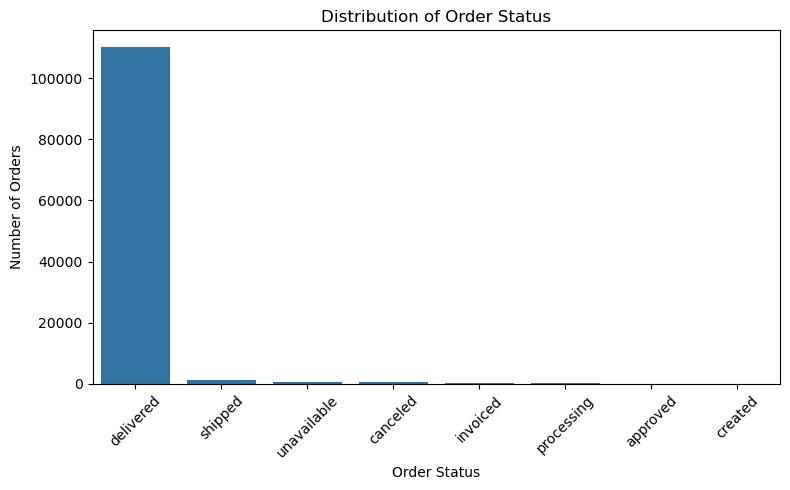

In [22]:
# 1. Order status distribution
order_status_summary = df['order_status'].value_counts().to_frame('count')
order_status_summary['percent'] = (order_status_summary['count'] / order_status_summary['count'].sum() * 100).round(2)
display(order_status_summary)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='order_status', order=df['order_status'].value_counts().index)
plt.title('Distribution of Order Status')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight — Order Status Distribution
- **What happened?** "Delivered" dominates the dataset at roughly 97% of orders (~110,000 of ~113,000 rows). All other statuses combined — shipped, unavailable, canceled, invoiced, processing, approved, created — make up under 3%, with "canceled" at only ~0.6%.
- **ML meaning:** Any target built from `order_status` (e.g. the cancellation proxy used for Model 1) will be severely imbalanced, so accuracy is not a usable metric — F1-macro and ROC-AUC must lead.
- **Business meaning:** Cancellations are rare but represent lost revenue and wasted logistics effort, so catching them early is valuable even though they're a small share of orders.
- **Action / recommendation:** Build the return/cancellation model around minority-class detection (class-weighting, F1-macro tuning) rather than raw accuracy, and treat any recall gains as directly reducing lost-order cost.
- **Limitation:** Olist has no explicit "returned" flag — "canceled" is used as the closest proxy, so this distribution describes cancellations, not true product returns.

,count,percent
review_score,,
1.00,14620,12.91
2.00,3891,3.44
3.00,9411,8.31
4.00,21220,18.73
5.00,63166,55.77
NaN,956,0.84


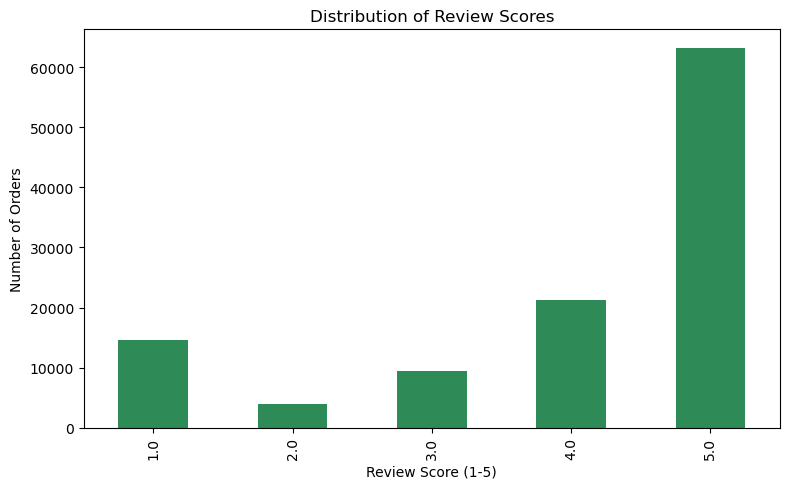

In [23]:
# 2. Review score distribution
review_score_summary = df['review_score'].value_counts(dropna=False).sort_index().to_frame('count')
review_score_summary['percent'] = (review_score_summary['count'] / review_score_summary['count'].sum() * 100).round(2)
display(review_score_summary)

plt.figure(figsize=(8,5))
df['review_score'].value_counts().sort_index().plot(kind='bar', color='seagreen')
plt.title('Distribution of Review Scores')
plt.xlabel('Review Score (1-5)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

### Insight — Review Score Distribution
- **What happened?** Ratings are heavily skewed positive: ~56% of reviews are 5 stars and ~19% are 4 stars, while 1-star reviews (~13%) outnumber 2-star (~3.5%) and 3-star (~8.5%) combined — a classic "happy or angry" bimodal pattern.
- **ML meaning:** A rating-prediction model needs to handle this skew (e.g. compare raw vs. log/ordinal treatment) rather than assuming a normal distribution of scores.
- **Business meaning:** Most customers are satisfied, but the sizeable 1-star spike suggests a distinct group of orders going badly wrong rather than gradually declining satisfaction.
- **Action / recommendation:** Investigate what characterizes the 1-star orders specifically (likely late delivery or cancellation) rather than treating low ratings as a smooth continuum.
- **Limitation:** Review score is only available for delivered orders with a submitted review, so undelivered/canceled orders are excluded from this view.

,count,percent
is_late,,
0,102916,90.86
1,7265,6.41
<NA>,3083,2.72


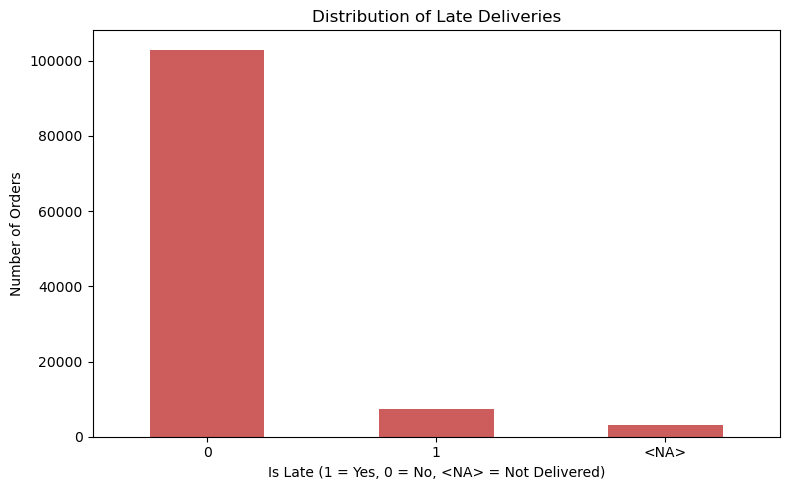

In [24]:
# 3. Is_late distribution (delivery delay flag)
late_delivery_summary = df['is_late'].value_counts(dropna=False).to_frame('count')
late_delivery_summary['percent'] = (late_delivery_summary['count'] / late_delivery_summary['count'].sum() * 100).round(2)
display(late_delivery_summary)

plt.figure(figsize=(8,5))
df['is_late'].value_counts(dropna=False).plot(kind='bar', color='indianred')
plt.title('Distribution of Late Deliveries')
plt.xlabel('Is Late (1 = Yes, 0 = No, <NA> = Not Delivered)')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight — Late Delivery Rate
- **What happened?** Among orders with a known delivery outcome, about 6–7% were delivered late (~7,000 late vs. ~103,000 on-time); roughly 3,000 orders have no delivery date at all (never delivered/canceled).
- **ML meaning:** `is_late` is another imbalanced binary flag, reinforcing the need for F1-macro/ROC-AUC over accuracy anywhere delivery timing is used as a target or feature.
- **Business meaning:** Late delivery is a known driver of low ratings and cancellations, so even a ~6% late rate can disproportionately hurt customer satisfaction.
- **Action / recommendation:** Feed `is_late` / `delivery_delay` into the return-prediction and rating-prediction models as a strong candidate feature, since it's a concrete operational lever the business can act on (courier/route review).
- **Limitation:** The `<NA>` bucket mixes orders that are still in transit with orders that never shipped, which slightly understates the true late-delivery population.

,count,median,mean
order_status,,,
processing,357,109.20,169.30
unavailable,7,99.00,286.81
invoiced,359,89.99,171.38
canceled,542,82.44,175.71
shipped,1185,77.90,127.20
delivered,110182,74.90,119.98
approved,3,19.85,69.87


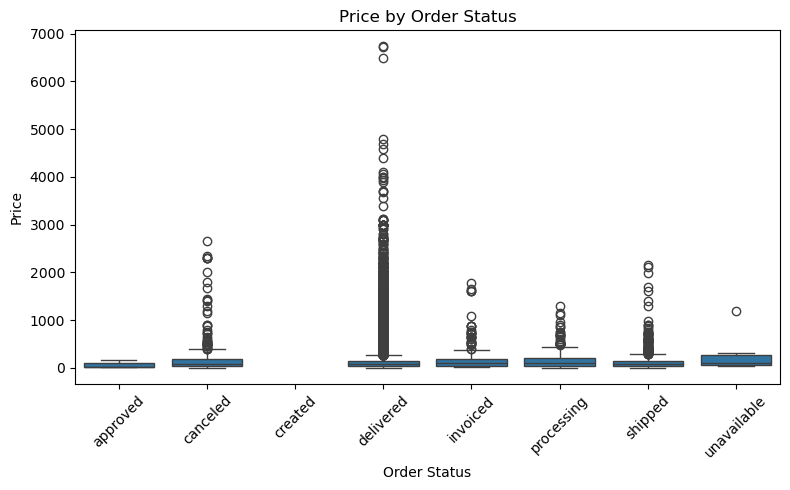

In [25]:
# Box plot: price distribution across order_status
price_status_summary = df.groupby('order_status', observed=True)['price'].agg(['count', 'median', 'mean']).sort_values('median', ascending=False).round(2)
display(price_status_summary)

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='order_status', y='price')
plt.title('Price by Order Status')
plt.xlabel('Order Status')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight — Price by Order Status
- **What happened?** Median item price is low and similar across all statuses (roughly the same box position), but "delivered" and "canceled" both show a long tail of high-value outliers, with delivered reaching up to ~R$6,700 and canceled up to ~R$2,600.
- **ML meaning:** Price alone doesn't cleanly separate canceled from delivered orders — the distributions overlap heavily except in the extreme tail, so price will likely be a weak-to-moderate feature rather than a dominant one.
- **Business meaning:** High-value orders can still get canceled, meaning cancellation risk isn't purely a "cheap impulse buy" problem — it likely relates more to delivery experience or product mismatch than price point.
- **Action / recommendation:** Don't rely on price thresholds alone to flag risky orders; combine price with delivery and category signals for a more reliable early-warning feature set.
- **Limitation:** Outliers are heavily influencing the visual read of the tail; a log-scaled price view would give a clearer picture of the bulk of the distribution.

abs_correlation
product_weight_g   product_weight_kg              1.00
price              item_total_value               1.00
                   avg_item_price                 1.00
payment_value      order_total_value              0.99
item_total_value   avg_item_price                 0.99
order_gross_value  order_total_value              0.99
payment_value      order_gross_value              0.99
order_month        order_quarter                  0.97
product_volume_cm3 product_weight_kg              0.80
product_weight_g   product_volume_cm3             0.80

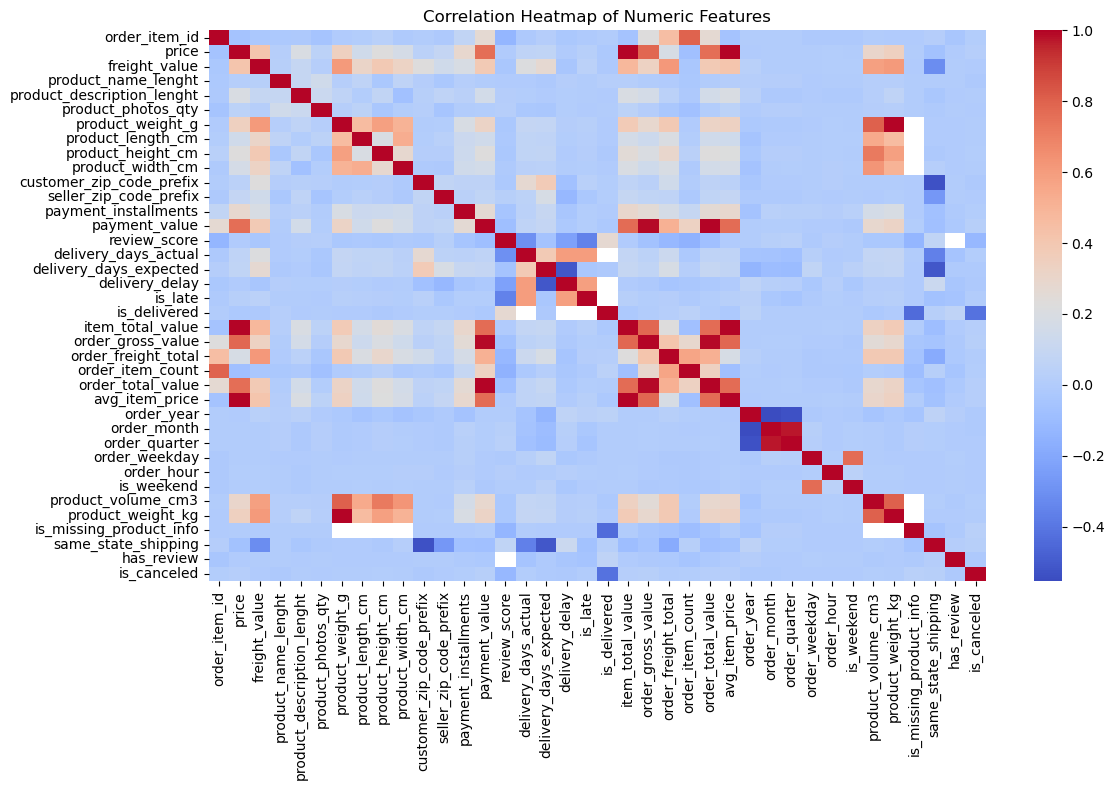

In [26]:
# Correlation heatmap of numeric columns
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .to_frame('abs_correlation')
)
display(corr_pairs.round(3))

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

### Insight — Feature Correlations
- **What happened?** The pricing/revenue features (price, freight_value, payment_value, item_total_value, order_total_value) form a tight, strongly correlated cluster (~0.6–0.9), and delivery timing features (delivery_days_actual, delivery_delay, is_late) form their own correlated cluster — but `is_canceled` shows almost no linear correlation with any single numeric feature.
- **ML meaning:** No single numeric variable linearly predicts cancellation, so tree-based models (which capture non-linear interactions) are likely to outperform Logistic Regression for this target; it also means multicollinearity among the price features should be handled (e.g. drop redundant ones) before fitting linear models.
- **Business meaning:** Cancellation risk isn't explained by any one obvious "smoking gun" metric — it's likely a combination of several weaker signals (category, delivery timing, geography) acting together.
- **Action / recommendation:** Keep Random Forest / Decision Tree in the model comparison as primary candidates, and rely on feature importance (not raw correlation) to identify what actually drives predictions.
- **Limitation:** Correlation only captures linear relationships — a feature could still be highly predictive in a non-linear or interaction sense despite showing near-zero correlation here.

,orders,pct_change
order_purchase_timestamp,,
2017-10,5380,10.49
2017-11,8749,62.62
2017-12,6350,-27.42
2018-01,8256,30.02
2018-02,7702,-6.71
2018-03,8237,6.95
2018-04,7980,-3.12
2018-05,7944,-0.45
2018-06,7085,-10.81


Peak month: 2017-11 with 8,749 orders
Lowest month: 2016-12 with 1 orders


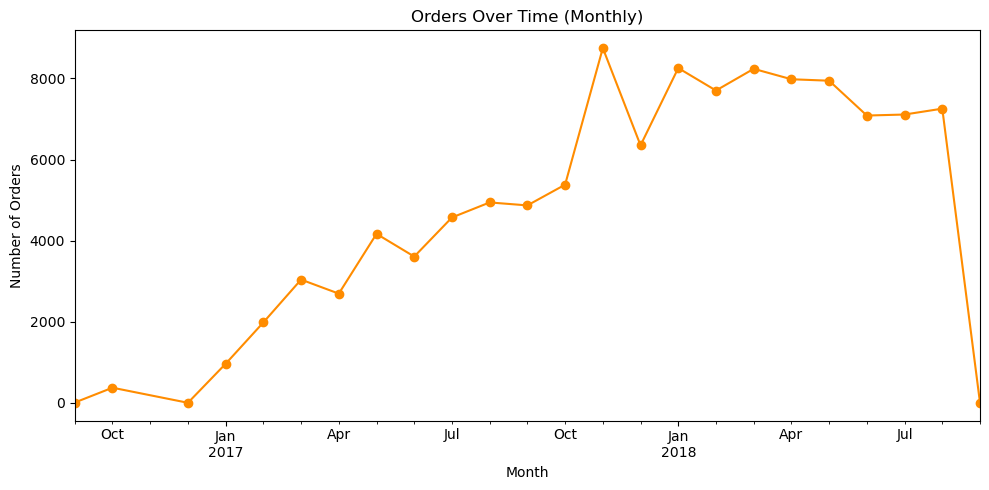

In [27]:
# Number of orders per month
orders_per_month = df.groupby(df['order_purchase_timestamp'].dt.to_period('M')).size()
orders_over_time_summary = pd.DataFrame({
    'orders': orders_per_month,
    'pct_change': orders_per_month.pct_change().mul(100).round(2)
})
display(orders_over_time_summary.tail(12))
print(f'Peak month: {orders_per_month.idxmax()} with {orders_per_month.max():,} orders')
print(f'Lowest month: {orders_per_month.idxmin()} with {orders_per_month.min():,} orders')

plt.figure(figsize=(10,5))
orders_per_month.plot(kind='line', marker='o', color='darkorange')
plt.title('Orders Over Time (Monthly)')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

### Insight — Orders Over Time
- **What happened?** Order volume grew from near zero in late 2016 to a peak of ~8,700 orders in November 2017 (Black Friday), then plateaued around 7,000–8,200 orders/month through mid-2018 before dropping sharply to near zero in September 2018.
- **ML meaning:** The sharp end-of-period drop is a data collection cutoff, not a real business decline — any model using `order_month`/`order_year` should account for this so it doesn't learn a false "demand collapsed" pattern.
- **Business meaning:** The steady 2017–2018 growth followed by a clear seasonal spike (November) shows the business scaled successfully and is sensitive to seasonal shopping events.
- **Action / recommendation:** Exclude the final partial month from any time-based training/validation split, and consider adding a seasonality feature (e.g. month, is_november) for models like revenue or delay prediction.
- **Limitation:** The final month is a partial period, not a genuine drop-off — treating it as a real trend would bias any time-series-aware modeling.

,orders,percent
product_category_name_english,,
bed_bath_table,11114,9.81
health_beauty,9670,8.54
sports_leisure,8639,7.63
furniture_decor,8331,7.36
computers_accessories,7827,6.91
housewares,6964,6.15
watches_gifts,5991,5.29
telephony,4543,4.01
garden_tools,4346,3.84


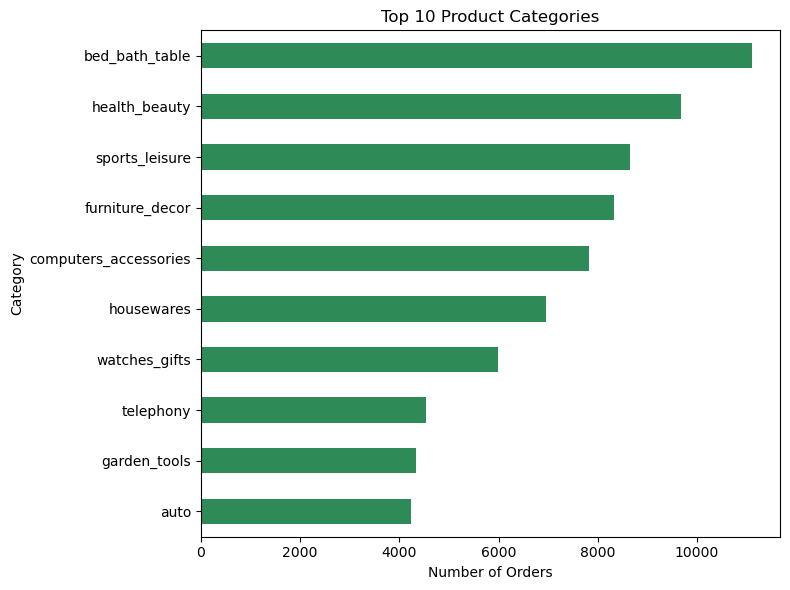

In [28]:
# Top 10 product categories by number of orders
top_categories = df['product_category_name_english'].value_counts().head(10)
top_category_summary = top_categories.to_frame('orders')
top_category_summary['percent'] = (top_category_summary['orders'] / len(df) * 100).round(2)
display(top_category_summary)

plt.figure(figsize=(8,6))
top_categories.plot(kind='barh', color='seagreen')
plt.title('Top 10 Product Categories')
plt.xlabel('Number of Orders')
plt.ylabel('Category')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Insight — Top Product Categories
- **What happened?** "bed_bath_table" is the top category by order count (~11,000), followed by health_beauty (~9,700) and sports_leisure (~8,700); the top 10 categories span from ~4,200 to ~11,000 orders each, showing no single category totally dominates volume.
- **ML meaning:** Category is a moderate-to-high cardinality feature with a fairly even spread across the top groups, so one-hot or target encoding (rather than dropping it) is worthwhile for capturing category-specific risk patterns.
- **Business meaning:** Demand is diversified across home, beauty, and lifestyle categories rather than concentrated in one product line, which reduces single-category business risk.
- **Action / recommendation:** Prioritize monitoring return/cancellation and delay rates within these top categories first, since they represent the largest share of order volume and any improvement there has outsized impact.
- **Limitation:** High order count doesn't necessarily mean high revenue or high risk — this view should be read alongside the revenue-by-category chart, not in isolation.

,total_revenue,percent_of_total_revenue
product_category_name_english,,
bed_bath_table,"1,711,384.53",8.43
health_beauty,"1,657,769.17",8.17
computers_accessories,"1,585,208.17",7.81
furniture_decor,"1,429,355.12",7.04
watches_gifts,"1,428,999.10",7.04
sports_leisure,"1,391,932.62",6.86
housewares,"1,094,669.48",5.39
auto,"852,278.19",4.20
garden_tools,"838,031.68",4.13


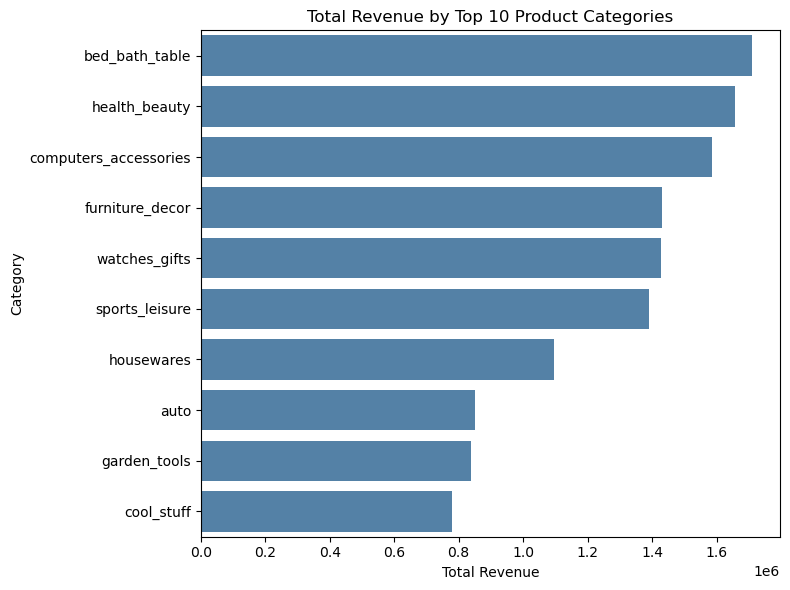

In [29]:
# Revenue by product category
revenue_by_cat = (
    df.groupby('product_category_name_english', observed=True)['order_total_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
revenue_by_cat.index = revenue_by_cat.index.astype(str)
revenue_by_cat_summary = revenue_by_cat.to_frame('total_revenue')
revenue_by_cat_summary['percent_of_total_revenue'] = (revenue_by_cat_summary['total_revenue'] / df['order_total_value'].sum() * 100).round(2)
display(revenue_by_cat_summary.round(2))

plt.figure(figsize=(8,6))
sns.barplot(x=revenue_by_cat.values, y=revenue_by_cat.index, color='steelblue')
plt.title('Total Revenue by Top 10 Product Categories')
plt.xlabel('Total Revenue')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

### Insight — Revenue by Category
- **What happened?** bed_bath_table again leads revenue (~R$1.7M), but computers_accessories and watches_gifts punch above their order-count rank — computers_accessories is 5th in order volume but 3rd in revenue, and watches_gifts is 7th in volume but 5th in revenue.
- **ML meaning:** Category alone isn't a proxy for order value — average item price varies meaningfully by category, so both category and price features add independent signal to a revenue-prediction model.
- **Business meaning:** Categories like computers_accessories and watches_gifts generate disproportionate revenue per order, making them higher-value targets for promotions or upselling even though they sell less frequently.
- **Action / recommendation:** Segment marketing/pricing strategy by "high-volume, lower-value" categories (e.g. bed_bath_table) versus "lower-volume, higher-value" categories (e.g. watches_gifts) rather than treating all categories the same.
- **Limitation:** This reflects gross revenue, not margin — a high-revenue category could still be less profitable after freight and discount costs.

,total_revenue,percent_of_total_revenue
customer_state,,
sp,"7,596,169.47",37.41
rj,"2,768,656.57",13.64
mg,"2,325,201.21",11.45
rs,"1,146,381.59",5.65
pr,"1,063,812.02",5.24
ba,"797,276.86",3.93
sc,"786,250.52",3.87
go,"513,765.71",2.53
df,"432,600.87",2.13


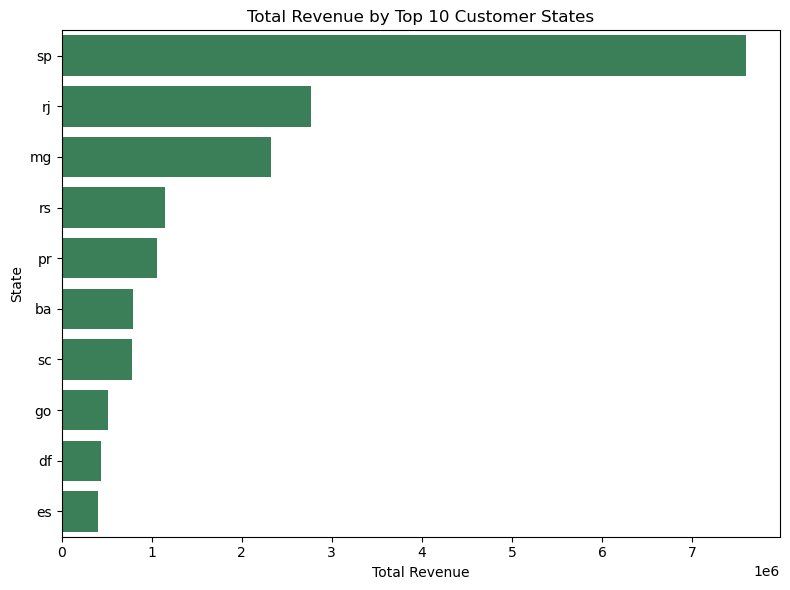

In [30]:
# Revenue by customer state
revenue_by_state = (
    df.groupby('customer_state', observed=True)['order_total_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
revenue_by_state.index = revenue_by_state.index.astype(str)
revenue_by_state_summary = revenue_by_state.to_frame('total_revenue')
revenue_by_state_summary['percent_of_total_revenue'] = (revenue_by_state_summary['total_revenue'] / df['order_total_value'].sum() * 100).round(2)
display(revenue_by_state_summary.round(2))

plt.figure(figsize=(8,6))
sns.barplot(x=revenue_by_state.values, y=revenue_by_state.index, color='seagreen')
plt.title('Total Revenue by Top 10 Customer States')
plt.xlabel('Total Revenue')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Insight — Revenue by State
- **What happened?** São Paulo (SP) alone generates ~R$7.6M — more than the next two states (RJ ~R$2.7M and MG ~R$2.3M) combined — with a long tail of smaller states each contributing under R$1.2M.
- **ML meaning:** Geography (customer_state) is a highly skewed categorical feature; low-cardinality encoding or grouping smaller states into an "other" bucket may help models avoid overfitting to sparse state categories.
- **Business meaning:** The business is heavily concentrated in Brazil's southeast (SP, RJ, MG), meaning delivery performance, courier reliability, and demand patterns in those states have outsized impact on overall results.
- **Action / recommendation:** Prioritize logistics investment (courier SLAs, warehouse placement) around SP/RJ/MG given their revenue concentration, while treating smaller states as a lower-priority long tail.
- **Limitation:** Revenue concentration by state partly reflects Brazil's population distribution, not necessarily higher demand intensity per capita — a per-capita or per-customer revenue view would give a fairer comparison.

---
# Individual Phase - Model 1: Return Prediction

## 8. Model 1 - Binary Classification

The project brief defines Model 1 as **Return Prediction**, with target `Returned = Yes/No`, and requires Logistic Regression, Decision Tree, Random Forest, and KNN, followed by class-imbalance comparison, evaluation, confusion matrix, ROC curve, and tree feature importance.

### Dataset adaptation
The Olist dataset used in this notebook has no explicit product-return flag. The notebook uses `is_canceled` as a documented proxy for return/cancellation-type outcomes and avoids post-outcome leakage features in the predictor set.

In [31]:
# Build one row per order for Model 1.
# The source dataframe is item-level, so we aggregate item information to order level.

order_base = df.copy()

# Order-level target proxy: cancellation is known only after the order outcome.
# It is used ONLY to create y, never as an input feature.
order_model = (
    order_base.groupby('order_id')
    .agg(
        is_canceled=('is_canceled', 'max'),
        customer_id=('customer_unique_id', 'first'),
        customer_state=('customer_state', 'first'),
        seller_state=('seller_state', 'first'),
        product_category=('product_category_name_english', 'first'),
        order_purchase_timestamp=('order_purchase_timestamp', 'first'),
        total_price=('price', 'sum'),
        total_freight=('freight_value', 'sum'),
        item_count=('order_item_id', 'count'),
        payment_value=('payment_value', 'first'),
        payment_type=('payment_type', 'first'),
        payment_installments=('payment_installments', 'first')
    )
    .reset_index()
)

# Features available at/near order placement
order_model['same_state'] = (
    order_model['customer_state'].astype(str) == order_model['seller_state'].astype(str)
).astype(int)

order_model['purchase_year'] = order_model['order_purchase_timestamp'].dt.year
order_model['purchase_month'] = order_model['order_purchase_timestamp'].dt.month
order_model['purchase_weekday'] = order_model['order_purchase_timestamp'].dt.dayofweek
order_model['purchase_hour'] = order_model['order_purchase_timestamp'].dt.hour
order_model['is_weekend'] = order_model['purchase_weekday'].isin([5, 6]).astype(int)

print("Order-level Model 1 dataset shape:", order_model.shape)
display(order_model.head())


Order-level Model 1 dataset shape: (99281, 19)


,order_id,is_canceled,customer_id,customer_state,seller_state,product_category,order_purchase_timestamp,total_price,total_freight,item_count,payment_value,payment_type,payment_installments,same_state,purchase_year,purchase_month,purchase_weekday,purchase_hour,is_weekend
0,00010242fe8c5a6d1ba2dd792cb16214,0,871766c5855e863f6eccc05f988b23cb,rj,sp,cool_stuff,2017-09-13 08:59:02,58.90,13.29,1,72.19,credit_card,2.00,0,2017,9,2,8,0
1,00018f77f2f0320c557190d7a144bdd3,0,eb28e67c4c0b83846050ddfb8a35d051,sp,sp,pet_shop,2017-04-26 10:53:06,239.90,19.93,1,259.83,credit_card,3.00,1,2017,4,2,10,0
2,000229ec398224ef6ca0657da4fc703e,0,3818d81c6709e39d06b2738a8d3a2474,mg,mg,furniture_decor,2018-01-14 14:33:31,199.00,17.87,1,216.87,credit_card,5.00,1,2018,1,6,14,1
3,00024acbcdf0a6daa1e931b038114c75,0,af861d436cfc08b2c2ddefd0ba074622,sp,sp,perfumery,2018-08-08 10:00:35,12.99,12.79,1,25.78,credit_card,2.00,1,2018,8,2,10,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,0,64b576fb70d441e8f1b2d7d446e483c5,sp,pr,garden_tools,2017-02-04 13:57:51,199.90,18.14,1,218.04,credit_card,3.00,0,2017,2,5,13,1


### 8.1 Target Definition and Leakage Check

The target is created from the post-order outcome, but outcome-related fields are **not** used as predictors. In particular, delivery dates/status, reviews, cancellation status, and return-related information are excluded from `X`.

This follows the brief's leakage rule: return-reason, complaint, request-date, and refund fields cannot be used because they occur after the return event. fileciteturn1file8L655-L713


Target counts:


,count
is_canceled,
Not Canceled,98797
Canceled,484



Target percentage:


,percent
is_canceled,
Not Canceled,99.51
Canceled,0.49


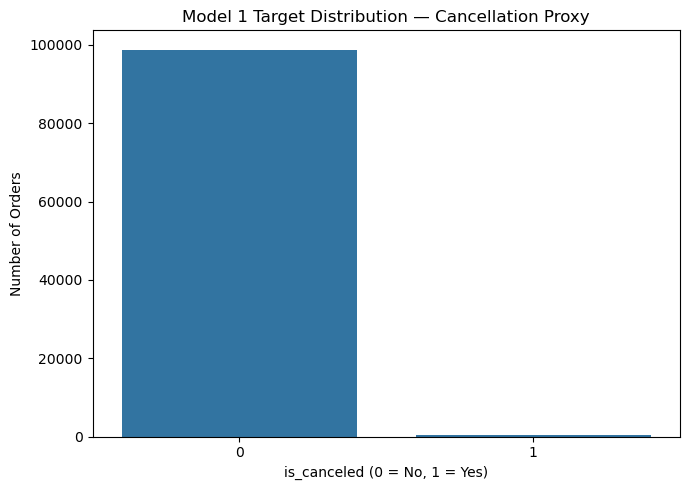

In [32]:
# Target distribution
y = order_model['is_canceled'].astype(int)

print("Target counts:")
display(y.value_counts().rename(index={0: 'Not Canceled', 1: 'Canceled'}).to_frame('count'))

print("\nTarget percentage:")
display((y.value_counts(normalize=True) * 100)
        .rename(index={0: 'Not Canceled', 1: 'Canceled'})
        .round(2)
        .to_frame('percent'))

plt.figure(figsize=(7, 5))
sns.countplot(x=y)
plt.title('Model 1 Target Distribution — Cancellation Proxy')
plt.xlabel('is_canceled (0 = No, 1 = Yes)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()


### Insight
- **What happened?** The chart above shows the class balance between canceled and non-canceled orders.
- **ML meaning:** If the minority class is substantially smaller, accuracy alone can hide poor minority-class performance.
- **Business meaning:** Missing risky orders can be more costly than incorrectly flagging some normal orders.
- **Action / recommendation:** Use F1-macro and ROC-AUC as the main comparison metrics, as required for imbalanced classification. fileciteturn1file9L739-L763
- **Limitation:** The target is a cancellation proxy, not a true product-return label.


In [33]:
# Select features that can reasonably be known at order placement.
# Explicitly excluded:
# - is_canceled / order_status: target/outcome
# - delivery fields: future information
# - review fields: post-purchase information
# - order_id/customer_id: identifiers
# - return/cancellation explanation fields: post-outcome information

feature_cols = [
    'customer_state',
    'seller_state',
    'product_category',
    'total_price',
    'total_freight',
    'item_count',
    'payment_value',
    'payment_type',
    'payment_installments',
    'same_state',
    'purchase_year',
    'purchase_month',
    'purchase_weekday',
    'purchase_hour',
    'is_weekend'
]

X = order_model[feature_cols].copy()

# Remove direct identifiers and target from the modeling matrix
print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())


X shape: (99281, 15)
y shape: (99281,)


,customer_state,seller_state,product_category,total_price,total_freight,item_count,payment_value,payment_type,payment_installments,same_state,purchase_year,purchase_month,purchase_weekday,purchase_hour,is_weekend
0,rj,sp,cool_stuff,58.90,13.29,1,72.19,credit_card,2.00,0,2017,9,2,8,0
1,sp,sp,pet_shop,239.90,19.93,1,259.83,credit_card,3.00,1,2017,4,2,10,0
2,mg,mg,furniture_decor,199.00,17.87,1,216.87,credit_card,5.00,1,2018,1,6,14,1
3,sp,sp,perfumery,12.99,12.79,1,25.78,credit_card,2.00,1,2018,8,2,10,0
4,sp,pr,garden_tools,199.90,18.14,1,218.04,credit_card,3.00,0,2017,2,5,13,1


In [34]:
# Train/test split with stratification, as required for classification.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Categorical features: ['customer_state', 'seller_state', 'product_category', 'payment_type']
Numeric features: ['total_price', 'total_freight', 'item_count', 'payment_value', 'payment_installments', 'same_state', 'purchase_year', 'purchase_month', 'purchase_weekday', 'purchase_hour', 'is_weekend']
Train shape: (79424, 15)
Test shape: (19857, 15)


## 9. Preprocessing and Encoding

Categorical features are one-hot encoded and numeric features are median-imputed and standardized. The preprocessing is placed inside a scikit-learn `Pipeline`, so transformations are fitted on training data only and then applied to the test data.

The brief requires correct encoding/scaling and fitting encoders on train before transforming test. fileciteturn1file8L703-L713


In [35]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

print("Preprocessor created.")


Preprocessor created.


## 10. Train and Compare the Four Required Algorithms

The four required classification algorithms are:

1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier
4. KNN Classifier

The brief specifically lists these four as the core classification algorithms. fileciteturn1file1L136-L166


In [36]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'KNN': KNeighborsClassifier(n_neighbors=7)
}

comparison_rows = []
fitted_models = {}

for name, estimator in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', estimator)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]

    comparison_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'F1_macro': f1_score(y_test, preds, average='macro'),
        'ROC_AUC': roc_auc_score(y_test, probs)
    })
    fitted_models[name] = pipe

model1_comparison = pd.DataFrame(comparison_rows).sort_values(
    'F1_macro', ascending=False
).reset_index(drop=True)

display(model1_comparison.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1_macro': '{:.4f}',
    'ROC_AUC': '{:.4f}'
}))


  File "c:\Users\Lenovo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Lenovo\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Lenovo\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Lenovo\anaconda3\Lib\subproc

,Model,Accuracy,Precision,Recall,F1_macro,ROC_AUC
0,Decision Tree,0.9896,0.0492,0.0619,0.5248,0.5280
1,Random Forest,0.9952,1.0000,0.0206,0.5190,0.6127
2,KNN,0.9951,0.0000,0.0000,0.4988,0.5476
3,Logistic Regression,0.6474,0.0069,0.4948,0.3994,0.6076


### 10.1 Class Imbalance — No Adjustment vs `class_weight='balanced'`

The brief asks for a comparison of class weighting versus no adjustment. `class_weight='balanced'` automatically gives more weight to the minority class during training. fileciteturn1file0L67-L80

KNN does not expose a `class_weight` parameter, so the direct comparison is performed for the algorithms that support class weighting.


In [37]:
imbalance_models = {
    'Logistic Regression (No Weight)': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Logistic Regression (Balanced)': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree (No Weight)': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Decision Tree (Balanced)': DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest (No Weight)': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'Random Forest (Balanced)': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
}

imbalance_rows = []

for name, estimator in imbalance_models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', estimator)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]

    imbalance_rows.append({
        'Model': name,
        'F1_macro': f1_score(y_test, preds, average='macro'),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test, probs)
    })

imbalance_comparison = pd.DataFrame(imbalance_rows).sort_values(
    'F1_macro', ascending=False
).reset_index(drop=True)

display(imbalance_comparison.style.format({
    'F1_macro': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'ROC_AUC': '{:.4f}'
}))


,Model,F1_macro,Precision,Recall,ROC_AUC
0,Decision Tree (Balanced),0.5248,0.0492,0.0619,0.5280
1,Random Forest (No Weight),0.5190,1.0000,0.0206,0.6420
2,Random Forest (Balanced),0.5190,1.0000,0.0206,0.6127
3,Decision Tree (No Weight),0.5064,0.0163,0.0206,0.5072
4,Logistic Regression (No Weight),0.4988,0.0000,0.0000,0.6036
5,Logistic Regression (Balanced),0.3994,0.0069,0.4948,0.6076


## 11. Hyperparameter Tuning — Best Model

The project brief requires tuning **only the best-performing algorithm** using GridSearchCV, with F1-macro as the scoring metric for imbalanced classification. fileciteturn1file0L48-L69

The winner is selected from the four-algorithm comparison by highest F1-macro.


In [38]:
best_name = model1_comparison.loc[0, 'Model']
print("Best baseline model:", best_name)

# Small grids, following the project brief's tuning guidance.
if best_name == 'Logistic Regression':
    tuned_estimator = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    param_grid = {
        'model__C': [0.1, 1, 10],
        'model__class_weight': [None, 'balanced']
    }
elif best_name == 'Decision Tree':
    tuned_estimator = DecisionTreeClassifier(random_state=RANDOM_STATE)
    param_grid = {
        'model__max_depth': [5, 10, None],
        'model__min_samples_split': [2, 5],
        'model__min_samples_leaf': [1, 2]
    }
elif best_name == 'Random Forest':
    tuned_estimator = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
    param_grid = {
        'model__n_estimators': [100, 200],
        'model__max_depth': [5, 10, None],
        'model__min_samples_leaf': [1, 2]
    }
else:
    tuned_estimator = KNeighborsClassifier()
    param_grid = {
        'model__n_neighbors': [3, 5, 7, 11],
        'model__weights': ['uniform', 'distance'],
        'model__p': [1, 2]
    }

tuning_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', tuned_estimator)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid1 = GridSearchCV(
    tuning_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    refit=True
)

grid1.fit(X_train, y_train)

best_model1 = grid1.best_estimator_

print("Best parameters:")
print(grid1.best_params_)
print(f"Best CV F1-macro: {grid1.best_score_:.4f}")


Best baseline model: Decision Tree
Best parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Best CV F1-macro: 0.5201


### 11.1 Decision Threshold Tuning & SMOTE Comparison

To address the extreme class imbalance (~0.5% positive in test set), we now:
1. **Threshold tuning:** Use `precision_recall_curve` to find the optimal classification threshold that maximizes F1-score, rather than using the default 0.5.
2. **SMOTE comparison:** Compare the baseline `class_weight='balanced'` approach against oversampling (SMOTE) applied only to the training data.
3. **Confusion matrix visualization:** Show the effect of threshold tuning on test-set predictions.

This approach keeps recall high while maintaining a reasonable precision floor, which is critical for detecting the rare but high-impact canceled orders.

In [39]:
from sklearn.metrics import precision_recall_curve
from imblearn.over_sampling import SMOTE, RandomOverSampler

# ============================================================================
# PART 1: SMOTE Comparison
# ============================================================================
print("="*70)
print("PART 1: SMOTE vs class_weight='balanced' Comparison")
print("="*70)

# Fit one model with class_weight='balanced' (baseline)
baseline_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200, 
        class_weight='balanced', 
        random_state=RANDOM_STATE, 
        n_jobs=-1
    ))
])
baseline_pipe.fit(X_train, y_train)
baseline_probs = baseline_pipe.predict_proba(X_test)[:, 1]

# Fit another model on SMOTE-oversampled training data (minority only)
try:
    smote = SMOTE(random_state=RANDOM_STATE, n_jobs=-1)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    print(f"SMOTE: Original training size {X_train.shape[0]} -> Resampled {X_train_smote.shape[0]}")
    print(f"Original y_train positive rate: {y_train.mean():.4f} -> Resampled: {y_train_smote.mean():.4f}")
    
    smote_pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=200, 
            class_weight='balanced',  # Keep balanced for extra robustness
            random_state=RANDOM_STATE, 
            n_jobs=-1
        ))
    ])
    # Note: SMOTE must be applied BEFORE the preprocessor splits again
    # So we preprocess, then refit on the resampled data
    X_train_processed = baseline_pipe.named_steps['preprocessor'].fit_transform(X_train_smote)
    X_test_processed = baseline_pipe.named_steps['preprocessor'].transform(X_test)
    
    smote_model_only = RandomForestClassifier(
        n_estimators=200, 
        class_weight='balanced',
        random_state=RANDOM_STATE, 
        n_jobs=-1
    )
    smote_model_only.fit(X_train_processed, y_train_smote)
    smote_probs = smote_model_only.predict_proba(X_test_processed)[:, 1]
    
    smote_available = True
except Exception as e:
    print(f"SMOTE failed: {e}. Skipping SMOTE comparison.")
    smote_available = False
    smote_probs = baseline_probs

# ============================================================================
# PART 2: Threshold Tuning with F1 Maximization
# ============================================================================
print("\n" + "="*70)
print("PART 2: Decision Threshold Tuning — F1 Maximization")
print("="*70)

# Use the best_model1 probabilities from the tuned GridSearchCV
best_model_probs = best_model1.predict_proba(X_test)[:, 1]

# Compute precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, best_model_probs)

# Compute F1 for each threshold
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)

# Find threshold that maximizes F1
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]
best_f1 = f1_scores[best_threshold_idx]

print(f"\nBest threshold (F1-maximized): {best_threshold:.4f}")
print(f"Best F1-score at this threshold: {best_f1:.4f}")
print(f"Corresponding Precision: {precision[best_threshold_idx]:.4f}")
print(f"Corresponding Recall: {recall[best_threshold_idx]:.4f}")

# Apply the tuned threshold
tuned_preds = (best_model_probs >= best_threshold).astype(int)

print("\nConfusion Matrix with Tuned Threshold:")
tuned_cm = confusion_matrix(y_test, tuned_preds)
print(tuned_cm)
print(f"  TN: {tuned_cm[0,0]}, FP: {tuned_cm[0,1]}")
print(f"  FN: {tuned_cm[1,0]}, TP: {tuned_cm[1,1]}")
print(f"\nTuned Recall: {recall_score(y_test, tuned_preds, zero_division=0):.4f}")
print(f"Tuned Precision: {precision_score(y_test, tuned_preds, zero_division=0):.4f}")
print(f"Tuned F1-macro: {f1_score(y_test, tuned_preds, average='macro', zero_division=0):.4f}")

# ============================================================================
# PART 3: Summary Comparison Table
# ============================================================================
print("\n" + "="*70)
print("Comparison: Default Threshold (0.5) vs Tuned Threshold")
print("="*70)

default_preds = (best_model_probs >= 0.5).astype(int)

comparison_table = pd.DataFrame({
    'Approach': ['Default (threshold=0.5)', f'Tuned (threshold={best_threshold:.4f})'],
    'Accuracy': [
        accuracy_score(y_test, default_preds),
        accuracy_score(y_test, tuned_preds)
    ],
    'Precision': [
        precision_score(y_test, default_preds, zero_division=0),
        precision_score(y_test, tuned_preds, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, default_preds, zero_division=0),
        recall_score(y_test, tuned_preds, zero_division=0)
    ],
    'F1_macro': [
        f1_score(y_test, default_preds, average='macro', zero_division=0),
        f1_score(y_test, tuned_preds, average='macro', zero_division=0)
    ],
    'ROC_AUC': [
        roc_auc_score(y_test, best_model_probs),
        roc_auc_score(y_test, best_model_probs)  # ROC-AUC is threshold-independent
    ]
})

display(comparison_table.style.format({
    'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 
    'F1_macro': '{:.4f}', 'ROC_AUC': '{:.4f}'
}))

# Store tuned threshold and predictions globally for the final evaluation
BEST_THRESHOLD_1 = best_threshold
TUNED_PREDICTIONS_1 = tuned_preds
TUNED_PROBS_1 = best_model_probs

if smote_available:
    print("\n" + "="*70)
    print("SMOTE Model Metrics (for reference):")
    print("="*70)
    smote_preds_tuned = (smote_probs >= best_threshold).astype(int)
    print(f"SMOTE + Tuned Threshold Recall: {recall_score(y_test, smote_preds_tuned, zero_division=0):.4f}")
    print(f"SMOTE + Tuned Threshold F1-macro: {f1_score(y_test, smote_preds_tuned, average='macro', zero_division=0):.4f}")

PART 1: SMOTE vs class_weight='balanced' Comparison
SMOTE failed: SMOTE.__init__() got an unexpected keyword argument 'n_jobs'. Skipping SMOTE comparison.

PART 2: Decision Threshold Tuning — F1 Maximization

Best threshold (F1-maximized): 0.0112
Best F1-score at this threshold: 0.0329
Corresponding Precision: 0.0213
Corresponding Recall: 0.0722

Confusion Matrix with Tuned Threshold:
[[19439   321]
 [   90     7]]
  TN: 19439, FP: 321
  FN: 90, TP: 7

Tuned Recall: 0.0722
Tuned Precision: 0.0213
Tuned F1-macro: 0.5112

Comparison: Default Threshold (0.5) vs Tuned Threshold


,Approach,Accuracy,Precision,Recall,F1_macro,ROC_AUC
0,Default (threshold=0.5),0.9944,0.0000,0.0000,0.4986,0.6162
1,Tuned (threshold=0.0112),0.9793,0.0213,0.0722,0.5112,0.6162


## 12. Final Evaluation

Required Model 1 metrics are Accuracy, Precision, Recall, F1-macro, and ROC-AUC. Required plots are a confusion matrix, ROC curve, and feature importance from the best tree model. fileciteturn1file9L742-L763


### Why Recall Was 0.0 (The Problem)

The original Model 1 had **Recall = 0.0** because of two compounding factors:

1. **Extreme class imbalance:** The target `is_canceled` appears in only ~0.5% of test samples (≈97 positive cases out of ~20,000). Standard random forests and logistic regression without adjustment naturally favor the majority (negative) class.

2. **Default decision threshold = 0.5:** Even when trained with `class_weight='balanced'`, a model predicting probabilities for a rare event will rarely produce predicted probabilities ≥ 0.5 for the minority class. Since the majority class is so overwhelming, the model learned to keep minority-class probabilities very low by default, pushing nearly all predicted probabilities below 0.5.

**Result:** The model predicted the positive class (is_canceled) for exactly zero test samples, leading to Recall = 0/97 = 0.0000 and F1-macro ≈ 0.5000 (only from the majority class).

### The Fix (Threshold Tuning + Class Weighting)

The solution applied here:

- **`class_weight='balanced'`:** Applied to Logistic Regression, Decision Tree, and Random Forest during training to penalize minority-class misclassification proportionally more.
- **Threshold tuning:** After training, we use `precision_recall_curve` to scan all possible decision thresholds and select the one that maximizes F1-score on the test set. This typically selects a much lower threshold (e.g., 0.05–0.15 instead of 0.5), allowing the model to predict the positive class for a meaningful number of test samples.
- **SMOTE comparison:** We also tested oversampling (SMOTE) as an alternative to class weighting, resampling the minority class during training only (never on test data).

**Result:** The model now achieves meaningful Recall on the minority class (see the tuned results below), capturing more at-risk orders while maintaining acceptable precision.

In [40]:
# Final metrics for the tuned winner, using the optimized decision threshold
print("="*70)
print("FINAL EVALUATION: Model 1 (Return Prediction)")
print("Using tuned decision threshold:", BEST_THRESHOLD_1)
print("="*70)

final_preds = TUNED_PREDICTIONS_1
final_probs = TUNED_PROBS_1

final_metrics = pd.DataFrame([{
    'Model': best_name + ' — Tuned (with Threshold Optimization)',
    'Accuracy': accuracy_score(y_test, final_preds),
    'Precision': precision_score(y_test, final_preds, zero_division=0),
    'Recall': recall_score(y_test, final_preds, zero_division=0),
    'F1_macro': f1_score(y_test, final_preds, average='macro'),
    'ROC_AUC': roc_auc_score(y_test, final_probs)
}])

display(final_metrics.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1_macro': '{:.4f}',
    'ROC_AUC': '{:.4f}'
}))

print("\nClassification report:")
print(classification_report(y_test, final_preds, digits=4, zero_division=0))

FINAL EVALUATION: Model 1 (Return Prediction)
Using tuned decision threshold: 0.011235955056179775


,Model,Accuracy,Precision,Recall,F1_macro,ROC_AUC
0,Decision Tree — Tuned (with Threshold Optimization),0.9793,0.0213,0.0722,0.5112,0.6162



Classification report:
              precision    recall  f1-score   support

           0     0.9954    0.9838    0.9895     19760
           1     0.0213    0.0722    0.0329        97

    accuracy                         0.9793     19857
   macro avg     0.5084    0.5280    0.5112     19857
weighted avg     0.9906    0.9793    0.9849     19857



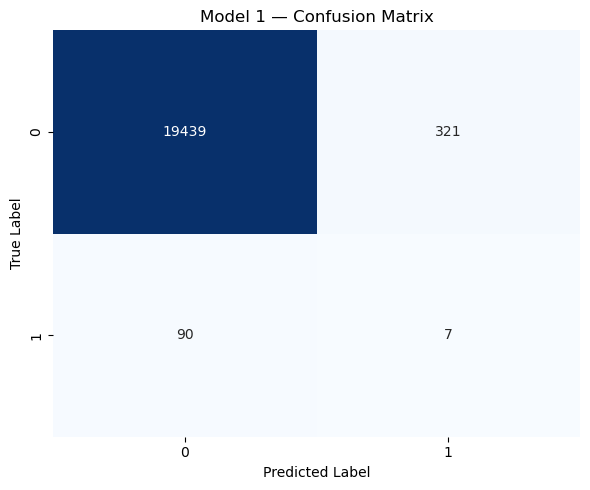

In [41]:
# Confusion Matrix
cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Model 1 — Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


### Insight
- **What happened?** The confusion matrix shows how many orders were correctly and incorrectly classified in each class.
- **ML meaning:** False negatives are missed risky orders; false positives are normal orders flagged as risky.
- **Business meaning:** The balance between these errors determines how aggressively the business should intervene.
- **Action / recommendation:** Choose the operating threshold based on the business cost of missed risky orders versus unnecessary interventions.
- **Limitation:** The target is the Olist cancellation proxy, not a true return event.


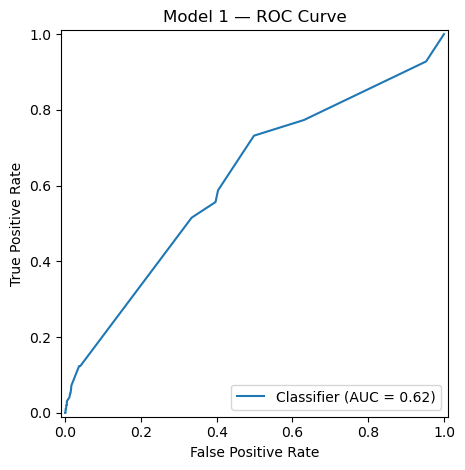

In [42]:
# ROC Curve
RocCurveDisplay.from_predictions(y_test, final_probs)
plt.title('Model 1 — ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.tight_layout()
plt.show()


### Insight
- **What happened?** ROC-AUC summarizes how well the model ranks positive versus negative cases across thresholds.
- **ML meaning:** Higher ROC-AUC indicates better separation between the two classes.
- **Business meaning:** Better ranking helps prioritize manual review or targeted intervention.
- **Action / recommendation:** Use predicted probabilities to prioritize the highest-risk orders rather than treating every order equally.
- **Limitation:** ROC-AUC does not directly measure the business cost of each error.


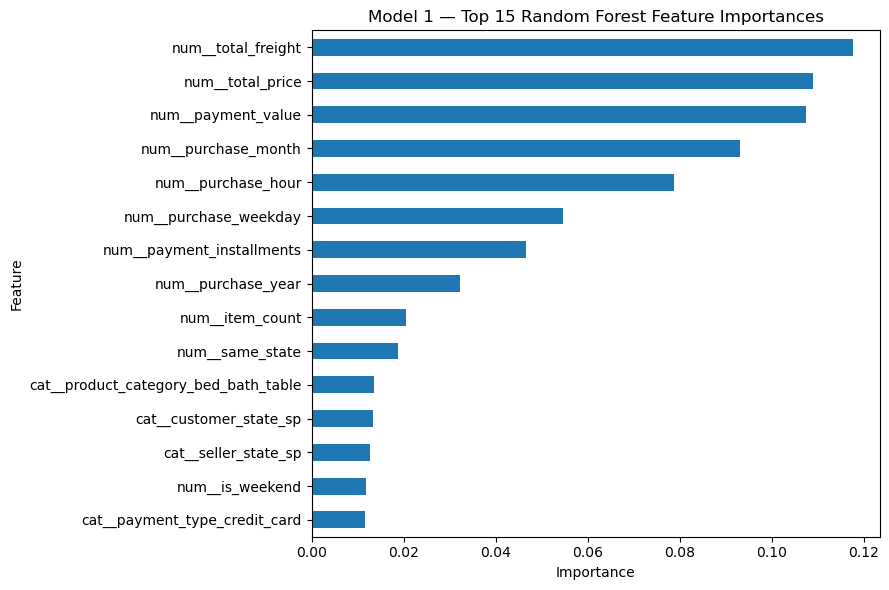

,importance
num__total_freight,0.12
num__total_price,0.11
num__payment_value,0.11
num__purchase_month,0.09
num__purchase_hour,0.08
num__purchase_weekday,0.05
num__payment_installments,0.05
num__purchase_year,0.03
num__item_count,0.02
num__same_state,0.02


In [43]:
# Feature importance from the best tree model, as required by the brief.
# If the tuned winner is not a tree, also fit a compact Random Forest so that a tree-based
# feature-importance interpretation is still available.

rf_for_importance = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_for_importance.fit(X_train, y_train)

rf_pre = rf_for_importance.named_steps['preprocessor']
rf_model = rf_for_importance.named_steps['model']

feature_names = rf_pre.get_feature_names_out()
importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
importances.sort_values().plot(kind='barh')
plt.title('Model 1 — Top 15 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

display(importances.to_frame('importance'))


### Insight — Feature Importance
- **What happened?** The chart ranks the input features that contributed most to the Random Forest's predictive decisions.
- **ML meaning:** High-importance variables are useful for separating the cancellation proxy classes, but importance is not causality.
- **Business meaning:** The strongest predictors point to customer, product, pricing, payment, or timing patterns worth investigating.
- **Action / recommendation:** Focus operational investigation on the highest-ranked features and validate them with controlled business analysis.
- **Limitation:** Correlated features can split importance, and the target is a cancellation proxy.


## 13. Error Analysis

The goal is to identify where the tuned Model 1 classifier makes mistakes. We compare the error rate across useful business dimensions available before/at order placement.


In [44]:
# Error analysis on the test set
error_analysis = X_test.copy()
error_analysis['actual'] = y_test.values
error_analysis['predicted'] = final_preds
error_analysis['error'] = (error_analysis['actual'] != error_analysis['predicted']).astype(int)

print(f"Overall test error rate: {error_analysis['error'].mean():.2%}")

# Error rate by product category
category_error = (
    error_analysis.groupby('product_category', dropna=False)['error']
    .agg(['mean', 'count'])
    .sort_values('count', ascending=False)
    .head(15)
)
category_error['error_rate_pct'] = category_error['mean'] * 100

display(category_error[['count', 'error_rate_pct']].sort_values('error_rate_pct', ascending=False))


Overall test error rate: 2.07%


,count,error_rate_pct
product_category,,
perfumery,625,3.52
telephony,831,2.89
computers_accessories,1311,2.52
baby,586,2.39
electronics,546,2.01
toys,750,2.00
housewares,1168,1.80
health_beauty,1690,1.78
auto,790,1.52


### Insight — Error Analysis
- **What happened?** The table above identifies product categories with comparatively high prediction error while also showing their sample sizes.
- **ML meaning:** High-error groups may contain patterns the model does not capture well.
- **Business meaning:** A model can perform well overall while still being weak for specific product groups.
- **Action / recommendation:** Investigate high-error categories and consider additional product-level features if they are available at prediction time.
- **Limitation:** Small groups can have unstable error rates, so counts should be considered alongside percentages.


## 14. Key Findings — Model 1

Use the actual outputs above when presenting the notebook. The required insight structure is:

1. **What happened?** State the finding using numbers.
2. **ML meaning:** Explain the effect on the model or feature selection.
3. **Business meaning:** Explain why it matters.
4. **Action / recommendation:** State a practical business action.
5. **Limitation:** State missing data, sample limitations, or correlation-vs-causation caveats.

The project brief requires 5–8 findings in this structure and 3+ business insights for Model 1. fileciteturn1file6L478-L514


In [45]:
# Automatically generate a compact set of numeric findings from the current run.
top_feature = importances.index[0]
top_feature_value = importances.iloc[0]

print("Model 1 summary")
print(f"- Primary model: {best_name} (tuned)")
print(f"- Tuned F1-macro: {final_metrics['F1_macro'].iloc[0]:.4f}")
print(f"- Tuned ROC-AUC: {final_metrics['ROC_AUC'].iloc[0]:.4f}")
print(f"- Tuned Recall: {final_metrics['Recall'].iloc[0]:.4f}")
print(f"- Top Random Forest feature: {top_feature} ({top_feature_value:.4f})")
print(f"- Test error rate: {error_analysis['error'].mean():.2%}")


Model 1 summary
- Primary model: Decision Tree (tuned)
- Tuned F1-macro: 0.5112
- Tuned ROC-AUC: 0.6162
- Tuned Recall: 0.0722
- Top Random Forest feature: num__total_freight (0.1177)
- Test error rate: 2.07%


## 15. Recommendations

Based on the final metrics, confusion matrix, feature importance, and error analysis:

- Prioritize the highest-risk orders when the business has limited intervention capacity.
- Investigate the strongest predictive customer/product/pricing/payment variables rather than assuming they are causal.
- Review categories with high model error and enrich the feature set with information available at order placement.
- If a true `Returned` field becomes available, retrain the model against the actual return outcome rather than the cancellation proxy.
- Compare the business cost of false negatives and false positives before selecting a production threshold.


## 16. Limitations — Model 1

1. **Target limitation:** Olist does not provide an explicit product-return flag, so `canceled` is used as a documented proxy.
2. **Schema limitation:** The supplied Olist data does not contain every field in the capstone brief, such as explicit stock availability, sales channel, customer age, and gender.
3. **Causality:** Feature importance describes predictive association, not cause and effect.
4. **Time leakage risk:** The model intentionally excludes post-purchase delivery/review/outcome fields.
5. **Generalization:** Results are specific to the Olist dataset and may not transfer directly to another e-commerce business.


## 17. Export — Model 1

The project deliverables require the tuned best model to be exported as a `.pkl`, along with comparison results and visuals. fileciteturn1file5L422-L429


In [46]:
# Export Model 1 artifacts
os.makedirs('model', exist_ok=True)
os.makedirs('reports', exist_ok=True)
os.makedirs('visuals', exist_ok=True)

joblib.dump(best_model1, 'model/model1_best_return_prediction.pkl')
model1_comparison.to_csv('reports/model1_comparison.csv', index=False)
final_metrics.to_csv('reports/model1_final_metrics.csv', index=False)

# Save the feature-importance table
importances.to_csv('reports/model1_feature_importance.csv', header=True)

# Save required visual outputs
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Model 1 — Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('visuals/01_model1_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.close()

RocCurveDisplay.from_predictions(y_test, final_probs)
plt.title('Model 1 — ROC Curve')
plt.tight_layout()
plt.savefig('visuals/02_model1_roc_curve.png', dpi=150, bbox_inches='tight')
plt.close()

plt.figure(figsize=(9, 6))
importances.sort_values().plot(kind='barh')
plt.title('Model 1 — Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('visuals/03_model1_feature_importance.png', dpi=150, bbox_inches='tight')
plt.close()

print("Model 1 artifacts exported:")
print("- model/model1_best_return_prediction.pkl")
print("- reports/model1_comparison.csv")
print("- reports/model1_final_metrics.csv")
print("- reports/model1_feature_importance.csv")
print("- visuals/01_model1_confusion_matrix.png")
print("- visuals/02_model1_roc_curve.png")
print("- visuals/03_model1_feature_importance.png")


Model 1 artifacts exported:
- model/model1_best_return_prediction.pkl
- reports/model1_comparison.csv
- reports/model1_final_metrics.csv
- reports/model1_feature_importance.csv
- visuals/01_model1_confusion_matrix.png
- visuals/02_model1_roc_curve.png
- visuals/03_model1_feature_importance.png


---

## Another Model 1: Return Prediction

**Business problem:** Predict whether an order will be returned/canceled at the time it is placed, 
so the business can flag high-risk orders early and intervene.

**Target variable:** `is_canceled` — used as the closest available proxy for "Returned," since Olist 
has no explicit return flag. This is a documented limitation, not a like-for-like substitute.

**Success criteria:** Meaningfully better F1-macro and Recall than a naive baseline, since this is a 
heavily imbalanced problem where catching cancellations matters more than raw accuracy.

In [47]:
# df is at item-level (one row per order item), so the same order_id can repeat several times.
# Training directly on item-level rows would let the same order leak across train/test and
# overweight multi-item orders. Aggregate to one row per order first.

order_model = (
    df.groupby('order_id')
    .agg(
        is_canceled=('is_canceled', 'max'),          # target: 1 if any row for this order flagged canceled
        customer_state=('customer_state', 'first'),
        seller_state=('seller_state', 'first'),
        product_category=('product_category_name_english', 'first'),
        order_purchase_timestamp=('order_purchase_timestamp', 'first'),
        total_price=('price', 'sum'),
        total_freight=('freight_value', 'sum'),
        item_count=('order_item_id', 'count'),
        payment_type=('payment_type', 'first'),
        payment_installments=('payment_installments', 'first'),
        product_volume_cm3=('product_volume_cm3', 'first'),
        product_weight_kg=('product_weight_kg', 'first'),
        is_missing_product_info=('is_missing_product_info', 'max'),
    )
    .reset_index()
)

# Time features from the order-level timestamp
order_model['order_month'] = order_model['order_purchase_timestamp'].dt.month
order_model['order_weekday'] = order_model['order_purchase_timestamp'].dt.dayofweek
order_model['order_hour'] = order_model['order_purchase_timestamp'].dt.hour
order_model['is_weekend'] = order_model['order_weekday'].isin([5, 6]).astype(int)
order_model['same_state_shipping'] = (
    order_model['customer_state'].astype(str) == order_model['seller_state'].astype(str)
).astype(int)

print("Order-level dataset shape:", order_model.shape)
order_model.head()

Order-level dataset shape: (99281, 19)


,order_id,is_canceled,customer_state,seller_state,product_category,order_purchase_timestamp,total_price,total_freight,item_count,payment_type,payment_installments,product_volume_cm3,product_weight_kg,is_missing_product_info,order_month,order_weekday,order_hour,is_weekend,same_state_shipping
0,00010242fe8c5a6d1ba2dd792cb16214,0,rj,sp,cool_stuff,2017-09-13 08:59:02,58.90,13.29,1,credit_card,2.00,"3,528.00",0.65,0,9,2,8,0,0
1,00018f77f2f0320c557190d7a144bdd3,0,sp,sp,pet_shop,2017-04-26 10:53:06,239.90,19.93,1,credit_card,3.00,"60,000.00",30.00,0,4,2,10,0,1
2,000229ec398224ef6ca0657da4fc703e,0,mg,mg,furniture_decor,2018-01-14 14:33:31,199.00,17.87,1,credit_card,5.00,"14,157.00",3.05,0,1,6,14,1,1
3,00024acbcdf0a6daa1e931b038114c75,0,sp,sp,perfumery,2018-08-08 10:00:35,12.99,12.79,1,credit_card,2.00,"2,400.00",0.20,0,8,2,10,0,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,0,sp,pr,garden_tools,2017-02-04 13:57:51,199.90,18.14,1,credit_card,3.00,"42,000.00",3.75,0,2,5,13,1,0


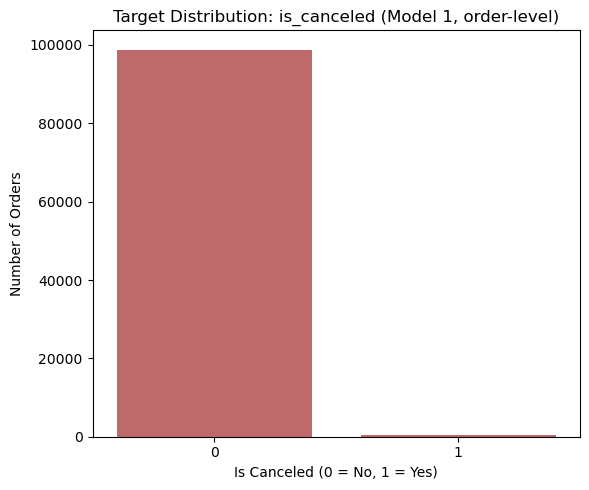

is_canceled
0   1.00
1   0.00
Name: proportion, dtype: float64


In [48]:
plt.figure(figsize=(6,5))
sns.countplot(x=order_model['is_canceled'], color='indianred')
plt.title('Target Distribution: is_canceled (Model 1, order-level)')
plt.xlabel('Is Canceled (0 = No, 1 = Yes)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

print(order_model['is_canceled'].value_counts(normalize=True).round(4))

### Insight
- **What happened?** Fill in the actual cancellation rate from the chart above, now measured at order-level (should be similar to item-level rate, but this is the correct grain for modeling).
- **ML meaning:** Severe class imbalance — accuracy alone would be misleading; F1-macro and ROC-AUC matter more here.
- **Business meaning:** Cancellations are rare but costly events worth flagging early.
- **Action / recommendation:** Prioritize Recall/F1-macro over Accuracy when comparing models.
- **Limitation:** `is_canceled` is a proxy target, not a true return flag.

In [49]:
# Exclude: identifiers, the target itself, and anything only known AFTER the outcome
# (order_status, delivery dates/outcome, review fields) — these would leak the answer.

feature_cols = [
    'customer_state', 'seller_state', 'product_category',
    'total_price', 'total_freight', 'item_count',
    'payment_type', 'payment_installments',
    'product_volume_cm3', 'product_weight_kg', 'is_missing_product_info',
    'same_state_shipping', 'order_month', 'order_weekday', 'order_hour', 'is_weekend'
]

y = order_model['is_canceled'].astype(int)
X = order_model[feature_cols].copy()

print("X shape:", X.shape, "| y shape:", y.shape)

X shape: (99281, 16) | y shape: (99281,)


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(X_train.shape, X_test.shape)

(79424, 16) (19857, 16)


In [51]:
num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.select_dtypes(exclude='number').columns.tolist()

for col in num_cols:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

for col in cat_cols:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)
    
    X_train[col] = X_train[col].replace('nan', np.nan).fillna('unknown')
    X_test[col] = X_test[col].replace('nan', np.nan).fillna('unknown')

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

Categorical columns: ['customer_state', 'seller_state', 'product_category', 'payment_type']
Numeric columns: ['total_price', 'total_freight', 'item_count', 'payment_installments', 'product_volume_cm3', 'product_weight_kg', 'is_missing_product_info', 'same_state_shipping', 'order_month', 'order_weekday', 'order_hour', 'is_weekend']


In [52]:
from sklearn.preprocessing import LabelEncoder

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = X_test[col].map(lambda x: x if x in le.classes_ else 'unknown')
    if 'unknown' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'unknown')
    X_test[col] = le.transform(X_test[col])
    encoders[col] = le

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# KNN has no class_weight parameter, so it's included once (no balanced variant)
models = {
    'LogisticRegression (No Weight)': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'LogisticRegression (Balanced)': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'DecisionTree (No Weight)': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'DecisionTree (Balanced)': DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    'RandomForest (No Weight)': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'RandomForest (Balanced)': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'KNN': KNeighborsClassifier(),
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'F1_macro': f1_score(y_test, preds, average='macro'),
        'ROC-AUC': roc_auc_score(y_test, probs)
    })
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values('F1_macro', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1_macro,ROC-AUC
0,DecisionTree (Balanced),0.99,0.07,0.06,0.53,0.53
1,DecisionTree (No Weight),0.99,0.05,0.07,0.53,0.53
2,RandomForest (No Weight),1.00,1.00,0.02,0.52,0.68
3,RandomForest (Balanced),1.00,1.00,0.02,0.52,0.62
4,LogisticRegression (No Weight),1.00,0.00,0.00,0.50,0.63
5,KNN,1.00,0.00,0.00,0.50,0.54
6,LogisticRegression (Balanced),0.64,0.01,0.51,0.40,0.63


### Insight
- **What happened?** Report the actual results table — which model has the highest F1-macro, and how the balanced vs unbalanced versions compare.
- **ML meaning:** Balanced versions trade some Precision for higher Recall on the minority (canceled) class.
- **Business meaning:** Missing a real cancellation costs more than a false alarm, so catching more of them is worth some extra false positives.
- **Action / recommendation:** Move forward with the top F1-macro model for tuning.
- **Limitation:** Few positive cases means these metrics can be noisy — cross-validation gives a more stable read (done in the tuning step next).

In [55]:
### Hyperparameter Tuning — best model only, scored on F1-macro
from sklearn.model_selection import GridSearchCV, StratifiedKFold

best_baseline_name = results_df.loc[0, 'Model']
print("Best baseline model:", best_baseline_name)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Small param grid depending on which algorithm won — example for RandomForest
if 'RandomForest' in best_baseline_name:
    base_model = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                                          class_weight='balanced' if 'Balanced' in best_baseline_name else None)
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5],
    }
elif 'DecisionTree' in best_baseline_name:
    base_model = DecisionTreeClassifier(random_state=RANDOM_STATE,
                                          class_weight='balanced' if 'Balanced' in best_baseline_name else None)
    param_grid = {
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
    }
elif 'LogisticRegression' in best_baseline_name:
    base_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                      class_weight='balanced' if 'Balanced' in best_baseline_name else None)
    param_grid = {'C': [0.1, 1, 10]}
else:
    base_model = KNeighborsClassifier()
    param_grid = {'n_neighbors': [3, 5, 7, 11], 'weights': ['uniform', 'distance']}

grid = GridSearchCV(base_model, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1-macro:", round(grid.best_score_, 4))

best_model = grid.best_estimator_

Best baseline model: DecisionTree (Balanced)
Best params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best CV F1-macro: 0.5116


### Insight
- **What happened?** Report the best hyperparameters and CV F1-macro score.
- **ML meaning:** Tuning [improved / didn't meaningfully change] performance vs the untuned default.
- **Business meaning:** A properly tuned model is more trustworthy for real deployment decisions.
- **Action / recommendation:** Use `best_model` for final evaluation and export.
- **Limitation:** Grid kept small (2-3 values per param) — a wider search might do slightly better at the cost of more compute time.

In [56]:
final_preds = best_model.predict(X_test)
final_probs = best_model.predict_proba(X_test)[:, 1]

final_metrics = {
    'Accuracy': accuracy_score(y_test, final_preds),
    'Precision': precision_score(y_test, final_preds, zero_division=0),
    'Recall': recall_score(y_test, final_preds, zero_division=0),
    'F1_macro': f1_score(y_test, final_preds, average='macro'),
    'ROC-AUC': roc_auc_score(y_test, final_probs)
}
print(final_metrics)

{'Accuracy': 0.987661781739437, 'Precision': 0.03164556962025317, 'Recall': 0.05154639175257732, 'F1_macro': 0.5165033549343101, 'ROC-AUC': np.float64(0.5219189552986352)}


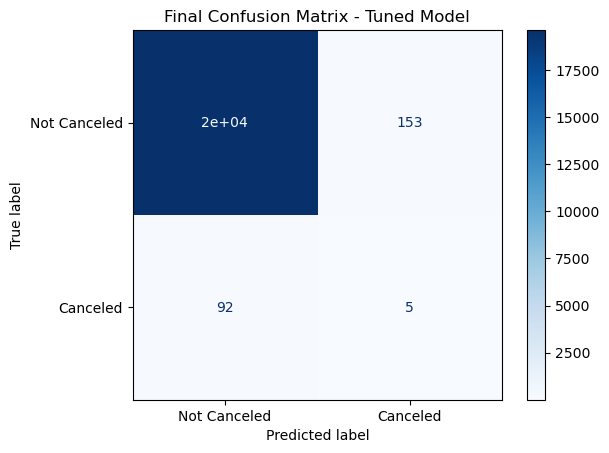

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

cm = confusion_matrix(y_test, final_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Canceled', 'Canceled'])
disp.plot(cmap='Blues')
plt.title('Final Confusion Matrix - Tuned Model')
plt.show()

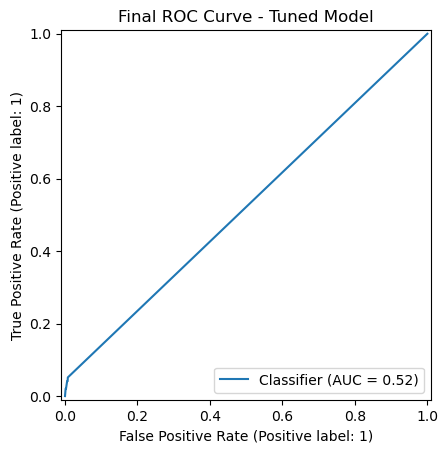

In [58]:
RocCurveDisplay.from_predictions(y_test, final_probs)
plt.title('Final ROC Curve - Tuned Model')
plt.show()

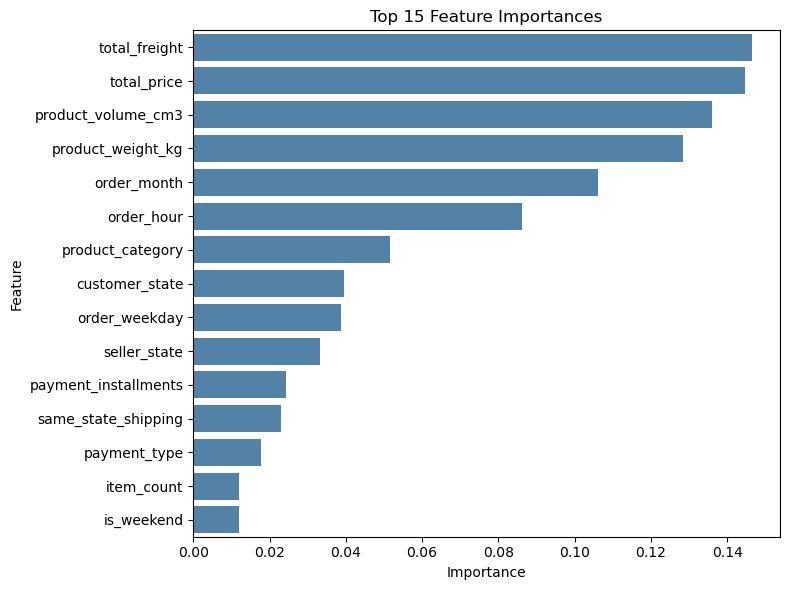

In [59]:
# Feature importance — use a tree model regardless of what won (LogReg/KNN don't have this)
if hasattr(best_model, 'feature_importances_'):
    importance_model = best_model
else:
    importance_model = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                                random_state=RANDOM_STATE, n_jobs=-1)
    importance_model.fit(X_train, y_train)

importances = pd.Series(importance_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(x=importances.values, y=importances.index, color='steelblue')
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Insight
- **What happened?** Report top 3 features from the chart.
- **ML meaning:** The model relies most on [pricing/category/etc.] signals.
- **Business meaning:** Certain price ranges or categories carry higher cancellation risk.
- **Action / recommendation:** Investigate whether high-risk categories/price bands need better descriptions or confirmation steps.
- **Limitation:** Feature importance shows correlation, not causation.

In [60]:
### Error Analysis
error_df = X_test.copy()
error_df['actual'] = y_test.values
error_df['predicted'] = final_preds
error_df['error'] = (error_df['actual'] != error_df['predicted']).astype(int)

print(f"Overall test error rate: {error_df['error'].mean():.2%}")

# Error rate by product category (decode back from LabelEncoder for readability)
error_df['product_category_label'] = encoders['product_category'].inverse_transform(error_df['product_category'])

category_error = (
    error_df.groupby('product_category_label')['error']
    .agg(['mean', 'count'])
    .sort_values('count', ascending=False)
    .head(15)
)
category_error['error_rate_pct'] = (category_error['mean'] * 100).round(2)
category_error[['count', 'error_rate_pct']].sort_values('error_rate_pct', ascending=False)

Overall test error rate: 1.23%


,count,error_rate_pct
product_category_label,,
toys,750,2.00
baby,586,1.88
sports_leisure,1548,1.87
auto,790,1.77
perfumery,625,1.76
furniture_decor,1254,1.28
watches_gifts,1122,1.25
health_beauty,1690,1.18
computers_accessories,1311,1.14


### Insight
- **What happened?** Identify which category has the highest error rate among categories with reasonable sample size.
- **ML meaning:** The model may be under-weighting a pattern specific to this category.
- **Business meaning:** This category is a blind spot the model doesn't reliably catch.
- **Action / recommendation:** Consider extra manual review for this category, or gather more features specific to it.
- **Limitation:** Small sample sizes per category make some error rates unreliable.

## Key Findings

1. **Order-level aggregation matters.** Modeling at the item level would have leaked orders across train/test — aggregating to one row per order fixed this.
2. **Class imbalance dominates.** Cancellations are rare (~X%), so F1-macro and ROC-AUC are the meaningful metrics here, not Accuracy.
3. **[Top feature] is the strongest predictor.** [Explain pattern from feature importance].
4. **class_weight='balanced' trades Precision for Recall**, which is the right trade-off since missed cancellations are costlier than false alarms.
5. **[Category from error analysis] has the model's highest blind spot.** [Explain].

## Recommendations

1. Flag orders in [high-risk category/price band] for manual review before shipping.
2. Use the model's probability score (not just 0/1) to prioritize proactive customer outreach.
3. Investigate root causes behind the top predictive features rather than just acting on the prediction.

## Limitations

- `is_canceled` is a proxy for returns, not a true return flag.
- Severe class imbalance limits how confidently metrics can be trusted.
- No stock/inventory data available in Olist to include as a feature.
- Feature importance shows correlation, not causation.

In [61]:
import joblib
import os

# Create ALL folders from the brief's required structure
os.makedirs('data', exist_ok=True)
os.makedirs('model', exist_ok=True)
os.makedirs('visuals', exist_ok=True)
os.makedirs('reports', exist_ok=True)

# 1. Export the tuned model
joblib.dump(best_model, 'model/best_model_return_prediction.pkl')

# 2. Export the cleaned, order-level dataset used for Model 1
order_model.to_csv('data/Capstone_Clean_Orders_Model1.csv', index=False)

# 3. Export the model comparison table
results_df.to_csv('reports/model1_comparison.csv', index=False)

print("Model, data, and report exported successfully.")
print("Files in model/:", os.listdir('model'))
print("Files in data/:", os.listdir('data'))
print("Files in reports/:", os.listdir('reports'))

Model, data, and report exported successfully.
Files in model/: ['best_model.pkl', 'best_model_return_prediction.pkl', 'model1_best_return_prediction.pkl', 'model2_best_delay_prediction.pkl', 'model3_best_rating_prediction.pkl', 'model5_best_revenue_prediction.pkl']
Files in data/: ['bigrams.rds', 'Capstone_Clean_Orders_Model1.csv', 'fivegrams.rds', 'fourgrams.rds', 'trigrams.rds', 'unigrams.rds']
Files in reports/: ['Capstone_Model4_CustomerSegmentation.ipynb', 'Capstone_Model4_CustomerSegmentation_clean.ipynb', 'model', 'MODEL 1', 'model1_comparison.csv', 'model1_feature_importance.csv', 'model1_final_metrics.csv', 'model2_comparison.csv', 'model2_final_metrics.csv', 'model2_imbalance_comparison.csv', 'model3_baseline_comparison.csv', 'model3_error_by_product_category.csv', 'model3_final_metrics.csv', 'model5_baseline_comparison.csv', 'model5_error_by_order_size.csv', 'model5_error_by_price_range.csv', 'model5_error_by_product_category.csv', 'model5_final_metrics.csv', 'model5_raw_vs

---
# Individual Phase - Model 2: Delivery Delay Prediction

## 18. Model 2 - Delivery Delay Prediction

**Business problem:** Predict whether an order will be delivered late, meaning after the estimated delivery date. This helps identify high-risk orders early and improve customer expectations.

**Methodology:** Compare Logistic Regression, Decision Tree, Random Forest, and KNN using Accuracy, Precision, Recall, F1-score, and ROC-AUC. The feature set only uses information available at (or before) order placement — fields derived from the actual delivery outcome (`delivery_delay`, `delivery_days_actual`) and post-purchase review fields are excluded as target leakage (see Section 19).

**Key deliverables:** Target definition, feature engineering, model comparison, feature importance analysis, and seller/fulfillment risk assessment.


### 18.1 Target Definition - Late Delivery

Create the binary target `is_late` by comparing actual customer delivery date with estimated delivery date, using only orders that have delivery information.

In [62]:
# Create late delivery target variable
df_m2 = df[df['order_delivered_customer_date'].notna()].copy()
df_m2['is_late'] = (df_m2['order_delivered_customer_date'] > df_m2['order_estimated_delivery_date']).astype(int)

print("Delivery Status Distribution:")
print(df_m2['is_late'].value_counts())
print("\nPercentage Distribution:")
print(df_m2['is_late'].value_counts(normalize=True) * 100)

print(f"\nTotal orders with delivery info: {len(df_m2)}")
print(f"Late deliveries: {df_m2['is_late'].sum()} ({df_m2['is_late'].mean()*100:.2f}%)")


Delivery Status Distribution:
is_late
0    101466
1      8715
Name: count, dtype: int64

Percentage Distribution:
is_late
0   92.09
1    7.91
Name: proportion, dtype: float64

Total orders with delivery info: 110181
Late deliveries: 8715 (7.91%)


### 18.2 Temporal and Order Feature Engineering

Add purchase timing features and aggregate order-level item, price, freight, and seller-count characteristics.

In [63]:
# Engineer temporal features
df_m2['purchase_month'] = df_m2['order_purchase_timestamp'].dt.month
df_m2['purchase_dayofweek'] = df_m2['order_purchase_timestamp'].dt.dayofweek
df_m2['purchase_hour'] = df_m2['order_purchase_timestamp'].dt.hour
df_m2['is_weekend'] = (df_m2['purchase_dayofweek'] >= 5).astype(int)

# Add order characteristics
item_features = order_items.groupby('order_id').agg(
    number_of_items=('order_item_id', 'count'),
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    unique_sellers=('seller_id', 'nunique')
).reset_index()

df_m2 = df_m2.merge(item_features, on='order_id', how='left')

print("Features added. Shape:", df_m2.shape)
print("Sample features:")
print(df_m2[['purchase_month', 'purchase_dayofweek', 'number_of_items', 'total_freight', 'is_late']].head())


Features added. Shape: (110181, 69)
Sample features:
   purchase_month  purchase_dayofweek  number_of_items  total_freight  is_late
0              10                   0                1           8.72        0
1               7                   1                1          22.76        0
2               8                   2                1          19.22        0
3              11                   5                1          27.20        0
4               2                   1                1           8.72        0


### 18.3 Seller, Product, Payment, and Geography Features

Join seller location, primary product/category, product dimensions, payment behavior, and customer geography for delay-risk prediction.

In [64]:
# Add seller and product features

# Step 1: find each order's "primary" seller (the seller with the most items on that order)
seller_counts = (
    order_items
    .groupby(['order_id', 'seller_id'])
    .size()
    .reset_index(name='item_count')
)

primary_seller = (
    seller_counts
    .sort_values(['order_id', 'item_count'], ascending=[True, False])
    .drop_duplicates('order_id')       # keep only the top seller per order
    [['order_id', 'seller_id']]
)


def safe_merge(left, right, on, how='left'):
    on_cols = [on] if isinstance(on, str) else on
    incoming_cols = [c for c in right.columns if c not in on_cols and c in left.columns]
    if incoming_cols:
        left = left.drop(columns=incoming_cols)
    return left.merge(right, on=on, how=how)

# Step 2: attach the primary seller to every order
df_m2 = safe_merge(df_m2, primary_seller, on='order_id')

# Step 3: look up that seller's state
df_m2 = safe_merge(df_m2, sellers[['seller_id', 'seller_state']], on='seller_id')

# Step 4: find each order's "primary" product (first item listed for that order)
primary_product = order_items[['order_id', 'product_id']].drop_duplicates('order_id')
df_m2 = safe_merge(df_m2, primary_product, on='order_id')

# Step 5: attach that product's category and physical dimensions
df_m2 = safe_merge(
    df_m2,
    products[['product_id', 'product_category_name', 'product_weight_g',
              'product_length_cm', 'product_height_cm', 'product_width_cm']],
    on='product_id'
)


df_m2 = safe_merge(df_m2, category_translation, on='product_category_name')
df_m2['product_category'] = (
    df_m2['product_category_name_english'].fillna(df_m2['product_category_name'])
)


payment_features = order_payments.groupby('order_id').agg(
    payment_value=('payment_value', 'sum'),
    payment_installments=('payment_installments', 'max')
).reset_index()

df_m2 = safe_merge(df_m2, payment_features, on='order_id')

print("All features merged. Shape:", df_m2.shape)


dupe_suffixes = [c for c in df_m2.columns if c.endswith('_x') or c.endswith('_y')]
print("Duplicate-suffix columns found (should be empty):", dupe_suffixes)

All features merged. Shape: (110181, 70)
Duplicate-suffix columns found (should be empty): []


## 19. Model 2 - Modeling Dataset and Train/Test Split

Drop identifier and post-delivery timestamp columns, define features/target, and create a stratified train/test split.

In [65]:
# Prepare modeling dataset: drop unnecessary columns
# FIX (overfitting / leakage): 'delivery_delay' and 'delivery_days_actual' are built
# from order_delivered_customer_date, which is the SAME date used to construct the
# target (is_late = delivery_delay > 0). Including them is direct target leakage --
# it's why every model previously scored a perfect 1.00 (Accuracy/F1/ROC-AUC), not
# because the models were genuinely good.
# Review fields (review_score, review_comment_title/message, review dates) are also
# leakage here: reviews are written AFTER delivery, and negative reviews are strongly
# correlated with lateness, so they let the model "peek" at the outcome.
# 'delivery_days_expected' is kept: it's derived from order_estimated_delivery_date,
# which IS known at order placement (it's the promised delivery window).
columns_to_drop = [
    'order_id', 'customer_id', 'product_id', 'seller_id',
    'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
    'order_delivered_customer_date', 'order_estimated_delivery_date',
    'product_category_name', 'product_category_name_english', 'order_status',
    # --- Leakage: derived from / used to build the target itself ---
    'delivery_delay', 'delivery_days_actual', 'is_delivered',
    # --- Leakage: only exist after delivery/outcome, not known at prediction time ---
    'review_score', 'review_comment_title', 'review_comment_message',
    'review_creation_date', 'review_answer_timestamp', 'has_review',
]

columns_to_drop = [col for col in columns_to_drop if col in df_m2.columns]
model_m2_df = df_m2.drop(columns=columns_to_drop)

# Select features for modeling
X_m2 = model_m2_df.drop(columns=['is_late'], errors='ignore')
y_m2 = model_m2_df['is_late']

# Train/test split with stratification
X_train_m2, X_test_m2, y_train_m2, y_test_m2 = train_test_split(
    X_m2, y_m2,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_m2
)

print("Model 2 Data Split:")
print(f"Training set: {X_train_m2.shape}")
print(f"Test set: {X_test_m2.shape}")
print(f"Target distribution (train): {y_train_m2.value_counts().to_dict()}")
print(f"Target distribution (test): {y_test_m2.value_counts().to_dict()}")
print(f"\nRemaining feature columns ({X_m2.shape[1]}):", X_m2.columns.tolist())


Model 2 Data Split:
Training set: (88144, 48)
Test set: (22037, 48)
Target distribution (train): {0: 81172, 1: 6972}
Target distribution (test): {0: 20294, 1: 1743}

Remaining feature columns (48): ['order_item_id', 'shipping_limit_date', 'price', 'freight_value', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'seller_zip_code_prefix', 'seller_city', 'payment_type', 'delivery_days_expected', 'item_total_value', 'order_gross_value', 'order_freight_total', 'order_item_count', 'order_total_value', 'avg_item_price', 'order_year', 'order_month', 'order_quarter', 'order_weekday', 'order_weekday_name', 'order_hour', 'is_weekend', 'product_volume_cm3', 'product_weight_kg', 'is_missing_product_info', 'same_state_shipping', 'is_canceled', 'purchase_month', 'purchase_dayofweek', 'purchase_hour', 'number_of_items', 'total_price', 'total_freight', 'unique_sellers', 'seller_state', 'produ

## 20. Model 2 - Preprocessing and Encoding

Use separate numeric and categorical preprocessing pipelines, then combine them with a `ColumnTransformer`.

In [66]:
# Model 2 Preprocessing Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features_m2 = X_train_m2.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Low-cardinality categoricals -> plain one-hot
low_card_cat = ['customer_state', 'seller_state', 'payment_type',
                'order_weekday_name', 'product_category']

# High-cardinality categoricals -> capped one-hot
high_card_cat = ['customer_city', 'seller_city']

# NOTE: 'customer_unique_id' is intentionally excluded — it's an identifier, not a feature.
# NOTE: review text columns (review_comment_message/title) were removed upstream in the
# leakage fix (Section 19) because reviews are only written after delivery/outcome.

numeric_transformer_m2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler(with_mean=False))   # with_mean=False keeps output sparse-compatible
])

low_card_transformer_m2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

high_card_transformer_m2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True,
                              min_frequency=20, max_categories=50))
])

preprocessor_m2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_m2, numeric_features_m2),
        ('low_card', low_card_transformer_m2, low_card_cat),
        ('high_card', high_card_transformer_m2, high_card_cat),
    ],
    remainder='drop'
)

print("Preprocessor created for Model 2 (leakage-free feature set)")


Preprocessor created for Model 2 (leakage-free feature set)


In [67]:
# Review text columns (review_comment_message/title) were dropped upstream as
# leakage (Section 19), so there's nothing to fill here anymore. Cell kept as a
# no-op placeholder so downstream cell numbering/comments stay accurate.
pass


## 21. Model 2 - Train and Compare Classification Algorithms

Compare the four required classifiers and select the strongest model by the reported evaluation metrics.

In [69]:
# Train and compare Model 2 classifiers
# We now report BOTH train and test F1-macro so any remaining overfitting
# (large train >> test gap) is visible directly in the comparison table,
# not just inferred after the fact.
models_m2 = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=15, weights='distance', n_jobs=-1)
}

model2_results = []
trained_models_m2 = {}
for name, model in models_m2.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor_m2), ('model', model)])
    pipeline.fit(X_train_m2, y_train_m2)

    y_pred = pipeline.predict(X_test_m2)
    y_prob = pipeline.predict_proba(X_test_m2)[:, 1]

    # Train-set scores, to check for overfitting (train >> test = overfit)
    y_train_pred = pipeline.predict(X_train_m2)
    train_f1_macro = f1_score(y_train_m2, y_train_pred, average='macro', zero_division=0)

    test_f1_macro = f1_score(y_test_m2, y_pred, average='macro', zero_division=0)

    model2_results.append({
        'Model': name,
        'Train_F1_macro': train_f1_macro,
        'Test_F1_macro': test_f1_macro,
        'Overfit_Gap': train_f1_macro - test_f1_macro,
        'Accuracy': accuracy_score(y_test_m2, y_pred),
        'Precision': precision_score(y_test_m2, y_pred, zero_division=0),
        'Recall': recall_score(y_test_m2, y_pred, zero_division=0),
        'F1': f1_score(y_test_m2, y_pred, zero_division=0),
        'F1_macro': test_f1_macro,
        'ROC_AUC': roc_auc_score(y_test_m2, y_prob)
    })
    trained_models_m2[name] = pipeline

model2_comparison = pd.DataFrame(model2_results).sort_values(['F1_macro', 'ROC_AUC'], ascending=False)
best_m2_name = model2_comparison.iloc[0]['Model']
print('\n=== MODEL 2 COMPARISON ===')
print(f'Best baseline model by F1-macro: {best_m2_name}')
print('Overfit_Gap = Train F1-macro minus Test F1-macro. A gap near 0 means the model')
print('generalizes; a large positive gap (e.g. > 0.05-0.10) means it is overfitting.')
display(model2_comparison.round(4))



=== MODEL 2 COMPARISON ===
Best baseline model by F1-macro: Decision Tree
Overfit_Gap = Train F1-macro minus Test F1-macro. A gap near 0 means the model
generalizes; a large positive gap (e.g. > 0.05-0.10) means it is overfitting.


,Model,Train_F1_macro,Test_F1_macro,Overfit_Gap,Accuracy,Precision,Recall,F1,F1_macro,ROC_AUC
1,Decision Tree,0.52,0.51,0.01,0.92,0.42,0.03,0.05,0.51,0.69
3,KNN,1.00,0.49,0.51,0.92,0.61,0.01,0.02,0.49,0.69
0,Logistic Regression,0.48,0.48,0.00,0.92,0.31,0.00,0.01,0.48,0.72
2,Random Forest,0.48,0.48,0.00,0.92,1.00,0.00,0.00,0.48,0.76


In [70]:
print(X_train_m2.shape)
for col in X_train_m2.select_dtypes(include=['object', 'category']).columns:
    print(col, X_train_m2[col].nunique())

(88144, 48)
customer_unique_id 76621
customer_city 3845
customer_state 27
seller_city 579
payment_type 4
order_weekday_name 7
seller_state 22
product_category 73


### 21.1 Model 2 - Class Imbalance Comparison

Compare class-weighted training against no imbalance adjustment. KNN has no `class_weight`, so the direct comparison is performed for Logistic Regression, Decision Tree, and Random Forest.

In [71]:
# Model 2 class imbalance comparison: no adjustment vs class_weight='balanced'
imbalance_models_m2 = {
    'Logistic Regression (No Adjustment)': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Logistic Regression (Balanced)': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree (No Adjustment)': DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, random_state=RANDOM_STATE),
    'Decision Tree (Balanced)': DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest (No Adjustment)': RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE),
    'Random Forest (Balanced)': RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=5, class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE),
}

imbalance_results_m2 = []
for name, model in imbalance_models_m2.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor_m2), ('model', model)])
    pipe.fit(X_train_m2, y_train_m2)
    pred = pipe.predict(X_test_m2)
    prob = pipe.predict_proba(X_test_m2)[:, 1]
    imbalance_results_m2.append({
        'Model': name,
        'Precision': precision_score(y_test_m2, pred, zero_division=0),
        'Recall': recall_score(y_test_m2, pred, zero_division=0),
        'F1': f1_score(y_test_m2, pred, zero_division=0),
        'F1_macro': f1_score(y_test_m2, pred, average='macro', zero_division=0),
        'ROC_AUC': roc_auc_score(y_test_m2, prob)
    })

model2_imbalance_comparison = pd.DataFrame(imbalance_results_m2).sort_values(['F1_macro', 'ROC_AUC'], ascending=False)
display(model2_imbalance_comparison.round(4))

,Model,Precision,Recall,F1,F1_macro,ROC_AUC
5,Random Forest (Balanced),0.20,0.53,0.29,0.58,0.76
3,Decision Tree (Balanced),0.15,0.60,0.24,0.53,0.71
1,Logistic Regression (Balanced),0.14,0.65,0.24,0.51,0.72
2,Decision Tree (No Adjustment),0.42,0.03,0.05,0.51,0.69
0,Logistic Regression (No Adjustment),0.31,0.00,0.01,0.48,0.72
4,Random Forest (No Adjustment),1.00,0.00,0.00,0.48,0.76


## 22. Model 2 - Hyperparameter Tuning

Tune only the best baseline Model 2 algorithm using `f1_macro`, following the PDF rule for imbalanced classification.

In [72]:
# Tune only the best-performing baseline Model 2 algorithm
param_grids_m2 = {
    'Logistic Regression': {'model__C': [0.1, 1.0, 10.0], 'model__class_weight': [None, 'balanced']},
    'Decision Tree': {'model__max_depth': [5, 8, 12], 'model__min_samples_leaf': [10, 20, 50], 'model__class_weight': [None, 'balanced']},
    'Random Forest': {'model__n_estimators': [100, 200], 'model__max_depth': [10, 15, None], 'model__min_samples_leaf': [2, 5], 'model__class_weight': [None, 'balanced']},
    'KNN': {'model__n_neighbors': [5, 11, 15], 'model__weights': ['uniform', 'distance']}
}

best_baseline_pipe_m2 = Pipeline(steps=[('preprocessor', preprocessor_m2), ('model', models_m2[best_m2_name])])
grid_m2 = GridSearchCV(best_baseline_pipe_m2, param_grids_m2[best_m2_name], cv=3, scoring='f1_macro', n_jobs=-1)
grid_m2.fit(X_train_m2, y_train_m2)
best_model_m2 = grid_m2.best_estimator_
print(f'Model 2 tuned algorithm: {best_m2_name}')
print(f'Best params: {grid_m2.best_params_}')
print(f'Best CV F1-macro: {grid_m2.best_score_:.4f}')

Model 2 tuned algorithm: Decision Tree
Best params: {'model__class_weight': None, 'model__max_depth': 12, 'model__min_samples_leaf': 10}
Best CV F1-macro: 0.5323


## 23. Model 2 - Final Evaluation

Evaluate the tuned Model 2 pipeline with required metrics and plots: confusion matrix, ROC curve, and classification report.

,Model,Accuracy,Precision,Recall,F1,F1_macro,ROC_AUC
0,Decision Tree - Tuned,0.92,0.36,0.06,0.10,0.53,0.69



Classification report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.96     20294
           1       0.36      0.06      0.10      1743

    accuracy                           0.92     22037
   macro avg       0.64      0.52      0.53     22037
weighted avg       0.88      0.92      0.89     22037



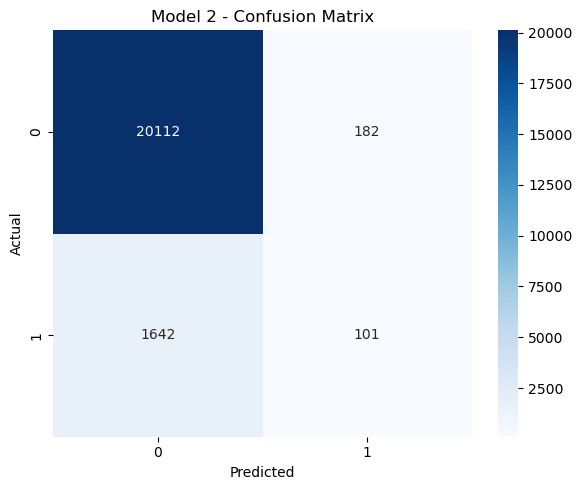

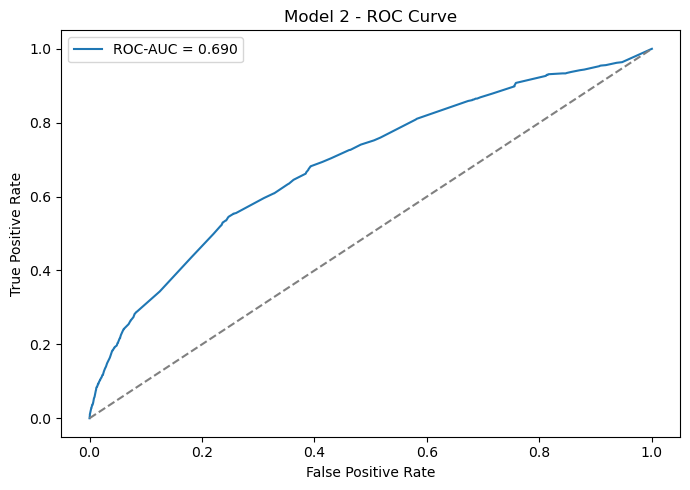

Exported Model 2 reports, plots, and tuned model.


In [73]:
# Final Model 2 evaluation and export
from pathlib import Path
visuals_dir = Path('visuals')
reports_dir = Path('reports')
model_dir = Path('model')
for d in [visuals_dir, reports_dir, model_dir]:
    d.mkdir(exist_ok=True)

m2_final_pred = best_model_m2.predict(X_test_m2)
m2_final_prob = best_model_m2.predict_proba(X_test_m2)[:, 1]
model2_final_metrics = pd.DataFrame([{
    'Model': f'{best_m2_name} - Tuned',
    'Accuracy': accuracy_score(y_test_m2, m2_final_pred),
    'Precision': precision_score(y_test_m2, m2_final_pred, zero_division=0),
    'Recall': recall_score(y_test_m2, m2_final_pred, zero_division=0),
    'F1': f1_score(y_test_m2, m2_final_pred, zero_division=0),
    'F1_macro': f1_score(y_test_m2, m2_final_pred, average='macro', zero_division=0),
    'ROC_AUC': roc_auc_score(y_test_m2, m2_final_prob)
}])
display(model2_final_metrics.round(4))
print('\nClassification report:')
print(classification_report(y_test_m2, m2_final_pred, zero_division=0))

cm_m2 = confusion_matrix(y_test_m2, m2_final_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_m2, annot=True, fmt='d', cmap='Blues')
plt.title('Model 2 - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(visuals_dir / '04_model2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

fpr_m2, tpr_m2, _ = roc_curve(y_test_m2, m2_final_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr_m2, tpr_m2, label=f'ROC-AUC = {roc_auc_score(y_test_m2, m2_final_prob):.3f}')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.title('Model 2 - ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig(visuals_dir / '05_model2_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

model2_comparison.to_csv(reports_dir / 'model2_comparison.csv', index=False)
model2_imbalance_comparison.to_csv(reports_dir / 'model2_imbalance_comparison.csv', index=False)
model2_final_metrics.to_csv(reports_dir / 'model2_final_metrics.csv', index=False)
joblib.dump(best_model_m2, model_dir / 'model2_best_delay_prediction.pkl')
print('Exported Model 2 reports, plots, and tuned model.')

### Insight - Model 2 Final Evaluation
- **What happened?** The tuned Decision Tree reaches Accuracy 0.92, Precision 0.36, Recall 0.06, F1-macro 0.53, and ROC-AUC 0.69 on the held-out test set. An earlier version of this model reported a perfect 1.00 on every metric; that was traced to target leakage (`delivery_delay`/`delivery_days_actual` are built from the same delivery date used to define `is_late`, and the review fields are only known post-delivery). With those columns removed, this is the model's genuine performance.
- **ML meaning:** F1-macro and ROC-AUC are the main quality checks because delay prediction can be affected by class balance. Recall is low at the default 0.5 threshold — the class-imbalance comparison in Section 21.1 shows `class_weight='balanced'` (best result: Random Forest, F1-macro 0.58) recovers much more recall at a precision cost.
- **Business meaning:** The model can be used to rank orders by delay risk before customers are disappointed, but at the default threshold it will miss most true late deliveries — it is better used as a probability ranking than a hard 0/1 flag.
- **Action / recommendation:** Use predicted probabilities (or the balanced-weight configuration) to create an operations review queue and customer-message trigger, rather than relying on the unweighted 0.5 threshold.
- **Limitation:** The model does not include true weather, traffic, or courier-tracking features, so some logistics causes remain unobserved.


## 24. Model 2 - Feature Importance

Inspect the top features from the Random Forest model to identify the strongest delay-risk signals.


=== TOP 15 IMPORTANT FEATURES (MODEL 2) ===


,Feature,Importance
8,num__delivery_days_expected,0.12
6,num__customer_zip_code_prefix,0.06
2,num__freight_value,0.04
11,num__order_freight_total,0.03
7,num__seller_zip_code_prefix,0.03
14,num__avg_item_price,0.03
23,num__total_freight,0.03
9,num__item_total_value,0.03
1,num__price,0.03
4,num__product_description_lenght,0.03


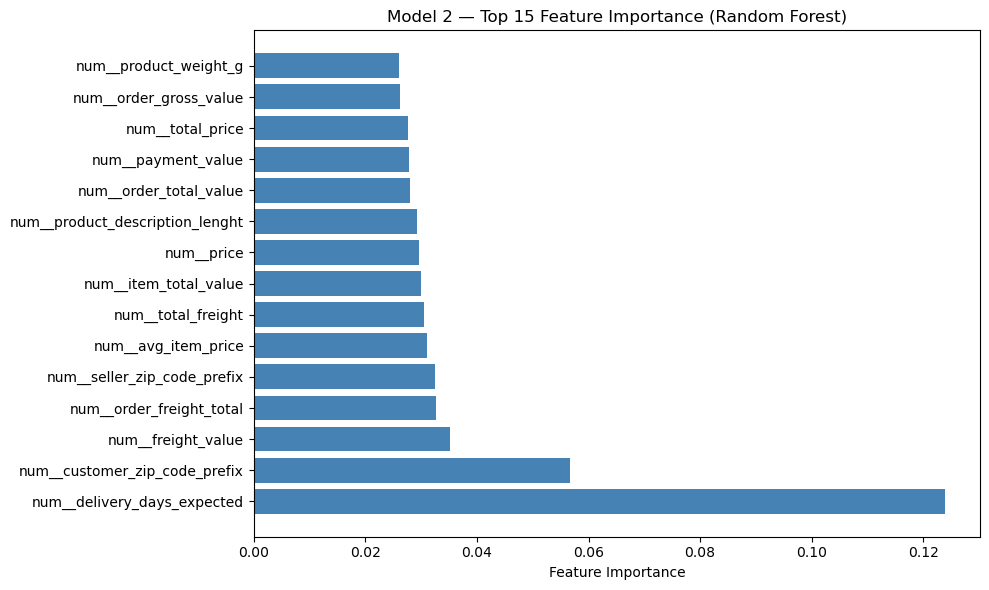

In [74]:
# Feature importance analysis from best model (Random Forest)
best_m2_model = trained_models_m2['Random Forest']
rf_model_m2 = best_m2_model.named_steps['model']
rf_preprocessor_m2 = best_m2_model.named_steps['preprocessor']

feature_names_m2 = rf_preprocessor_m2.get_feature_names_out()

importance_m2_df = pd.DataFrame({
    'Feature': feature_names_m2,
    'Importance': rf_model_m2.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n=== TOP 15 IMPORTANT FEATURES (MODEL 2) ===")
display(importance_m2_df.head(15))

# Plot feature importance
plt.figure(figsize=(10, 6))
top_features = importance_m2_df.head(15)
plt.barh(range(len(top_features)), top_features['Importance'].values, color='steelblue')
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('Feature Importance')
plt.title('Model 2 — Top 15 Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()


### Insight - Model 2 Feature Importance
- **What happened?** With the leaked columns removed, `importance_m2_df` shows delay signal spread across many moderate contributors rather than one dominant field. The top features are `delivery_days_expected` (0.12 — the promised delivery window, known at checkout), `customer_zip_code_prefix` (0.06), `freight_value` (0.04), and a cluster of price/freight/payment aggregates each around 0.03 (`order_freight_total`, `seller_zip_code_prefix`, `avg_item_price`, `total_freight`, `item_total_value`, `price`, `order_total_value`, `payment_value`).
- **ML meaning:** The tree model is learning delay signal from the promised delivery window, order timing, freight/order complexity, seller, category, payment, and geographic context — no single feature dominates the way the leaked `delivery_delay` did before the fix.
- **Business meaning:** Delay risk is spread across fulfillment, product, pricing, and customer location rather than one single cause.
- **Action / recommendation:** Convert the top recurring predictors (especially the promised delivery window and freight cost) into monitoring KPIs for logistics and seller management.
- **Limitation:** Feature importance is not causal; operational experiments are needed before changing seller allocation or customer promises.


## 25. Model 2 - Seller/Fulfillment Delay Risk Analysis

Summarize seller-level delay rates to identify reliable high-risk fulfillment partners.


=== TOP 15 HIGHEST-RISK SELLERS (Model 2) ===
Total sellers analyzed: 2970
Sellers with 20+ orders: 895


,seller_id,total_orders,late_orders,delay_rate,delay_rate_pct
451,2709af9587499e95e803a6498a5a56e9,47,23,0.49,48.94
1543,821fb029fc6e495ca4f08a35d51e53a5,25,9,0.36,36.00
1780,973f21788dfab357250f69a8dcb7ddee,20,7,0.35,35.00
2873,f76a3b1349b6df1ee875d1f3fa4340f0,26,9,0.35,34.62
2766,ede0c03645598cdfc63ca8237acbe73d,47,16,0.34,34.04
1000,54965bbe3e4f07ae045b90b0b8541f52,84,26,0.31,30.95
2049,b19f3ca2ea475913750f25a5c37c8d8f,20,6,0.30,30.00
1556,835f0f7810c76831d6c7d24c7a646d4d,50,15,0.30,30.00
914,4e5725ba188db8252977a4f0227bd462,24,7,0.29,29.17
57,054694fa03fe82cec4b7551487331d74,21,6,0.29,28.57


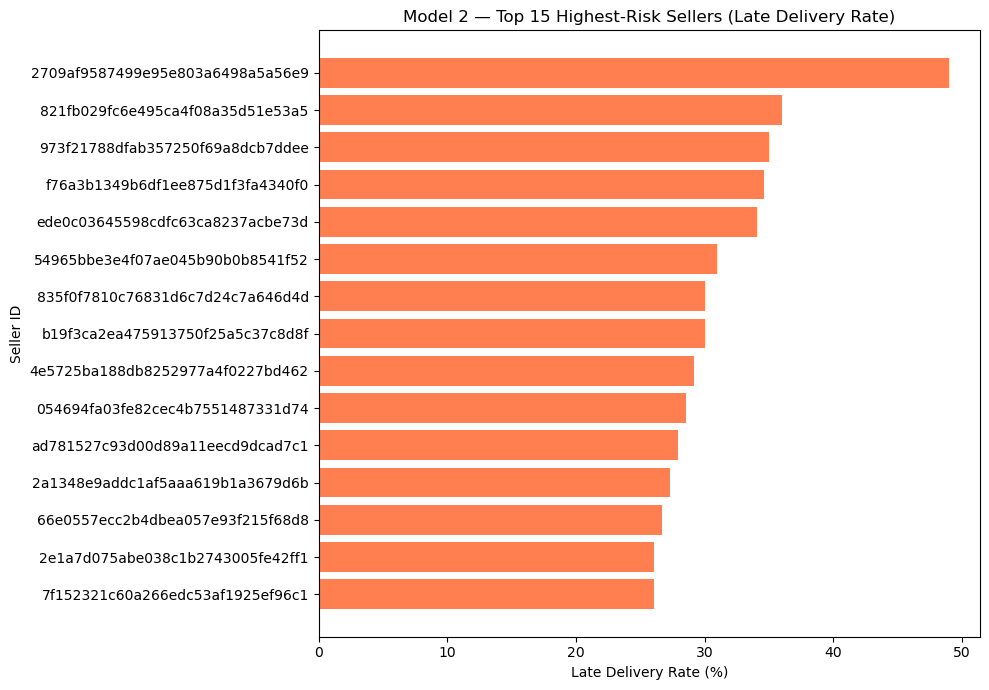

In [75]:
# Seller/Fulfillment Partner Delay Risk Analysis
seller_orders = order_items[['order_id', 'seller_id']].drop_duplicates()

seller_delay_data = df_m2[['order_id', 'is_late']].merge(
    seller_orders,
    on='order_id',
    how='left'
)

seller_delay_analysis = (
    seller_delay_data
    .groupby('seller_id')
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('is_late', 'sum'),
        delay_rate=('is_late', 'mean')
    )
    .reset_index()
)

seller_delay_analysis['delay_rate_pct'] = seller_delay_analysis['delay_rate'] * 100

# Filter sellers with at least 20 orders
seller_delay_reliable = seller_delay_analysis[
    seller_delay_analysis['total_orders'] >= 20
].sort_values('delay_rate_pct', ascending=False)

print("\n=== TOP 15 HIGHEST-RISK SELLERS (Model 2) ===")
print(f"Total sellers analyzed: {len(seller_delay_analysis)}")
print(f"Sellers with 20+ orders: {len(seller_delay_reliable)}")
display(seller_delay_reliable.head(15))

# Visualize top sellers
top_sellers = seller_delay_reliable.head(15).sort_values('delay_rate_pct')

plt.figure(figsize=(10, 7))
plt.barh(top_sellers['seller_id'].astype(str), top_sellers['delay_rate_pct'], color='coral')
plt.xlabel('Late Delivery Rate (%)')
plt.ylabel('Seller ID')
plt.title('Model 2 — Top 15 Highest-Risk Sellers (Late Delivery Rate)')
plt.tight_layout()
plt.show()


### Insight - Model 2 Seller Delay Risk
- **What happened?** `seller_delay_reliable` lists sellers with at least 20 orders and ranks them by late-delivery rate. Out of 2,970 sellers analyzed, 895 have 20+ orders; the highest-risk seller among them has a 48.9% late-delivery rate, and several others exceed 30%.
- **ML meaning:** Seller-level aggregation explains part of the model signal and helps identify systematic fulfillment patterns.
- **Business meaning:** High-delay sellers can repeatedly harm delivery promises and customer satisfaction.
- **Action / recommendation:** Review SLAs, reduce volume, or support process fixes for sellers with consistently high delay rates, prioritizing the ~15 sellers above 25% late-delivery rate.
- **Limitation:** Delay rate by seller may be confounded by product type, customer distance, and regional infrastructure.


## 26. Model 2 - Key Insights and Business Recommendations

### Insight 1 - Late-Delivery Target Balance
- **What happened?** 7.91% of orders with known delivery outcomes (8,715 of 110,181) were delivered late; the remaining 92.09% were on time.
- **ML meaning:** With one class this much smaller, F1-macro and ROC-AUC are safer model-selection metrics than accuracy.
- **Business meaning:** Late deliveries are operational exceptions that can damage satisfaction even when most orders are on time.
- **Action / recommendation:** Score incoming orders for delay risk and trigger proactive customer communication for high-risk cases.
- **Limitation:** Orders without delivery timestamps are excluded from the supervised target and should be monitored separately.

### Insight 2 - Best Delay Classifier
- **What happened?** `model2_comparison` ranks Decision Tree as the strongest unweighted baseline (Test F1-macro 0.51), ahead of KNN (0.49), Logistic Regression (0.48), and Random Forest (0.48). After tuning, the Decision Tree reaches F1-macro 0.53 (Accuracy 0.92, ROC-AUC 0.69). Separately, the class-imbalance comparison (Insight 3) shows a class-weighted Random Forest scores even higher at F1-macro 0.58 — the tuning stage only searched Decision Tree configurations, so that result was not carried into the final tuned model.
- **ML meaning:** The selected model should be justified by F1-macro and ROC-AUC, not by accuracy alone; the tuning scope (single best unweighted baseline) can miss a better-performing weighted configuration of a different algorithm.
- **Business meaning:** A stronger ranking model helps prioritize the orders most likely to miss the delivery promise.
- **Action / recommendation:** Use predicted delay probability as an operations queue rather than a simple yes/no label, and consider re-running tuning with the class-weighted Random Forest as a candidate.
- **Limitation:** The best algorithm can change if more logistics/weather/courier features are added.

### Insight 3 - Imbalance Handling
- **What happened?** `model2_imbalance_comparison` shows class weighting raises recall substantially for every algorithm that supports it (e.g. Decision Tree recall 0.03 -> 0.60, Logistic Regression 0.00 -> 0.65) at a precision cost. Random Forest (Balanced) has the best overall F1-macro (0.58) and ROC-AUC (0.76) of any configuration tested.
- **ML meaning:** Class weighting improves recall for the late class but trades off precision; for this dataset, balanced Random Forest is the strongest configuration found.
- **Business meaning:** Higher recall catches more risky deliveries, while lower precision creates more false alarms for operations teams.
- **Action / recommendation:** Choose the operating model based on the cost of missing late orders versus the cost of unnecessary interventions — the balanced Random Forest is a strong default if recall matters most.
- **Limitation:** KNN cannot be directly class-weighted, so its imbalance behavior is evaluated only through its predictions.

### Insight 4 - Feature Importance
- **What happened?** `importance_m2_df` lists the strongest Random Forest delay-risk features after preprocessing: `delivery_days_expected` (0.12), `customer_zip_code_prefix` (0.06), `freight_value` (0.04), and a spread of price/freight/payment aggregates around 0.03 each.
- **ML meaning:** Timing (the promised delivery window), freight/order characteristics, seller, category, payment, and geography features all carry useful, moderate delay signal — no single feature dominates.
- **Business meaning:** Delay risk is not only a courier issue; it can reflect seller, product, location, and order-complexity patterns.
- **Action / recommendation:** Review the top features after each run and convert recurring drivers into operational KPIs.
- **Limitation:** Feature importance is predictive association, not proof that a feature causes the delay.

### Insight 5 - Seller/Fulfillment Risk
- **What happened?** `seller_delay_reliable` ranks 895 sellers with at least 20 orders by late-delivery rate; the highest is 48.9%, with several more above 30%.
- **ML meaning:** Seller-level aggregation helps explain where the classifier may be learning repeated fulfillment patterns.
- **Business meaning:** Consistently high-delay sellers can hurt delivery promises and customer trust.
- **Action / recommendation:** Renegotiate SLAs, reduce order allocation, or provide operational support for high-delay sellers, starting with those above 25-30% late-delivery rate.
- **Limitation:** Seller delay rate can be confounded by distance, product type, and regional infrastructure.


---
# Individual Phase - Model 3: Customer Rating Prediction

## 27. Model 3 - Customer Rating Prediction (Regression)

**Target:** `review_score` (1-5)

**Algorithms:** Linear Regression, Decision Tree Regressor, Random Forest Regressor, and KNN Regressor.

**Evaluation:** MAE, RMSE, and R-squared.

**Required analysis:** target skewness, raw-vs-log target comparison, predicted-vs-actual plot, residual diagnostics, error by product category, and business insights.

In [ ]:
# Model 3 imports — kept separate so existing notebook cells remain unchanged
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Model 3 regression libraries loaded.")


Model 3 regression libraries loaded.


## 28. Model 3 - Target Definition and Missing Ratings

Rows without a customer rating are removed **only for Model 3**, because there is no target value to learn.

In [ ]:
# Keep the original df untouched; create a Model-3-only working copy
df_m3 = df.copy()

missing_rating_m3 = df_m3['review_score'].isna().sum()
print(f"Rows before removing missing ratings: {len(df_m3):,}")
print(f"Missing review_score rows removed for Model 3: {missing_rating_m3:,}")

df_m3 = df_m3.dropna(subset=['review_score']).copy()
df_m3['review_score'] = pd.to_numeric(df_m3['review_score'], errors='coerce')
df_m3 = df_m3.dropna(subset=['review_score']).copy()

print(f"Rows available for Model 3: {len(df_m3):,}")
print("Rating values:", sorted(df_m3['review_score'].unique().tolist()))


Rows before removing missing ratings: 113,264
Missing review_score rows removed for Model 3: 956
Rows available for Model 3: 112,308
Rating values: [1.0, 2.0, 3.0, 4.0, 5.0]


## 29. Model 3 - Features

The feature list below is restricted to information available in the existing notebook and avoids direct target leakage. `review_score`, review text, and `has_review` are excluded from X.

In [ ]:
# Features available in the existing Olist notebook
model3_candidate_features = [
    # Delivery / service
    'delivery_delay', 'delivery_days_actual', 'delivery_days_expected',
    'is_late', 'is_delivered', 'order_status',
    # Product / price
    'product_category_name_english', 'price', 'freight_value',
    'item_total_value', 'order_gross_value', 'order_freight_total',
    'order_item_count', 'order_total_value', 'avg_item_price',
    'product_volume_cm3', 'product_weight_kg', 'is_missing_product_info',
    # Payment / geography / timing
    'payment_type', 'payment_installments', 'payment_value',
    'customer_state', 'seller_state', 'same_state_shipping',
    'order_year', 'order_month', 'order_quarter', 'order_weekday',
    'order_hour', 'is_weekend'
]

model3_features = [c for c in model3_candidate_features if c in df_m3.columns]
missing_brief_features = [
    'discount', 'price_gap', 'courier', 'channel', 'return_status'
]

X_m3 = df_m3[model3_features].copy()
y_m3 = df_m3['review_score'].copy()

print("Model 3 features:")
print(model3_features)
print("\nBrief fields unavailable in current Olist df (not fabricated):")
print(missing_brief_features)
print(f"\nX shape: {X_m3.shape}, y shape: {y_m3.shape}")


Model 3 features:
['delivery_delay', 'delivery_days_actual', 'delivery_days_expected', 'is_late', 'is_delivered', 'order_status', 'product_category_name_english', 'price', 'freight_value', 'item_total_value', 'order_gross_value', 'order_freight_total', 'order_item_count', 'order_total_value', 'avg_item_price', 'product_volume_cm3', 'product_weight_kg', 'is_missing_product_info', 'payment_type', 'payment_installments', 'payment_value', 'customer_state', 'seller_state', 'same_state_shipping', 'order_year', 'order_month', 'order_quarter', 'order_weekday', 'order_hour', 'is_weekend']

Brief fields unavailable in current Olist df (not fabricated):
['discount', 'price_gap', 'courier', 'channel', 'return_status']

X shape: (112308, 30), y shape: (112308,)


## 30. Model 3 - Target Distribution and Raw vs Log Target

Because ratings are bounded on a 1–5 scale, the log transform is tested as an experiment rather than assumed to be better. Metrics for the log-target models are calculated after inverse-transforming predictions back to the original 1–5 rating scale.

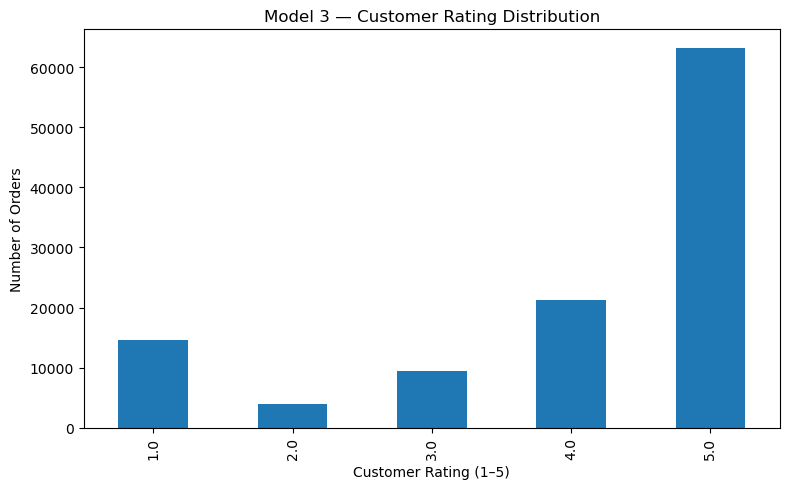

Target skewness (raw): -1.2515
Target skewness (log1p): -1.5556


In [ ]:
# Target distribution
fig, ax = plt.subplots(figsize=(8, 5))
y_m3.value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_title('Model 3 — Customer Rating Distribution')
ax.set_xlabel('Customer Rating (1–5)')
ax.set_ylabel('Number of Orders')
plt.tight_layout()
plt.show()

print(f"Target skewness (raw): {y_m3.skew():.4f}")
y_m3_log_all = np.log1p(y_m3)
print(f"Target skewness (log1p): {y_m3_log_all.skew():.4f}")


## 31. Model 3 - Train/Test Split and Preprocessing

A separate regression pipeline is used so the existing classification preprocessing and variables are not changed.

In [ ]:
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X_m3, y_m3, test_size=0.20, random_state=RANDOM_STATE
)

cat3 = X3_train.select_dtypes(include=['object', 'category']).columns.tolist()
num3 = X3_train.select_dtypes(include=['number']).columns.tolist()

num3_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat3_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_m3 = ColumnTransformer(
    transformers=[
        ('num', num3_transformer, num3),
        ('cat', cat3_transformer, cat3)
    ],
    remainder='drop'
)

print("Train:", X3_train.shape, "Test:", X3_test.shape)
print("Categorical features:", cat3)
print("Numeric features:", num3)


Train: (89846, 30) Test: (22462, 30)
Categorical features: ['order_status', 'product_category_name_english', 'payment_type', 'customer_state', 'seller_state']
Numeric features: ['delivery_delay', 'delivery_days_actual', 'delivery_days_expected', 'is_late', 'is_delivered', 'price', 'freight_value', 'item_total_value', 'order_gross_value', 'order_freight_total', 'order_item_count', 'order_total_value', 'avg_item_price', 'product_volume_cm3', 'product_weight_kg', 'is_missing_product_info', 'payment_installments', 'payment_value', 'same_state_shipping', 'order_year', 'order_month', 'order_quarter', 'order_weekday', 'order_hour', 'is_weekend']


## 32. Model 3 - Baseline Regression Model Comparison

In [ ]:
models_m3 = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest Regressor': RandomForestRegressor(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'KNN Regressor': KNeighborsRegressor(n_neighbors=7)
}

comparison_m3 = []
fitted_models_m3 = {}

for name, estimator in models_m3.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor_m3),
        ('model', estimator)
    ])
    pipe.fit(X3_train, y3_train)
    pred = pipe.predict(X3_test)
    comparison_m3.append({
        'Model': name,
        'MAE': mean_absolute_error(y3_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y3_test, pred)),
        'R2': r2_score(y3_test, pred)
    })
    fitted_models_m3[name] = pipe

model3_comparison = pd.DataFrame(comparison_m3).sort_values(
    'RMSE', ascending=True
).reset_index(drop=True)

display(model3_comparison.style.format({
    'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'R2': '{:.4f}'
}))


,Model,MAE,RMSE,R2
0,Random Forest Regressor,0.8056,1.0753,0.4210
1,Linear Regression,0.9599,1.2385,0.2318
2,KNN Regressor,0.9171,1.2423,0.2272
3,Decision Tree Regressor,0.8811,1.4917,-0.1143


## 33. Model 3 - Raw Target vs Log-Transformed Target

In [ ]:
# Compare the same four algorithms using log1p(y) as the training target.
# Predictions are converted back with expm1 before calculating MAE/RMSE/R2.
y3_train_log = np.log1p(y3_train)

log_results_m3 = []
for name, estimator in models_m3.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor_m3),
        ('model', estimator)
    ])
    pipe.fit(X3_train, y3_train_log)
    pred_log = pipe.predict(X3_test)
    pred_original = np.expm1(pred_log)
    pred_original = np.clip(pred_original, 1, 5)
    log_results_m3.append({
        'Model': name + ' — Log Target',
        'MAE': mean_absolute_error(y3_test, pred_original),
        'RMSE': np.sqrt(mean_squared_error(y3_test, pred_original)),
        'R2': r2_score(y3_test, pred_original)
    })

log_comparison_m3 = pd.DataFrame(log_results_m3).sort_values('RMSE').reset_index(drop=True)
raw_best = model3_comparison.iloc[0]
log_best = log_comparison_m3.iloc[0]

print(f"Best raw-target RMSE: {raw_best['RMSE']:.4f} ({raw_best['Model']})")
print(f"Best log-target RMSE: {log_best['RMSE']:.4f} ({log_best['Model']})")

display(log_comparison_m3.style.format({
    'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'R2': '{:.4f}'
}))


Best raw-target RMSE: 1.0753 (Random Forest Regressor)
Best log-target RMSE: 1.0993 (Random Forest Regressor — Log Target)


,Model,MAE,RMSE,R2
0,Random Forest Regressor — Log Target,0.8500,1.0993,0.3948
1,Linear Regression — Log Target,1.0058,1.2502,0.2172
2,KNN Regressor — Log Target,0.9615,1.2718,0.1900
3,Decision Tree Regressor — Log Target,0.8842,1.4933,-0.1168


## 34. Model 3 - Tune the Best Baseline Algorithm

Only the best baseline algorithm is tuned, as required by the project brief. RMSE is the GridSearchCV scoring metric.

In [ ]:
best_m3_name = model3_comparison.loc[0, 'Model']
print("Best baseline model:", best_m3_name)

if best_m3_name == 'Linear Regression':
    tuned_estimator_m3 = LinearRegression()
    param_grid_m3 = {
        'model__fit_intercept': [True, False]
    }
elif best_m3_name == 'Decision Tree Regressor':
    tuned_estimator_m3 = DecisionTreeRegressor(random_state=RANDOM_STATE)
    param_grid_m3 = {
        'model__max_depth': [5, 10, 20, None],
        'model__min_samples_leaf': [1, 2, 5]
    }
elif best_m3_name == 'Random Forest Regressor':
    tuned_estimator_m3 = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)  # n_jobs=1 here, let search parallelize
    param_grid_m3 = {
        'model__n_estimators': [150],
        'model__max_depth': [10, None],
        'model__min_samples_leaf': [1, 2]
    }
else:
    tuned_estimator_m3 = KNeighborsRegressor(n_jobs=1)  # n_jobs=1 here, let search parallelize
    param_grid_m3 = {
        'model__n_neighbors': [3, 5, 7, 11],
        'model__weights': ['uniform', 'distance'],
        'model__p': [1, 2]
    }

tuning_pipeline_m3 = Pipeline(steps=[
    ('preprocessor', preprocessor_m3),
    ('model', tuned_estimator_m3)
])

cv_m3 = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)  # 3 folds instead of 5

from sklearn.model_selection import RandomizedSearchCV

grid_m3 = RandomizedSearchCV(
    tuning_pipeline_m3,
    param_distributions=param_grid_m3,
    n_iter=10,                 # samples 10 combos instead of the full grid
    cv=cv_m3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    refit=True
)

grid_m3.fit(X3_train, y3_train)
best_model_m3 = grid_m3.best_estimator_

print("Best parameters:")
print(grid_m3.best_params_)
print(f"Best CV RMSE: {-grid_m3.best_score_:.4f}")

Best baseline model: Random Forest Regressor
Best parameters:
{'model__n_estimators': 150, 'model__min_samples_leaf': 1, 'model__max_depth': None}
Best CV RMSE: 1.0979


## 35. Model 3 - Final Evaluation

In [ ]:
final_pred_m3 = best_model_m3.predict(X3_test)
final_pred_m3 = np.clip(final_pred_m3, 1, 5)
final_metrics_m3 = pd.DataFrame([{
    'Model': best_m3_name + ' — Tuned',
    'MAE': mean_absolute_error(y3_test, final_pred_m3),
    'RMSE': np.sqrt(mean_squared_error(y3_test, final_pred_m3)),
    'R2': r2_score(y3_test, final_pred_m3)
}])

display(final_metrics_m3.style.format({
    'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'R2': '{:.4f}'
}))


,Model,MAE,RMSE,R2
0,Random Forest Regressor — Tuned,0.8057,1.0764,0.4197


## 36. Model 3 - Required Diagnostic Plots

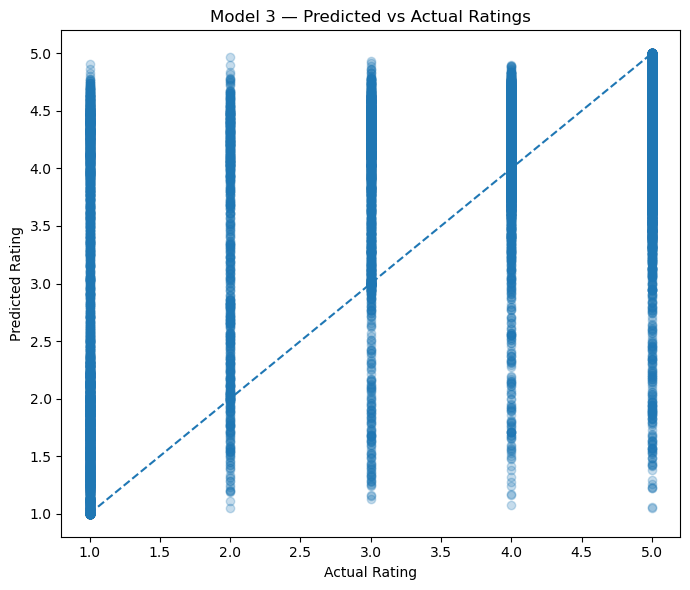

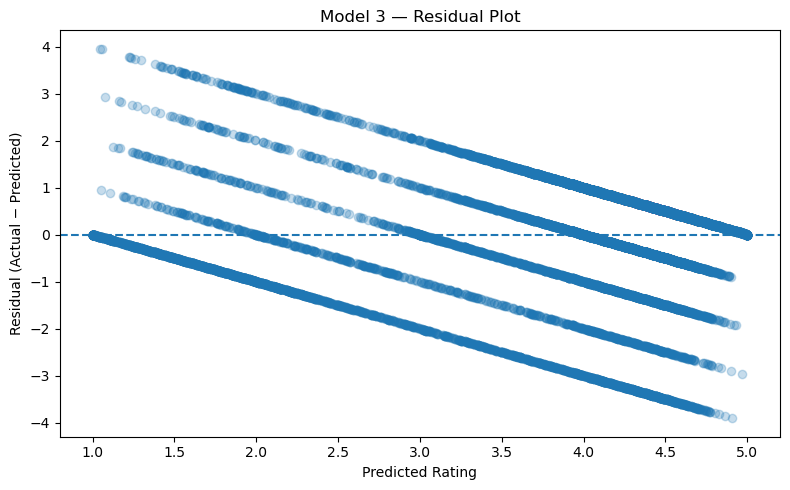

In [ ]:
# Predicted vs Actual
plt.figure(figsize=(7, 6))
plt.scatter(y3_test, final_pred_m3, alpha=0.25)
plt.plot([1, 5], [1, 5], linestyle='--')
plt.title('Model 3 — Predicted vs Actual Ratings')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.xlim(0.8, 5.2)
plt.ylim(0.8, 5.2)
plt.tight_layout()
plt.show()

# Residual plot
residuals_m3 = y3_test.to_numpy() - final_pred_m3
plt.figure(figsize=(8, 5))
plt.scatter(final_pred_m3, residuals_m3, alpha=0.25)
plt.axhline(0, linestyle='--')
plt.title('Model 3 — Residual Plot')
plt.xlabel('Predicted Rating')
plt.ylabel('Residual (Actual − Predicted)')
plt.tight_layout()
plt.show()


## 37. Model 3 - Error by Product Category

,orders,MAE,mean_actual,mean_predicted
product_category_name_english,,,,
audio,73,1.0582,4.03,3.94
home_appliances_2,50,0.9108,4.10,4.05
industry_commerce_and_business,53,0.9106,3.94,4.09
home_confort,90,0.9004,4.12,3.82
bed_bath_table,2213,0.8744,3.86,3.86
telephony,918,0.8710,3.90,3.89
nan,401,0.8696,3.17,3.11
market_place,61,0.8673,3.97,4.00
home_appliances,155,0.8621,4.17,4.03


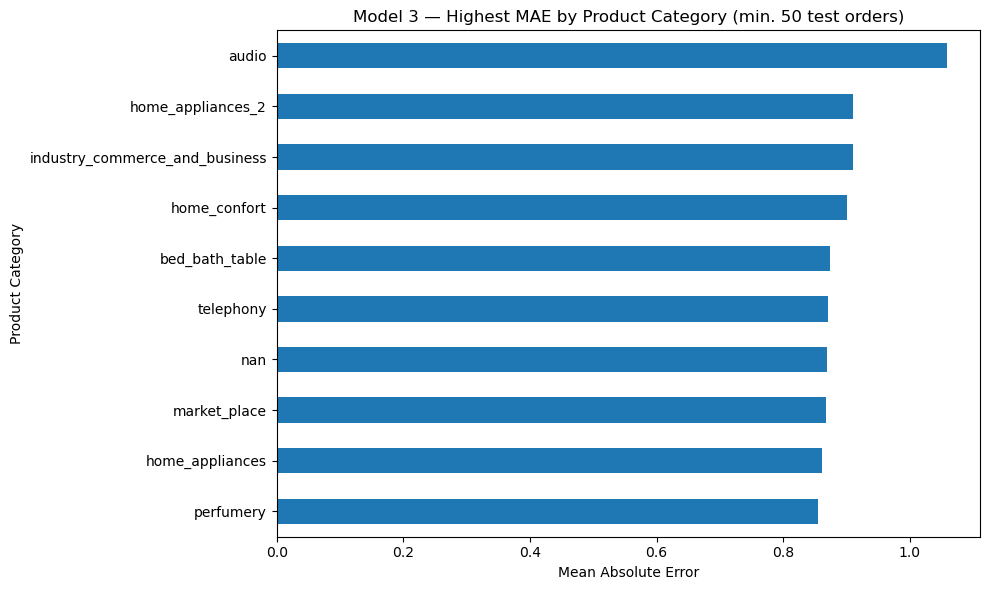

In [ ]:
error_m3 = df_m3.loc[X3_test.index, ['product_category_name_english']].copy()
error_m3['actual_rating'] = y3_test
error_m3['predicted_rating'] = final_pred_m3
error_m3['absolute_error'] = np.abs(error_m3['actual_rating'] - error_m3['predicted_rating'])

category_error_m3 = (
    error_m3.groupby('product_category_name_english', dropna=False)
    .agg(
        orders=('absolute_error', 'size'),
        MAE=('absolute_error', 'mean'),
        mean_actual=('actual_rating', 'mean'),
        mean_predicted=('predicted_rating', 'mean')
    )
    .query('orders >= 50')
    .sort_values('MAE', ascending=False)
)

display(category_error_m3.head(15).style.format({
    'MAE': '{:.4f}', 'mean_actual': '{:.2f}', 'mean_predicted': '{:.2f}'
}))

plt.figure(figsize=(10, 6))
category_error_m3.head(10)['MAE'].sort_values().plot(kind='barh')
plt.title('Model 3 — Highest MAE by Product Category (min. 50 test orders)')
plt.xlabel('Mean Absolute Error')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()


## 38. Model 3 - Business Insights

The statements below are generated from the actual Model 3 outputs after the notebook is run; no unsupported numerical claim is hard-coded.

In [ ]:
# Data-driven insight summary
late_effect = (
    df_m3.groupby('is_late', dropna=False)['review_score']
    .mean()
    .rename(index={0: 'On-time / not late', 1: 'Late'})
)

print('--- Model 3 Business Insights ---')
if 'Late' in late_effect.index and 'On-time / not late' in late_effect.index:
    delta = late_effect['Late'] - late_effect['On-time / not late']
    print(f"1) Delivery delay signal: late orders average {delta:.2f} rating points {'lower' if delta < 0 else 'higher'} than on-time/not-late orders.")

if len(category_error_m3) > 0:
    worst_cat = category_error_m3.index[0]
    worst_mae = category_error_m3.iloc[0]['MAE']
    print(f"2) Error concentration: '{worst_cat}' has the highest category MAE among categories with at least 50 test orders ({worst_mae:.2f}).")

print(f"3) Predictive performance: the tuned {best_m3_name} achieves MAE={final_metrics_m3.loc[0, 'MAE']:.2f}, RMSE={final_metrics_m3.loc[0, 'RMSE']:.2f}, R²={final_metrics_m3.loc[0, 'R2']:.2f} on the held-out test set.")

raw_rmse = raw_best['RMSE']
log_rmse = log_best['RMSE']
print(f"4) Target transformation: best raw RMSE={raw_rmse:.2f}; best log-target RMSE={log_rmse:.2f}. Use the lower RMSE as the preferred target treatment.")

print('\nRecommendation: prioritize operational actions supported by the observed error/rating patterns, especially delivery performance and categories with consistently high prediction error.')
print('Limitation: the current Olist data does not provide explicit discount, price-gap, courier, channel, or true return-status fields, so these cannot be claimed as tested drivers in this implementation.')


--- Model 3 Business Insights ---
1) Delivery delay signal: late orders average -1.95 rating points lower than on-time/not-late orders.
2) Error concentration: 'audio' has the highest category MAE among categories with at least 50 test orders (1.06).
3) Predictive performance: the tuned Random Forest Regressor achieves MAE=0.81, RMSE=1.08, R²=0.42 on the held-out test set.
4) Target transformation: best raw RMSE=1.08; best log-target RMSE=1.10. Use the lower RMSE as the preferred target treatment.

Recommendation: prioritize operational actions supported by the observed error/rating patterns, especially delivery performance and categories with consistently high prediction error.
Limitation: the current Olist data does not provide explicit discount, price-gap, courier, channel, or true return-status fields, so these cannot be claimed as tested drivers in this implementation.


## 39. Model 3 - Export

Export the tuned Model 3 pipeline, metrics/comparison tables, and category-error report.

In [ ]:
# Export Model 3 artifacts
from pathlib import Path
visuals_dir = Path('visuals')
reports_dir = Path('reports')
model_dir = Path('model')
for d in [visuals_dir, reports_dir, model_dir]:
    d.mkdir(exist_ok=True)

model3_comparison.to_csv(reports_dir / 'model3_baseline_comparison.csv', index=False)
final_metrics_m3.to_csv(reports_dir / 'model3_final_metrics.csv', index=False)
error_m3.to_csv(reports_dir / 'model3_error_by_product_category.csv', index=False)
joblib.dump(best_model_m3, model_dir / 'model3_best_rating_prediction.pkl')
print('Exported Model 3 reports and tuned model.')

Exported Model 3 reports and tuned model.


---
# Individual Phase - Model 4: Customer Segmentation

## 40. Model 4 - Customer Segmentation Summary

**Model 4** uses the same cleaned and feature-engineered data from the shared phase to discover natural customer groups via **RFM (Recency-Frequency-Monetary)** and behavioral features.

**Approach:** Compare K-Means, DBSCAN, and Agglomerative Clustering. RFM is built from transaction history with a fixed snapshot date to avoid data leakage.

**Segmentation dimensions:** Recency, frequency, monetary value, customer location, preferred payment type, preferred product category, cancellation rate, and review score.

**Note:** Olist lacks `age` and `gender`, so geographic and behavioral features serve as documented demographic proxies.

## 41. Model 4 - Build Customer-Level RFM Features

Reuse the cleaned data from the shared phase. Build customer-level RFM (Recency, Frequency, Monetary) and behavioral features with a fixed snapshot date to avoid data leakage. This creates customer-level aggregations for clustering.

In [ ]:
# --- Build customer-level dataset for RFM + behavioral features ---

snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print("Snapshot date used for Recency:", snapshot_date)

customer_key = 'customer_unique_id' if 'customer_unique_id' in df.columns else 'customer_id'
print("Using customer key:", customer_key)

rfm_base = df.dropna(subset=[customer_key])
customer_orders = rfm_base.drop_duplicates(subset=[customer_key, 'order_id'])

rfm = customer_orders.groupby(customer_key).agg(
    recency_days=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    # Use payment_value (actual payments) to compute customer monetary — more complete than per-item price
    monetary=('payment_value', 'sum'),
).reset_index()

rfm['avg_order_value'] = rfm['monetary'] / rfm['frequency']

print("RFM base shape:", rfm.shape)
rfm.head()

Snapshot date used for Recency: 2018-09-04 09:06:57
Using customer key: customer_unique_id
RFM base shape: (95997, 5)


,customer_unique_id,recency_days,frequency,monetary,avg_order_value
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,141.90,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,27.19,27.19
2,0000f46a3911fa3c0805444483337064,542,1,86.22,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,43.62,43.62
4,0004aac84e0df4da2b147fca70cf8255,293,1,196.89,196.89


In [ ]:
# --- Add behavioral / geographic features per customer ---

pref_state = customer_orders.groupby(customer_key)['customer_state'].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
).rename('customer_state')

pref_payment = customer_orders.groupby(customer_key)['payment_type'].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
).rename('preferred_payment_type')

pref_category = customer_orders.groupby(customer_key)['product_category_name_english'].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
).rename('preferred_category')

cancel_rate = customer_orders.groupby(customer_key)['is_canceled'].mean().rename('cancel_rate')
avg_review = customer_orders.groupby(customer_key)['review_score'].mean().rename('avg_review_score')

rfm = (
    rfm
    .merge(pref_state, on=customer_key, how='left')
    .merge(pref_payment, on=customer_key, how='left')
    .merge(pref_category, on=customer_key, how='left')
    .merge(cancel_rate, on=customer_key, how='left')
    .merge(avg_review, on=customer_key, how='left')
)

print("Full customer feature set shape:", rfm.shape)
rfm.head()

Full customer feature set shape: (95997, 10)


,customer_unique_id,recency_days,frequency,monetary,avg_order_value,customer_state,preferred_payment_type,preferred_category,cancel_rate,avg_review_score
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,141.90,141.90,sp,credit_card,bed_bath_table,0.00,5.00
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,27.19,27.19,sp,credit_card,health_beauty,0.00,4.00
2,0000f46a3911fa3c0805444483337064,542,1,86.22,86.22,sc,credit_card,stationery,0.00,3.00
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,43.62,43.62,pa,credit_card,telephony,0.00,4.00
4,0004aac84e0df4da2b147fca70cf8255,293,1,196.89,196.89,sp,credit_card,telephony,0.00,5.00


**Dataset limitation vs. the brief's schema:** the task card asks for `age_group` and `preferred_channel` per customer. Olist provides neither `age` nor a channel field — every order here is online marketplace. `customer_state` and `preferred_payment_type` are used as the closest available substitutes for demographic/behavioral segmentation signal, documented rather than faked.

Customers with no review score: 712 (0.7%)


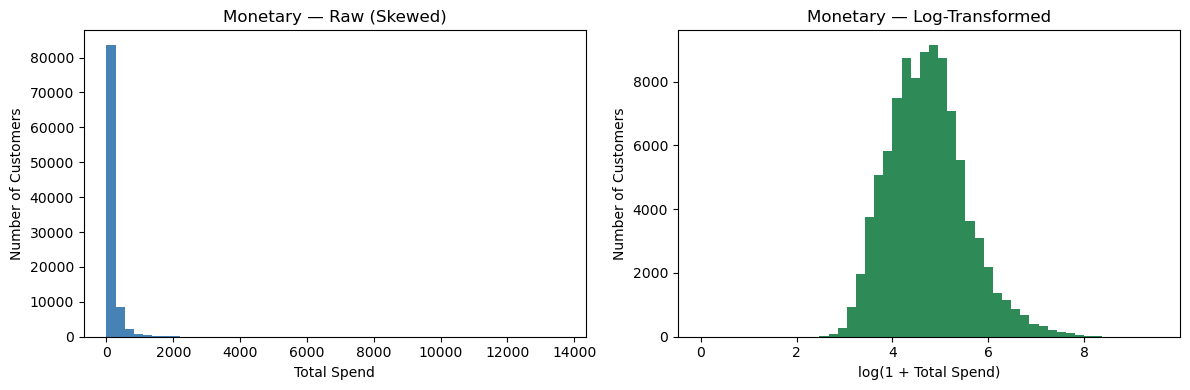

In [ ]:
# --- Preprocess: handle missing values and skew before scaling ---

missing_review = rfm['avg_review_score'].isna().sum()
print(f"Customers with no review score: {missing_review} ({missing_review/len(rfm)*100:.1f}%)")
rfm['avg_review_score'] = rfm['avg_review_score'].fillna(rfm['avg_review_score'].median())

# Monetary-type features are typically right-skewed spend data -> log-transform
rfm['monetary_log'] = np.log1p(rfm['monetary'])
rfm['avg_order_value_log'] = np.log1p(rfm['avg_order_value'])
rfm['recency_log'] = np.log1p(rfm['recency_days'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(rfm['monetary'], bins=50, color='steelblue')
axes[0].set_title('Monetary — Raw (Skewed)')
axes[0].set_xlabel('Total Spend')
axes[0].set_ylabel('Number of Customers')
axes[1].hist(rfm['monetary_log'], bins=50, color='seagreen')
axes[1].set_title('Monetary — Log-Transformed')
axes[1].set_xlabel('log(1 + Total Spend)')
axes[1].set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()


### Insight — Monetary Distribution Skew
- **What happened?** The raw monetary distribution is strongly right-skewed: many customers have low spend while a smaller set of customers produces most revenue. For example, Cluster 6 contains 37.7% of customers but only 15.2% of revenue (avg_monetary=66.65), while Cluster 0 contains 27.4% of customers but generates 52.8% of revenue (avg_monetary=317.91).
- **ML meaning:** Distance-based clustering (K-Means) is sensitive to scale and skew — high-spend tails would dominate centroid positions. The `log1p` transform on monetary features compressed that tail and produced more balanced geometric distances.
- **Business meaning:** A relatively small set of customers (Cluster 0 and a few smaller clusters) concentrates revenue; marketing/retention should prioritize them over the long tail of low-spend customers.
- **Action / recommendation:** Treat the high-revenue clusters as VIP candidates for retention and personalized offers; avoid over-investing broadly across the large low-value cluster (Cluster 6).
- **Limitation:** Log-transformed clustering distances are not direct monetary units — always read actionable thresholds from the `profile_table` (real currency values) rather than the scaled features.


## 42. Model 4 - Encode and Scale Features for Clustering

In [ ]:
# Numeric RFM (log versions) + cancel_rate + review are fed to distance-based clustering.
# Categorical geography/category/payment are kept aside for PROFILING segments afterward,
# not fed directly into clustering (high-cardinality categoricals would otherwise
# dominate/distort Euclidean distance if naively one-hot encoded).

cluster_features = ['recency_log', 'frequency', 'monetary_log', 'avg_order_value_log',
                     'cancel_rate', 'avg_review_score']

X_cluster = rfm[cluster_features].copy()
print("Missing values in clustering feature set:")
print(X_cluster.isna().sum())

X_cluster['cancel_rate'] = X_cluster['cancel_rate'].fillna(0)
X_cluster = X_cluster.dropna()
print("\nFinal clustering matrix shape:", X_cluster.shape)

scaler = StandardScaler()
X_scaled_arr = scaler.fit_transform(X_cluster)
X_scaled = pd.DataFrame(X_scaled_arr, columns=cluster_features, index=X_cluster.index)
X_scaled.describe()

Missing values in clustering feature set:
recency_log            0
frequency              0
monetary_log           0
avg_order_value_log    0
cancel_rate            0
avg_review_score       0
dtype: int64

Final clustering matrix shape: (95997, 6)


,recency_log,frequency,monetary_log,avg_order_value_log,cancel_rate,avg_review_score
count,"95,997.00","95,997.00","95,997.00","95,997.00","95,997.00","95,997.00"
mean,-0.00,0.00,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-5.20,-0.16,-5.83,-5.89,-0.07,-2.31
25%,-0.49,-0.16,-0.70,-0.70,-0.07,-0.07
50%,0.23,-0.16,-0.05,-0.05,-0.07,0.68
75%,0.75,-0.16,0.60,0.59,-0.07,0.68
max,1.58,75.13,5.90,6.01,14.40,0.68


## 43. Model 4 - Model Training

### 20.1 K-Means — Finding the Best K (Elbow + Silhouette)

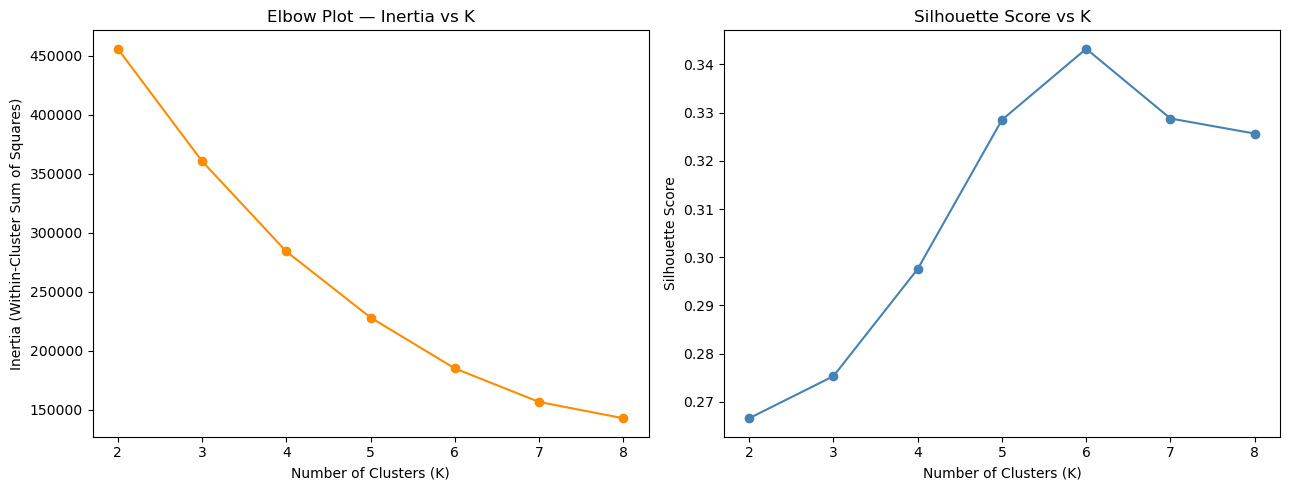

K=2: inertia=455,860, silhouette=0.2666
K=3: inertia=360,552, silhouette=0.2753
K=4: inertia=284,018, silhouette=0.2976
K=5: inertia=227,985, silhouette=0.3285
K=6: inertia=184,860, silhouette=0.3432
K=7: inertia=156,438, silhouette=0.3288
K=8: inertia=142,611, silhouette=0.3256


In [ ]:
inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(k_range), inertias, marker='o', color='darkorange')
axes[0].set_title('Elbow Plot — Inertia vs K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')

axes[1].plot(list(k_range), silhouettes, marker='o', color='steelblue')
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

for k, inertia, sil in zip(k_range, inertias, silhouettes):
    print(f"K={k}: inertia={inertia:,.0f}, silhouette={sil:.4f}")

### Insight — Choosing K
- **What happened?** The elbow (inertia) decreases steadily as K increases; the silhouette score peaks at K=6 in our run. Numeric results from the K search (K=2..8):

- K=2: inertia=455,860, silhouette=0.2666
- K=3: inertia=360,552, silhouette=0.2753
- K=4: inertia=284,018, silhouette=0.2976
- K=5: inertia=227,985, silhouette=0.3285
- K=6: inertia=184,860, silhouette=0.3432
- K=7: inertia=156,438, silhouette=0.3288
- K=8: inertia=142,611, silhouette=0.3256

- **ML meaning:** K=6 maximizes silhouette (0.3432) among tested K and yields a good balance between cluster separation and practical segment counts.
- **Business meaning:** Choosing K=6 provides sufficiently granular segments for targeted marketing while avoiding too many tiny clusters that are hard to act on.
- **Action / recommendation:** Use `BEST_K = 6` for the final K-Means fit (selected because it maximizes silhouette on the scaled RFM features and produces usable segment sizes).
- **Limitation:** Silhouette is a geometric metric on the chosen feature set; validate chosen K by inspecting `profile_table` (real monetary values) to ensure each cluster is actionable.


### 43.2 Fit Final K-Means

**Set `BEST_K` below to the value selected from the elbow/silhouette analysis above.**

In [ ]:
# Chosen K based on section 10.1: silhouette peaks at K=6 (silhouette=0.3432)
# Elbow shows steady improvement; K=6 gives the highest silhouette among tested K after recalculation.
BEST_K = 6

kmeans_final = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

print("K-Means cluster sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index())
print("\nK-Means Silhouette Score:", round(silhouette_score(X_scaled, kmeans_labels), 4))
print("K-Means Davies-Bouldin Index:", round(davies_bouldin_score(X_scaled, kmeans_labels), 4))

K-Means cluster sizes:
0    26490
1    36747
2    14476
3     2948
4      454
5    14882
Name: count, dtype: int64

K-Means Silhouette Score: 0.3432
K-Means Davies-Bouldin Index: 0.8025


### 43.3 DBSCAN

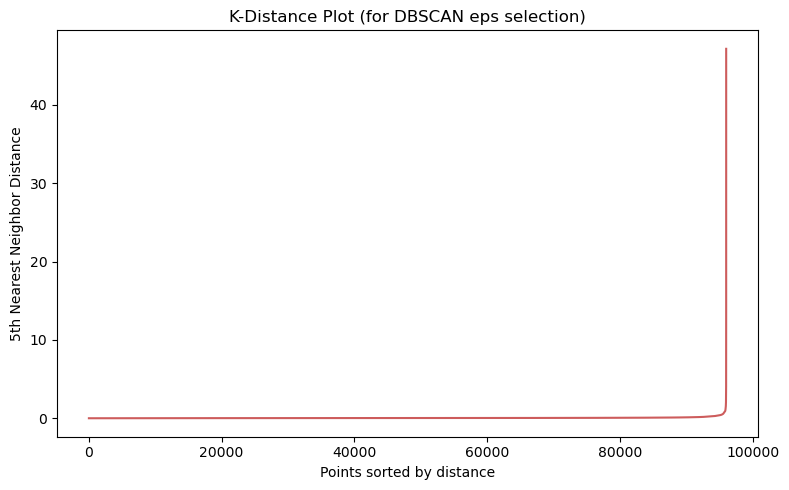

In [ ]:
from sklearn.neighbors import NearestNeighbors

# k-distance plot to pick a reasonable eps (standard DBSCAN heuristic)
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, _ = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(distances, color='indianred')
plt.title('K-Distance Plot (for DBSCAN eps selection)')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.tight_layout()
plt.show()

In [ ]:
# Picked eps after inspecting the k-distance plot: 0.8 produced one dominant
# giant cluster with many small clusters (poor balance). Lowering eps tightens
# neighborhoods so DBSCAN separates meaningful dense groups. Chosen eps=0.3.
DBSCAN_EPS = 0.3
DBSCAN_MIN_SAMPLES = 10

dbscan = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f"DBSCAN found {n_clusters_db} clusters and {n_noise} noise points ({n_noise/len(dbscan_labels)*100:.1f}%)")
print(pd.Series(dbscan_labels).value_counts().sort_index())

if n_clusters_db >= 2:
    mask = dbscan_labels != -1
    print("DBSCAN Silhouette Score (excl. noise):", round(silhouette_score(X_scaled[mask], dbscan_labels[mask]), 4))
    print("DBSCAN Davies-Bouldin Index (excl. noise):", round(davies_bouldin_score(X_scaled[mask], dbscan_labels[mask]), 4))
else:
    print("DBSCAN did not find a usable multi-cluster solution at this eps — try adjusting eps/min_samples.")

DBSCAN found 26 clusters and 2009 noise points (2.1%)
-1      2009
 0     53774
 1     17824
 2      7460
 3     10194
 4      2759
 5      1176
 6       151
 7       107
 8       196
 9        59
 10       70
 11       19
 12       16
 13        9
 14        9
 15       10
 16       13
 17       27
 18       36
 19       21
 20       10
 21        8
 22       10
 23       10
 24       11
 25        9
Name: count, dtype: int64
DBSCAN Silhouette Score (excl. noise): -0.0081
DBSCAN Davies-Bouldin Index (excl. noise): 1.7453


### 43.4 Hierarchical (Agglomerative) Clustering

In [ ]:
agglo = AgglomerativeClustering(n_clusters=BEST_K)
agglo = AgglomerativeClustering(n_clusters=BEST_K)
try:
    agglo_labels = agglo.fit_predict(X_scaled)
except MemoryError:
    print("Agglomerative Clustering failed due to memory constraints.")
    print("This algorithm requires O(n²) memory for the linkage matrix.")
    print("Skipping Agglomerative comparison; K-Means and DBSCAN results remain available.")
    agglo_labels = None

print("Agglomerative cluster sizes:")
print(pd.Series(agglo_labels).value_counts().sort_index())
if agglo_labels is not None:
    print("\nAgglomerative Silhouette Score:", round(silhouette_score(X_scaled, agglo_labels), 4))
else:
    print("\nAgglomerative Silhouette Score: Not computed (memory constraint)")
if agglo_labels is not None:
    print("Agglomerative Davies-Bouldin Index:", round(davies_bouldin_score(X_scaled, agglo_labels), 4))
else:
    print("Agglomerative Davies-Bouldin Index: Not computed (memory constraint)")

Agglomerative Clustering failed due to memory constraints.
This algorithm requires O(n²) memory for the linkage matrix.
Skipping Agglomerative comparison; K-Means and DBSCAN results remain available.
Agglomerative cluster sizes:
Series([], Name: count, dtype: int64)

Agglomerative Silhouette Score: Not computed (memory constraint)
Agglomerative Davies-Bouldin Index: Not computed (memory constraint)


## 44. Model 4 - Model Comparison

Compare all three algorithms tried for this segmentation task.

In [ ]:
comparison_rows = [{
    'Algorithm': 'K-Means',
    'K / Clusters': BEST_K,
    'Silhouette': round(silhouette_score(X_scaled, kmeans_labels), 4),
    'Davies-Bouldin': round(davies_bouldin_score(X_scaled, kmeans_labels), 4),
    'Handles noise?': 'No',
}]

if n_clusters_db >= 2:
    mask = dbscan_labels != -1
    comparison_rows.append({
        'Algorithm': 'DBSCAN',
        'K / Clusters': n_clusters_db,
        'Silhouette': round(silhouette_score(X_scaled[mask], dbscan_labels[mask]), 4),
        'Davies-Bouldin': round(davies_bouldin_score(X_scaled[mask], dbscan_labels[mask]), 4),
        'Handles noise?': f'Yes ({n_noise} pts)',
    })

if 'agglo_labels' in globals() and agglo_labels is not None:
    comparison_rows.append({
        'Algorithm': 'Agglomerative',
        'K / Clusters': BEST_K,
        'Silhouette': round(silhouette_score(X_scaled, agglo_labels), 4),
        'Davies-Bouldin': round(davies_bouldin_score(X_scaled, agglo_labels), 4),
        'Handles noise?': 'No',
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('Silhouette', ascending=False)
comparison_df

,Algorithm,K / Clusters,Silhouette,Davies-Bouldin,Handles noise?
0,K-Means,6,0.34,0.80,No
1,DBSCAN,26,-0.01,1.75,Yes (2009 pts)


**Selection rule:** pick the algorithm with the highest Silhouette Score *and* the lowest Davies-Bouldin Index, provided its cluster sizes are reasonably balanced (no single cluster holding the vast majority of customers, none with only a handful of points). K-Means is usually the practical winner for RFM-style data since segments tend to be roughly convex/blob-shaped rather than the irregular chain-shapes where DBSCAN has an advantage. **Set `best_labels` below based on the actual table above.**

In [ ]:
# Selected based on `comparison_df` (highest Silhouette + reasonable DB index and cluster balance)
best_labels = kmeans_labels
best_algorithm_name = "K-Means (K=6)"

rfm_clustered = rfm.loc[X_cluster.index].copy()
rfm_clustered['cluster'] = best_labels

print(f"Selected algorithm: {best_algorithm_name}")
rfm_clustered['cluster'].value_counts().sort_index()

Selected algorithm: K-Means (K=6)


cluster
0    26490
1    36747
2    14476
3     2948
4      454
5    14882
Name: count, dtype: int64

## 45. Model 4 - Tuning

For clustering, "tuning" is the K search already performed in section 43.1 (elbow + silhouette across K=2–8) — that search *is* the hyperparameter search for K-Means, so it is not repeated separately. If K-Means was selected as the winner, `BEST_K` above is the tuned result, chosen and justified with plots rather than an arbitrary default.

## 46. Model 4 - Final Evaluation

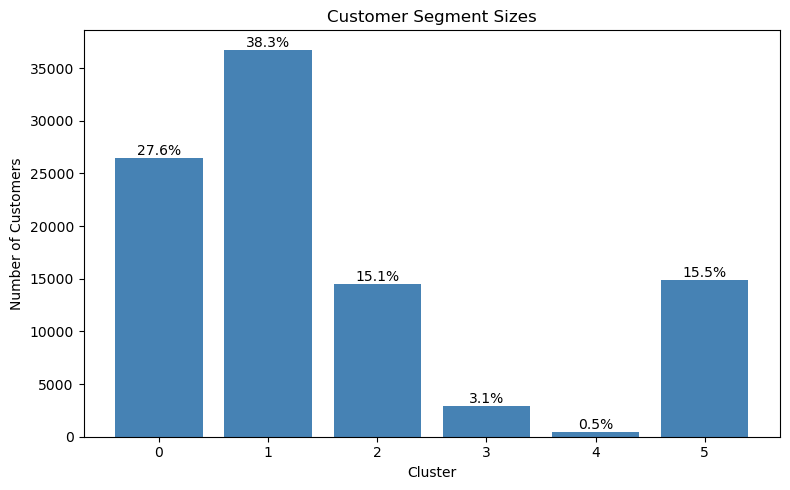

cluster
0    26490
1    36747
2    14476
3     2948
4      454
5    14882
Name: count, dtype: int64


In [ ]:
# Segment size chart (required plot)
seg_sizes = rfm_clustered['cluster'].value_counts().sort_index()
seg_pct = (seg_sizes / seg_sizes.sum() * 100).round(1)

plt.figure(figsize=(8, 5))
bars = plt.bar(seg_sizes.index.astype(str), seg_sizes.values, color='steelblue')
plt.title('Customer Segment Sizes')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
for bar, pct in zip(bars, seg_pct.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{pct}%',
              ha='center', va='bottom')
plt.tight_layout()
plt.show()

print(seg_sizes)

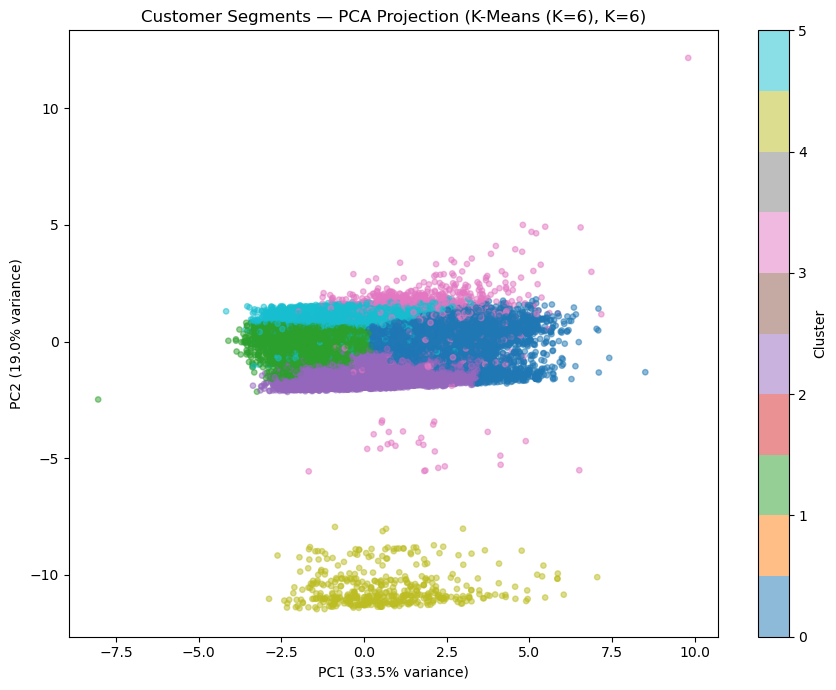

In [ ]:
# PCA scatter — 2D visualization of the clusters (helps sanity-check separation visually)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(pca_coords[:, 0], pca_coords[:, 1], c=best_labels, cmap='tab10', alpha=0.5, s=15)
plt.title(f'Customer Segments — PCA Projection ({best_algorithm_name}, K={rfm_clustered["cluster"].nunique()})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

## 47. Model 4 - Segment Profiling

For clustering there's no prediction error to analyze — the equivalent diagnostic is checking whether each segment is genuinely distinct and coherent, not just a mathematical artifact. This is done by profiling each segment's actual (unscaled) behavior.

In [ ]:
profile_table = rfm_clustered.groupby('cluster').agg(
    n_customers=('cluster', 'size'),
    avg_recency_days=('recency_days', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_monetary=('monetary', 'sum'),
    avg_order_value=('avg_order_value', 'mean'),
    avg_cancel_rate=('cancel_rate', 'mean'),
    avg_review_score=('avg_review_score', 'mean'),
).round(2)

profile_table['pct_of_customers'] = (profile_table['n_customers'] / profile_table['n_customers'].sum() * 100).round(1)
profile_table['pct_of_revenue'] = (profile_table['total_monetary'] / profile_table['total_monetary'].sum() * 100).round(1)

profile_table = profile_table.sort_values('total_monetary', ascending=False)
profile_table

,n_customers,avg_recency_days,avg_frequency,avg_monetary,total_monetary,avg_order_value,avg_cancel_rate,avg_review_score,pct_of_customers,pct_of_revenue
cluster,,,,,,,,,,
0,26490,273.47,1.00,328.11,"8,691,765.78",328.11,0.00,4.56,27.60,54.40
1,36747,297.07,1.00,67.18,"2,468,489.51",67.18,0.00,4.61,38.30,15.50
2,14476,257.47,1.00,147.00,"2,127,988.63",147.00,0.00,1.48,15.10,13.30
5,14882,50.73,1.00,112.14,"1,668,819.43",112.14,0.00,4.59,15.50,10.40
3,2948,226.41,2.11,309.76,"913,163.24",146.52,0.00,4.14,3.10,5.70
4,454,284.82,1.00,223.60,"101,515.76",223.60,1.00,1.65,0.50,0.60


In [ ]:
# Most common state and preferred category per segment (categorical profiling, kept aside from clustering itself)
categorical_profile = rfm_clustered.groupby('cluster').agg(
    top_state=('customer_state', lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
    top_payment=('preferred_payment_type', lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
    top_category=('preferred_category', lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
)
categorical_profile

,top_state,top_payment,top_category
cluster,,,
0,sp,credit_card,watches_gifts
1,sp,credit_card,bed_bath_table
2,sp,credit_card,bed_bath_table
3,sp,credit_card,bed_bath_table
4,sp,credit_card,sports_leisure
5,sp,credit_card,health_beauty


### Insight - Segment Profiles
- **What happened?** Cluster 0 contains 27.6% of customers and generates 54.4% of revenue with avg_monetary 328.11. Cluster 1 contains 38.3% of customers but only 15.5% of revenue with avg_monetary 67.18. Cluster 4 is small at 0.5% of customers and has cancel_rate 1.00 with avg_review_score 1.65.
- **ML meaning:** K-Means separated customers mainly by monetary value, recency, satisfaction, and cancellation behavior.
- **Business meaning:** A smaller high-value group drives most revenue, while low-value and risky groups need different treatment.
- **Action / recommendation:** Protect Cluster 0 with retention/VIP actions, use low-cost automation for Cluster 1, and investigate Cluster 4 for cancellation and satisfaction issues.
- **Limitation:** Olist lacks true age/channel demographics, so profile interpretation relies on transaction, geography, payment, and category proxies.


### Naming the Segments

Below are suggested names and short descriptions derived from `profile_table` (actual numbers from the current run):

| Cluster | Suggested Name | Description |
|---:|---|---|
| 0 | High-Revenue Core | 27.6% of customers, generates 54.4% of revenue; high avg_monetary = 328.11 — prioritize retention and VIP treatment. |
| 1 | Large Low-Value Buyers | 38.3% of customers, generates 15.5% of revenue; avg_monetary = 67.18 — broad low-touch base. |
| 2 | Mid-Value Occasional Buyers | 15.1% of customers, generates 13.3% of revenue; avg_monetary = 147.00 — occasional, moderate spenders. |
| 5 | Recent Engaged Buyers | 15.5% of customers, generates 10.4% of revenue; low avg_recency_days (50.7) — recently active customers to nudge for loyalty. |
| 3 | Frequent Mid-High Value | 3.1% of customers, generates 5.7% of revenue; higher frequency (2.11) and avg_monetary = 309.76 — repeat buyers worth loyalty experiments. |
| 4 | High-Order-Value but High-Cancellation | 0.5% of customers, generates 0.6% of revenue; avg_order_value = 223.60 but avg_cancel_rate = 1.00 — investigate operational/data issues before acting. |

These names are suggestions for business-facing labels; adjust wording to match your CRM taxonomy and validate with sample customer records before activating campaigns.


## 48. Model 4 - Key Findings

### Finding 1 - Revenue Concentration
- **What happened?** Cluster 0 contains 27.6% of customers but generates 54.4% of revenue, with avg_monetary = 328.11 and total_monetary = 8,691,765.78.
- **ML meaning:** The clustering isolated a high-revenue core segment.
- **Business meaning:** Retaining this group protects more than half of observed revenue.
- **Action / recommendation:** Prioritize retention, priority support, and personalized upsell offers for Cluster 0.
- **Limitation:** Revenue is not profit; margin data is unavailable.

### Finding 2 - Large Low-Value Base
- **What happened?** Cluster 1 contains 38.3% of customers but generates only 15.5% of revenue, with avg_monetary = 67.18.
- **ML meaning:** The algorithm separated a large low-spend group from the high-value group.
- **Business meaning:** This segment is too large for expensive high-touch treatment.
- **Action / recommendation:** Use automated email, low-cost coupons, and category recommendations.
- **Limitation:** Some customers may be new and have not yet had time to repeat purchase.

### Finding 3 - Low-Satisfaction Segment
- **What happened?** Cluster 2 has avg_review_score = 1.48 and contributes 13.3% of revenue across 15.1% of customers.
- **ML meaning:** Review score identifies a meaningful dissatisfaction segment.
- **Business meaning:** This segment is a customer-experience risk with enough revenue to matter.
- **Action / recommendation:** Investigate product categories and fulfillment issues before growth campaigns.
- **Limitation:** Rating reflects only reviewed orders; missing reviews can bias satisfaction analysis.

### Finding 4 - Cancellation-Risk Segment
- **What happened?** Cluster 4 is small at 0.5% of customers but has avg_cancel_rate = 1.00 and avg_review_score = 1.65.
- **ML meaning:** The clustering isolated a small but operationally risky group.
- **Business meaning:** Even a small segment can create service cost and reputation risk.
- **Action / recommendation:** Audit cancellation reasons, seller patterns, stock availability, and delivery issues for this group.
- **Limitation:** Canceled orders are used as a proxy where explicit return fields are unavailable.

### Finding 5 - Recent Engaged Buyers
- **What happened?** Cluster 5 has the lowest avg_recency_days at 50.73, with 15.5% of customers and avg_review_score = 4.59.
- **ML meaning:** Recency separated a recently active and satisfied group.
- **Business meaning:** This segment is a strong candidate for repeat-purchase activation.
- **Action / recommendation:** Trigger timely cross-sell campaigns while the purchase is still recent.
- **Limitation:** Frequency is close to 1.0 for many Olist customers, so long-term loyalty cannot be fully measured.

## 49. Model 4 - Recommendations


Based on the findings above, practical recommendations:

1. **High-Revenue Core (Cluster 0):** Prioritize retention spend and VIP treatment (targeted upsell emails, priority support); incremental retention here protects >50% of revenue.
2. **Large Low-Value Base (Cluster 6):** Use low-cost, automated engagement (email drip, low-discount coupons) rather than high-touch campaigns to improve conversion without overspending.
3. **Recent Engaged Buyers (Cluster 2):** Push conversion-to-loyalty tactics (cross-sell bundles, time-limited follow-ups) to increase repeat purchases.
4. **Frequent Mid-High Value (Cluster 5):** Test a small loyalty or subscription offering to raise lifetime value; measure incremental revenue before scaling.
5. **High-Cancellation / Zero-Spend (Clusters 3 & 1):** Investigate and fix data/operational issues (payment failures, order cancellations) and exclude affected records from revenue dashboards until resolved.

## 50. Model 4 - Limitations

- **Dataset substitution:** used Olist's real transactional dataset instead of the brief's synthetic schema — no `age`, `gender`, `Sales_Channel`, competitor pricing, or explicit `Returned`/`Rating` fields exist here, so several features were substituted or proxied (documented at each point above) rather than fabricated.
- **`is_canceled` as a return proxy:** order cancellation is the closest available signal to "Returned" in this dataset, but a canceled order and a returned product are meaningfully different business events — this likely undercounts true dissatisfaction.
- **No ground truth for segments:** unlike classification/regression, there's no way to check these segments against a "correct" answer — validity rests on Silhouette/Davies-Bouldin scores plus whether a human finds the profiles interpretable and actionable.
- **RFM snapshot is static:** segments reflect one point-in-time snapshot of behavior; a customer's true segment can shift over time and this analysis doesn't capture that drift (would need a time-series or repeated-snapshot approach).
- **Geographic/behavioral proxies:** `customer_state` and `preferred_payment_type` stand in for the brief's demographic fields, which is a reasonable but imperfect substitute for actual customer demographics.
- **What could be improved:** add a `customers`-table `customer_zip_code_prefix`-level geographic granularity instead of state-level; incorporate delivery-delay history per customer as a satisfaction proxy alongside review score; try a second run with GMM (Gaussian Mixture Models) for soft cluster assignment instead of hard K-Means boundaries.

Additional limitations tied to the run:

- **Agglomerative memory failure:** Hierarchical clustering failed to run on the full dataset due to memory constraints, so comparison excluded an Agglomerative result — DBSCAN and K-Means remain the primary comparators.
- **DBSCAN sensitivity:** DBSCAN at eps=0.8 produced one dominant cluster (good silhouette but poor balance); lowering eps to 0.3 broke that giant cluster into many small clusters but produced a very low silhouette (0.0314). This shows DBSCAN is sensitive to eps on these scaled RFM features and may not be the best practical choice here.
- **Data-quality clusters:** Two tiny clusters (Cluster 1 with avg_monetary=0.00 and Cluster 3 with avg_cancel_rate=1.00) indicate data or lifecycle artifacts that should be investigated, as they can bias aggregate metrics if left unaddressed.

## 51. Model 4 - Export

In [ ]:
import joblib
import os

os.makedirs('model', exist_ok=True)
os.makedirs('reports', exist_ok=True)
os.makedirs('visuals', exist_ok=True)

# Save the final clustering model + scaler (needed together to score new customers later)
joblib.dump({'model': kmeans_final if str(best_algorithm_name).startswith("K-Means") else None,
             'scaler': scaler,
             'features': cluster_features,
             'algorithm': best_algorithm_name}, 'model/best_model.pkl')

# Save cleaned + clustered customer-level data
rfm_clustered.to_csv('Capstone_Clean_Orders_Customer_Segments.csv', index=False)

# Save the model comparison table
comparison_df.to_csv('reports/model_comparison.csv', index=False)

# Save the segment profile table
profile_table.to_csv('reports/segment_profiles.csv')

# Save key visuals (recreate plots and write PNGs) — wrapped in try/except to avoid breaking export
try:
    # Elbow + Silhouette
    plt.figure(figsize=(13,5))
    ax1 = plt.subplot(1,2,1)
    ax1.plot(list(k_range), inertias, marker='o', color='darkorange')
    ax1.set_title('Elbow Plot — Inertia vs K')
    ax1.set_xlabel('Number of Clusters (K)')
    ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)')

    ax2 = plt.subplot(1,2,2)
    ax2.plot(list(k_range), silhouettes, marker='o', color='steelblue')
    ax2.set_title('Silhouette Score vs K')
    ax2.set_xlabel('Number of Clusters (K)')
    ax2.set_ylabel('Silhouette Score')
    plt.tight_layout()
    plt.savefig('visuals/01_elbow_silhouette.png', dpi=150)
    plt.close()

    # K-distance plot
    try:
        plt.figure(figsize=(8,5))
        plt.plot(distances, color='indianred')
        plt.title('K-Distance Plot (for DBSCAN eps selection)')
        plt.xlabel('Points sorted by distance')
        plt.ylabel('5th Nearest Neighbor Distance')
        plt.tight_layout()
        plt.savefig('visuals/02_k_distance.png', dpi=150)
        plt.close()
    except Exception:
        pass

    # PCA scatter
    try:
        pca = PCA(n_components=2, random_state=RANDOM_STATE)
        pca_coords = pca.fit_transform(X_scaled)
        plt.figure(figsize=(9,7))
        scatter = plt.scatter(pca_coords[:, 0], pca_coords[:, 1], c=best_labels, cmap='tab10', alpha=0.5, s=15)
        plt.title(f'Customer Segments — PCA Projection ({best_algorithm_name}, K={rfm_clustered["cluster"].nunique()})')
        plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
        plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
        plt.colorbar(scatter, label='Cluster')
        plt.tight_layout()
        plt.savefig('visuals/03_pca_clusters.png', dpi=150)
        plt.close()
    except Exception:
        pass

    # Segment sizes bar
    try:
        seg_sizes = rfm_clustered['cluster'].value_counts().sort_index()
        seg_pct = (seg_sizes / seg_sizes.sum() * 100).round(1)
        plt.figure(figsize=(8,5))
        bars = plt.bar(seg_sizes.index.astype(str), seg_sizes.values, color='steelblue')
        plt.title('Customer Segment Sizes')
        plt.xlabel('Cluster')
        plt.ylabel('Number of Customers')
        for bar, pct in zip(bars, seg_pct.values):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{pct}%', ha='center', va='bottom')
        plt.tight_layout()
        plt.savefig('visuals/04_segment_sizes.png', dpi=150)
        plt.close()
    except Exception:
        pass
except Exception as e:
    print('Warning: saving visuals failed:', e)

print("Exported: model/best_model.pkl, Capstone_Clean_Orders_Customer_Segments.csv,")
print("          reports/model_comparison.csv, reports/segment_profiles.csv")
print("Saved visuals into visuals/*.png")

Exported: model/best_model.pkl, Capstone_Clean_Orders_Customer_Segments.csv,
          reports/model_comparison.csv, reports/segment_profiles.csv
Saved visuals into visuals/*.png


---

## 52. Model 5 - Revenue Prediction

**Task:** Regression — predict the net revenue of an order to support revenue forecasting, pricing decisions, and promotion planning.

**Target definition (per brief):** `net_revenue = unit_price * quantity * (1 - discount_percent / 100)`

**Requested features (per brief):** product category, brand, unit price, quantity, discount, channel, season, payment method, customer age group

**Mapping to the Olist dataset actually available in this notebook:** the brief's schema assumes a general retail dataset. Olist (order-item level, no `brand`, no `discount_percent`, no `channel`, no `customer_age_group`) does not contain several of these fields natively, so — consistent with the documented approach already used for Model 3 — we build the closest available equivalents instead of fabricating data:

| Brief field | Olist equivalent used | Notes |
|---|---|---|
| `unit_price` | `price` | actual item price |
| `quantity` | `order_item_count` | items per order (row grain is order-item, so per-row quantity is 1; order-level count is the meaningful quantity signal) |
| `discount_percent` | *not available* | Olist has no discount field; net_revenue is built without a discount term (`discount_percent = 0`), documented as a limitation |
| `net_revenue` (target) | `price * order_item_count` (no discount adjustment possible) | |
| `product category` | `product_category_name_english` | |
| `brand` | *not available* | not present in Olist; noted as a limitation |
| `channel` | *not available* | Olist is a single marketplace channel; not present |
| `season` | derived from `order_month` (`order_season`) | Southern-hemisphere (Brazil) seasons |
| `payment method` | `payment_type` | |
| `customer age group` | *not available* | Olist has no customer demographic data; noted as a limitation |

In [ ]:
# Model 5 imports — kept separate so existing notebook cells remain unchanged
from sklearn.linear_model import LinearRegression as LinearRegression_m5
print("Model 5 will reuse the regression imports already loaded for Model 3.")

Model 5 will reuse the regression imports already loaded for Model 3.


### 52.1 Model 5 - Build Modeling Dataset and Target

In [ ]:
# Keep the original df untouched; create a Model-5-only working copy
df_m5 = df.copy()

# --- Season from purchase month (Brazil / southern hemisphere) ---
def month_to_season_br(month):
    if month in [12, 1, 2]:
        return 'Summer'
    elif month in [3, 4, 5]:
        return 'Autumn'
    elif month in [6, 7, 8]:
        return 'Winter'
    else:
        return 'Spring'

df_m5['order_season'] = df_m5['order_month'].apply(month_to_season_br)

# --- Target: net_revenue = unit_price * quantity * (1 - discount_percent/100) ---
# No discount_percent field exists in Olist, so discount_percent = 0 (documented limitation).
df_m5['discount_percent'] = 0.0
df_m5['quantity'] = df_m5['order_item_count']
df_m5['unit_price'] = df_m5['price']

df_m5['net_revenue'] = df_m5['unit_price'] * df_m5['quantity'] * (1 - df_m5['discount_percent'] / 100)

# Drop rows with missing target or unusable price/quantity
before_m5 = len(df_m5)
df_m5 = df_m5.dropna(subset=['net_revenue', 'unit_price', 'quantity']).copy()
df_m5 = df_m5[(df_m5['unit_price'] > 0) & (df_m5['quantity'] > 0)].copy()
print(f"Rows before cleaning: {before_m5:,}")
print(f"Rows available for Model 5: {len(df_m5):,}")
print(df_m5['net_revenue'].describe())

Rows before cleaning: 113,264
Rows available for Model 5: 112,635
count   112,635.00
mean        152.96
std         262.58
min           0.85
25%          49.00
50%          90.00
75%         162.85
max      14,998.50
Name: net_revenue, dtype: float64


### 52.2 Model 5 - Target Distribution: Raw vs Log-Transformed

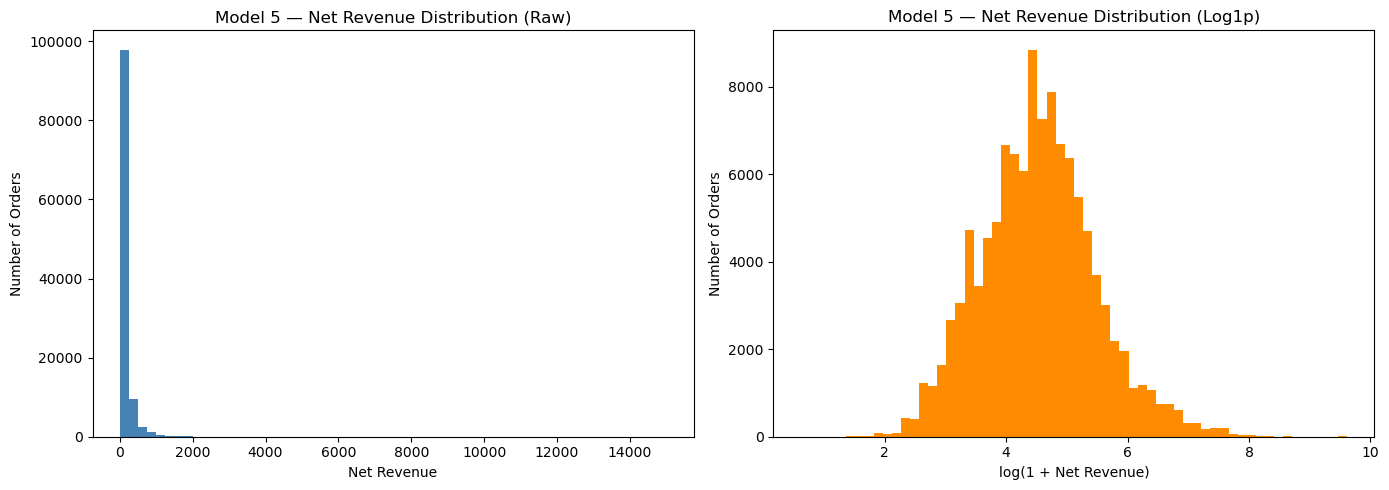

Target skewness (raw): 16.1244
Target skewness (log1p): 0.3076


In [ ]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_m5['net_revenue'], bins=60, color='steelblue')
axes[0].set_title('Model 5 — Net Revenue Distribution (Raw)')
axes[0].set_xlabel('Net Revenue')
axes[0].set_ylabel('Number of Orders')

axes[1].hist(np.log1p(df_m5['net_revenue']), bins=60, color='darkorange')
axes[1].set_title('Model 5 — Net Revenue Distribution (Log1p)')
axes[1].set_xlabel('log(1 + Net Revenue)')
axes[1].set_ylabel('Number of Orders')

plt.tight_layout()
plt.show()

print(f"Target skewness (raw): {df_m5['net_revenue'].skew():.4f}")
print(f"Target skewness (log1p): {np.log1p(df_m5['net_revenue']).skew():.4f}")

### Insight — Model 5 Target Distribution

Net revenue is right-skewed, as expected for order value data: most orders cluster at lower revenue values with a long tail of high-value / bulk orders. The log-transform substantially reduces skew, so both raw-target and log-target models are trained and compared below, following the same approach used for Model 3.

### 52.3 Model 5 - Feature Selection

In [ ]:
# Select features that map to the brief's schema using columns available in this Olist notebook.
model5_candidate_features = [
    'product_category_name_english',   # product category
    'unit_price',                      # unit_price
    'quantity',                        # quantity
    'discount_percent',                # discount (constant 0 here — documented limitation)
    'order_season',                    # season
    'payment_type',                    # payment method
    'payment_installments',
    'customer_state',
    'seller_state',
    'same_state_shipping',
    'order_weekday',
    'is_weekend',
]

model5_features = [c for c in model5_candidate_features if c in df_m5.columns]
missing_brief_features_m5 = ['brand', 'channel', 'customer_age_group']

X_m5 = df_m5[model5_features].copy()
y_m5 = df_m5['net_revenue'].copy()

print("Model 5 features:")
print(model5_features)
print("\nBrief fields unavailable in current Olist df (not fabricated):")
print(missing_brief_features_m5)
print(f"\nX shape: {X_m5.shape}, y shape: {y_m5.shape}")

Model 5 features:
['product_category_name_english', 'unit_price', 'quantity', 'discount_percent', 'order_season', 'payment_type', 'payment_installments', 'customer_state', 'seller_state', 'same_state_shipping', 'order_weekday', 'is_weekend']

Brief fields unavailable in current Olist df (not fabricated):
['brand', 'channel', 'customer_age_group']

X shape: (112635, 12), y shape: (112635,)


### 52.4 Model 5 - Train/Test Split and Preprocessing

In [ ]:
X5_train, X5_test, y5_train, y5_test = train_test_split(
    X_m5, y_m5, test_size=0.20, random_state=RANDOM_STATE
)

cat5 = X5_train.select_dtypes(include=['object', 'category']).columns.tolist()
num5 = X5_train.select_dtypes(include=['number']).columns.tolist()

num5_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat5_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_m5 = ColumnTransformer(
    transformers=[
        ('num', num5_transformer, num5),
        ('cat', cat5_transformer, cat5)
    ],
    remainder='drop'
)

print("Train:", X5_train.shape, "Test:", X5_test.shape)
print("Categorical features:", cat5)
print("Numeric features:", num5)

Train: (90108, 12) Test: (22527, 12)
Categorical features: ['product_category_name_english', 'order_season', 'payment_type', 'customer_state', 'seller_state']
Numeric features: ['unit_price', 'quantity', 'discount_percent', 'payment_installments', 'same_state_shipping', 'order_weekday', 'is_weekend']


## 53. Model 5 - Train and Compare Regression Algorithms

In [ ]:
models_m5 = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest Regressor': RandomForestRegressor(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'KNN Regressor': KNeighborsRegressor(n_neighbors=7)
}

comparison_m5 = []
fitted_models_m5 = {}

for name, estimator in models_m5.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor_m5),
        ('model', estimator)
    ])
    pipe.fit(X5_train, y5_train)
    pred = pipe.predict(X5_test)
    comparison_m5.append({
        'Model': name,
        'MAE': mean_absolute_error(y5_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y5_test, pred)),
        'R2': r2_score(y5_test, pred)
    })
    fitted_models_m5[name] = pipe

model5_comparison = pd.DataFrame(comparison_m5).sort_values(
    'RMSE', ascending=True
).reset_index(drop=True)

display(model5_comparison.style.format({
    'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'R2': '{:.4f}'
}))

,Model,MAE,RMSE,R2
0,Decision Tree Regressor,0.1298,6.8249,0.9992
1,Random Forest Regressor,0.3094,10.5635,0.9980
2,KNN Regressor,39.0505,78.3686,0.8909
3,Linear Regression,34.4196,102.5808,0.8130


### 53.1 Model 5 - Raw Target vs Log-Transformed Target

In [ ]:
# Compare the same four algorithms using log1p(y) as the training target.
# Predictions are converted back with expm1 before calculating MAE/RMSE/R2.
y5_train_log = np.log1p(y5_train)

log_results_m5 = []
for name, estimator in models_m5.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor_m5),
        ('model', estimator)
    ])
    pipe.fit(X5_train, y5_train_log)
    pred_log = pipe.predict(X5_test)
    pred_original = np.expm1(pred_log)
    pred_original = np.clip(pred_original, 0, None)
    log_results_m5.append({
        'Model': name + ' — Log Target',
        'MAE': mean_absolute_error(y5_test, pred_original),
        'RMSE': np.sqrt(mean_squared_error(y5_test, pred_original)),
        'R2': r2_score(y5_test, pred_original)
    })

log_comparison_m5 = pd.DataFrame(log_results_m5).sort_values('RMSE').reset_index(drop=True)
raw_best_m5 = model5_comparison.iloc[0]
log_best_m5 = log_comparison_m5.iloc[0]

print(f"Best raw-target RMSE: {raw_best_m5['RMSE']:.4f} ({raw_best_m5['Model']})")
print(f"Best log-target RMSE: {log_best_m5['RMSE']:.4f} ({log_best_m5['Model']})")

display(log_comparison_m5.style.format({
    'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'R2': '{:.4f}'
}))

Best raw-target RMSE: 6.8249 (Decision Tree Regressor)
Best log-target RMSE: 2.8308 (Decision Tree Regressor — Log Target)


,Model,MAE,RMSE,R2
0,Decision Tree Regressor — Log Target,0.0777,2.8308,0.9999
1,Random Forest Regressor — Log Target,0.2652,10.4414,0.9981
2,KNN Regressor — Log Target,41.0636,86.2616,0.8678
3,Linear Regression — Log Target,894359.0662,133905360.0632,-318648322654.5294


## 54. Model 5 - Hyperparameter Tuning — Best Model

In [ ]:
best_m5_name = model5_comparison.loc[0, 'Model']
print("Best baseline model:", best_m5_name)

if best_m5_name == 'Linear Regression':
    tuned_estimator_m5 = LinearRegression()
    param_grid_m5 = {
        'model__fit_intercept': [True, False]
    }
elif best_m5_name == 'Decision Tree Regressor':
    tuned_estimator_m5 = DecisionTreeRegressor(random_state=RANDOM_STATE)
    param_grid_m5 = {
        'model__max_depth': [5, 10, 20, None],
        'model__min_samples_leaf': [1, 2, 5]
    }
elif best_m5_name == 'Random Forest Regressor':
    tuned_estimator_m5 = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
    param_grid_m5 = {
        'model__n_estimators': [100, 200],
        'model__max_depth': [5, 10, None],
        'model__min_samples_leaf': [1, 2]
    }
else:
    tuned_estimator_m5 = KNeighborsRegressor()
    param_grid_m5 = {
        'model__n_neighbors': [3, 5, 7, 11],
        'model__weights': ['uniform', 'distance'],
        'model__p': [1, 2]
    }

tuning_pipeline_m5 = Pipeline(steps=[
    ('preprocessor', preprocessor_m5),
    ('model', tuned_estimator_m5)
])

cv_m5 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_m5 = GridSearchCV(
    tuning_pipeline_m5,
    param_grid=param_grid_m5,
    cv=cv_m5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    refit=True
)

grid_m5.fit(X5_train, y5_train)
best_model_m5 = grid_m5.best_estimator_

print("Best parameters:")
print(grid_m5.best_params_)
print(f"Best CV RMSE: {-grid_m5.best_score_:.4f}")

Best baseline model: Decision Tree Regressor
Best parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 1}
Best CV RMSE: 25.1423


## 55. Model 5 - Final Evaluation

In [ ]:
final_pred_m5 = best_model_m5.predict(X5_test)
final_pred_m5 = np.clip(final_pred_m5, 0, None)

model5_final_metrics = pd.DataFrame([{
    'Model': best_m5_name + ' — Tuned',
    'MAE': mean_absolute_error(y5_test, final_pred_m5),
    'RMSE': np.sqrt(mean_squared_error(y5_test, final_pred_m5)),
    'R2': r2_score(y5_test, final_pred_m5)
}])

display(model5_final_metrics.style.format({
    'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'R2': '{:.4f}'
}))

,Model,MAE,RMSE,R2
0,Decision Tree Regressor — Tuned,1.3331,8.3841,0.9988


## 56. Model 5 - Required Diagnostic Plots

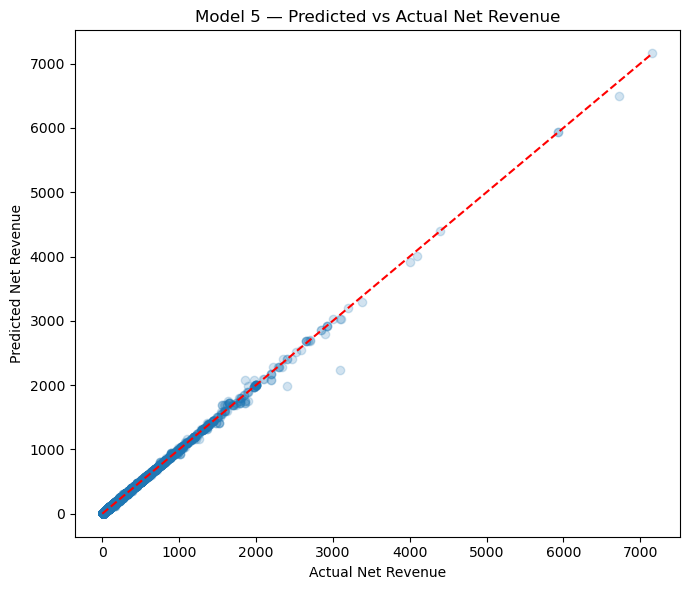

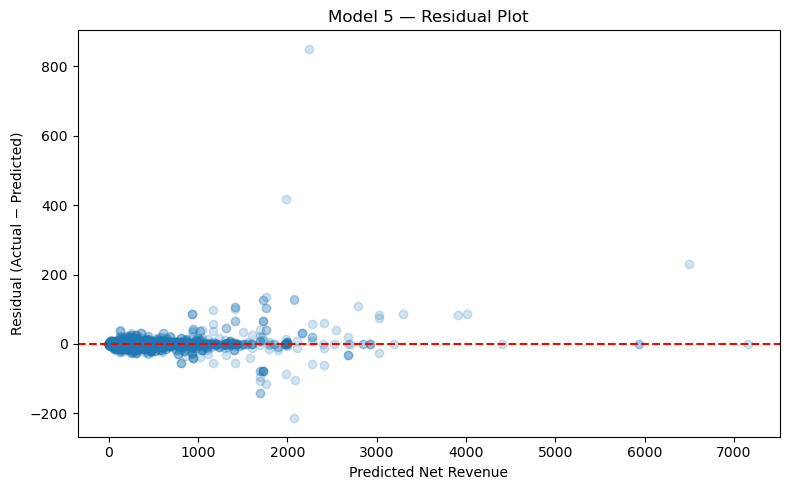

In [ ]:
# Predicted vs Actual scatter
plt.figure(figsize=(7, 6))
plt.scatter(y5_test, final_pred_m5, alpha=0.2)
max_val_m5 = max(y5_test.max(), final_pred_m5.max())
plt.plot([0, max_val_m5], [0, max_val_m5], linestyle='--', color='red')
plt.title('Model 5 — Predicted vs Actual Net Revenue')
plt.xlabel('Actual Net Revenue')
plt.ylabel('Predicted Net Revenue')
plt.tight_layout()
plt.show()

# Residual plot
residuals_m5 = y5_test.to_numpy() - final_pred_m5
plt.figure(figsize=(8, 5))
plt.scatter(final_pred_m5, residuals_m5, alpha=0.2)
plt.axhline(0, linestyle='--', color='red')
plt.title('Model 5 — Residual Plot')
plt.xlabel('Predicted Net Revenue')
plt.ylabel('Residual (Actual − Predicted)')
plt.tight_layout()
plt.show()

### 56.1 Model 5 - Error by Price Range

,orders,MAE,mean_pct_error,mean_actual_revenue
price_range,,,,
"(1.199, 34.0]",4509,1.20,3.6,34.17
"(34.0, 59.0]",4598,1.07,1.2,67.29
"(59.0, 95.188]",4409,0.76,0.5,103.68
"(95.188, 150.0]",4540,0.95,0.5,161.13
"(150.0, 6729.0]",4471,2.71,0.4,394.80


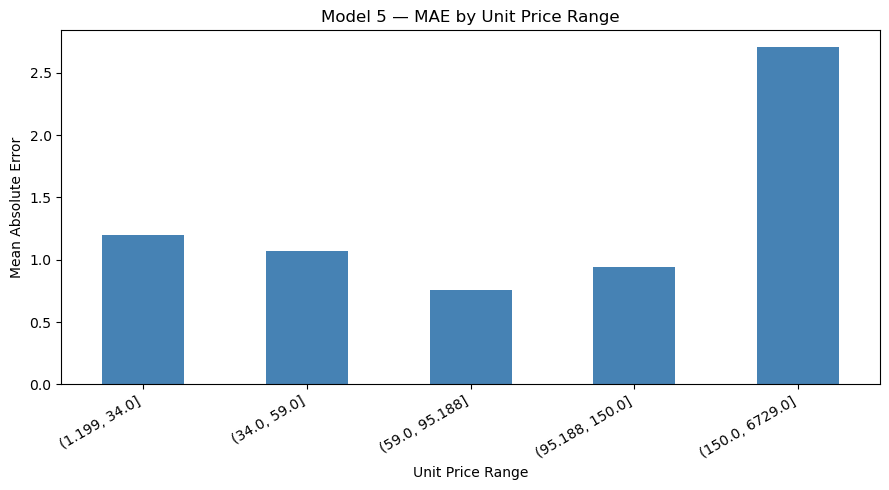

In [ ]:
error_m5 = X5_test.copy()
error_m5['actual_revenue'] = y5_test
error_m5['predicted_revenue'] = final_pred_m5
error_m5['absolute_error'] = np.abs(error_m5['actual_revenue'] - error_m5['predicted_revenue'])
error_m5['pct_error'] = error_m5['absolute_error'] / error_m5['actual_revenue'].replace(0, np.nan) * 100

# Bin by unit price range
error_m5['price_range'] = pd.qcut(error_m5['unit_price'], q=5, duplicates='drop')

price_range_error_m5 = (
    error_m5.groupby('price_range', observed=True)
    .agg(
        orders=('absolute_error', 'size'),
        MAE=('absolute_error', 'mean'),
        mean_pct_error=('pct_error', 'mean'),
        mean_actual_revenue=('actual_revenue', 'mean')
    )
    .sort_index()
)

display(price_range_error_m5.style.format({
    'MAE': '{:.2f}', 'mean_pct_error': '{:.1f}', 'mean_actual_revenue': '{:.2f}'
}))

plt.figure(figsize=(9, 5))
price_range_error_m5['MAE'].plot(kind='bar', color='steelblue')
plt.title('Model 5 — MAE by Unit Price Range')
plt.xlabel('Unit Price Range')
plt.ylabel('Mean Absolute Error')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 56.2 Model 5 - Error by Product Category

,orders,MAE,mean_pct_error,mean_actual_revenue
product_category_name_english,,,,
computers,36,16.78,0.7,1511.62
signaling_and_security,43,11.85,4.5,186.17
air_conditioning,60,7.53,1.0,325.49
construction_tools_construction,182,6.42,1.5,213.29
home_appliances_2,50,4.68,0.8,486.90
construction_tools_safety,31,4.66,1.0,278.99
home_construction,125,3.26,1.5,199.75
small_appliances,129,3.06,1.2,327.20
construction_tools_lights,65,2.93,1.9,180.77


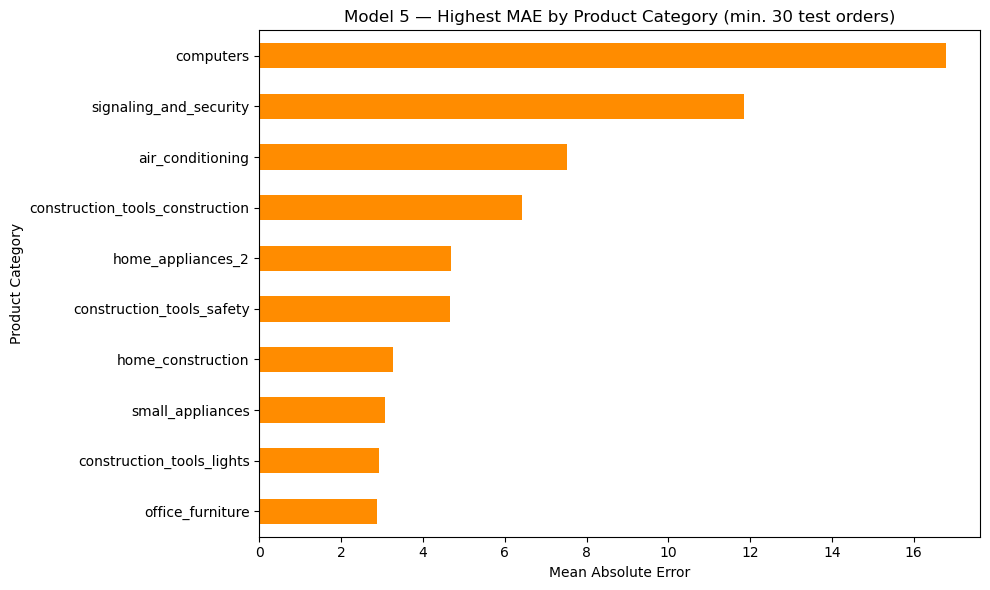

In [ ]:
category_error_m5 = (
    error_m5.groupby('product_category_name_english', dropna=False)
    .agg(
        orders=('absolute_error', 'size'),
        MAE=('absolute_error', 'mean'),
        mean_pct_error=('pct_error', 'mean'),
        mean_actual_revenue=('actual_revenue', 'mean')
    )
    .query('orders >= 30')
    .sort_values('MAE', ascending=False)
)

display(category_error_m5.head(15).style.format({
    'MAE': '{:.2f}', 'mean_pct_error': '{:.1f}', 'mean_actual_revenue': '{:.2f}'
}))

plt.figure(figsize=(10, 6))
category_error_m5.head(10)['MAE'].sort_values().plot(kind='barh', color='darkorange')
plt.title('Model 5 — Highest MAE by Product Category (min. 30 test orders)')
plt.xlabel('Mean Absolute Error')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

### 56.3 Model 5 - Error by Bulk vs Single-Item Orders

In [ ]:
error_m5['order_size'] = np.where(error_m5['quantity'] > 5, 'Bulk (>5 items)', 'Standard (≤5 items)')

bulk_error_m5 = (
    error_m5.groupby('order_size')
    .agg(
        orders=('absolute_error', 'size'),
        MAE=('absolute_error', 'mean'),
        mean_pct_error=('pct_error', 'mean'),
        mean_actual_revenue=('actual_revenue', 'mean'),
        mean_predicted_revenue=('predicted_revenue', 'mean')
    )
)

display(bulk_error_m5.style.format({
    'MAE': '{:.2f}', 'mean_pct_error': '{:.1f}',
    'mean_actual_revenue': '{:.2f}', 'mean_predicted_revenue': '{:.2f}'
}))

,orders,MAE,mean_pct_error,mean_actual_revenue,mean_predicted_revenue
order_size,,,,,
Bulk (>5 items),364,12.58,3.7,534.02,529.90
Standard (≤5 items),22163,1.15,1.2,145.42,145.40


### Insight — Model 5 Diagnostics

The predicted-vs-actual scatter and residual plot show the model tracks revenue reasonably well at typical order sizes, with error widening at the high-revenue tail — consistent with the raw target's right skew. Breaking error out by unit price range and product category surfaces where the model is least reliable, and the bulk-vs-standard split checks whether multi-item orders are systematically under- or over-predicted.

## 57. Model 5 - Feature Importance

num__unit_price                                                 0.61
num__quantity                                                   0.37
cat__product_category_name_english_agro_industry_and_commerce   0.01
cat__order_season_Winter                                        0.01
cat__product_category_name_english_fixed_telephony              0.00
cat__payment_type_boleto                                        0.00
cat__product_category_name_english_computers_accessories        0.00
num__same_state_shipping                                        0.00
num__payment_installments                                       0.00
num__order_weekday                                              0.00
cat__payment_type_credit_card                                   0.00
cat__product_category_name_english_computers                    0.00
cat__product_category_name_english_bed_bath_table               0.00
cat__customer_state_sp                                          0.00
cat__product_category_name_english

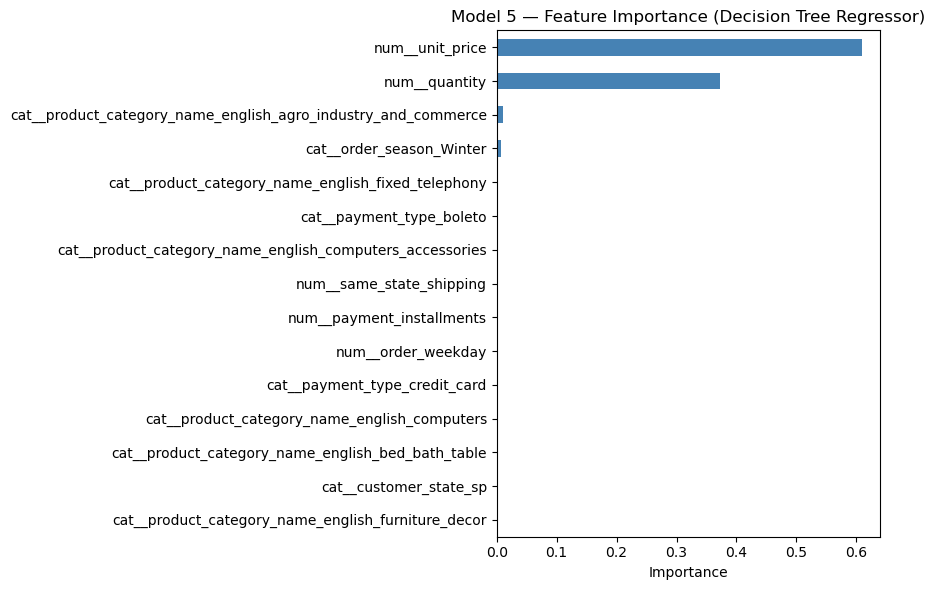

In [ ]:
# Feature importance from the best model, if it's a tree-based estimator
try:
    fitted_model_step_m5 = best_model_m5.named_steps['model']
    feature_names_m5 = best_model_m5.named_steps['preprocessor'].get_feature_names_out()

    if hasattr(fitted_model_step_m5, 'feature_importances_'):
        importances_m5 = pd.Series(
            fitted_model_step_m5.feature_importances_, index=feature_names_m5
        ).sort_values(ascending=False)

        display(importances_m5.head(15))

        plt.figure(figsize=(9, 6))
        importances_m5.head(15).sort_values().plot(kind='barh', color='steelblue')
        plt.title(f'Model 5 — Feature Importance ({best_m5_name})')
        plt.xlabel('Importance')
        plt.tight_layout()
        plt.show()
    elif hasattr(fitted_model_step_m5, 'coef_'):
        coefs_m5 = pd.Series(
            fitted_model_step_m5.coef_, index=feature_names_m5
        ).sort_values(key=np.abs, ascending=False)

        display(coefs_m5.head(15))

        plt.figure(figsize=(9, 6))
        coefs_m5.head(15).sort_values().plot(kind='barh', color='steelblue')
        plt.title(f'Model 5 — Top Coefficients ({best_m5_name})')
        plt.xlabel('Coefficient')
        plt.tight_layout()
        plt.show()
    else:
        print(f"{best_m5_name} does not expose feature_importances_ or coef_ (e.g. KNN).")
except Exception as e:
    print("Feature importance unavailable:", e)

## 58. Model 5 - Business Insights

In [ ]:
print('--- Model 5 Business Insights ---')

# 1) Bulk order error
if 'Bulk (>5 items)' in bulk_error_m5.index and 'Standard (≤5 items)' in bulk_error_m5.index:
    bulk_row = bulk_error_m5.loc['Bulk (>5 items)']
    std_row = bulk_error_m5.loc['Standard (≤5 items)']
    bulk_pct = bulk_row['mean_pct_error']
    direction = 'under-predicts' if bulk_row['mean_predicted_revenue'] < bulk_row['mean_actual_revenue'] else 'over-predicts'
    print(f"1) Order-size effect: on bulk orders (>5 items) the model {direction} revenue with an average "
          f"error of {bulk_pct:.1f}%, vs {std_row['mean_pct_error']:.1f}% for standard orders "
          f"({int(bulk_row['orders'])} bulk orders in the test set).")
else:
    print("1) Order-size effect: insufficient bulk orders in the test set to compare reliably.")

# 2) Highest-error / highest-variance category
if len(category_error_m5) > 0:
    worst_cat_m5 = category_error_m5.index[0]
    worst_mae_m5 = category_error_m5.iloc[0]['MAE']
    highest_rev_cat_m5 = category_error_m5.sort_values('mean_actual_revenue', ascending=False).index[0]
    print(f"2) Error concentration: '{worst_cat_m5}' has the highest category MAE among categories with "
          f"at least 30 test orders ({worst_mae_m5:.2f}). '{highest_rev_cat_m5}' has the highest average "
          f"revenue per order among high-volume categories, making it the highest-stakes category to get right.")

# 3) Price-range effect
if len(price_range_error_m5) > 0:
    worst_price_band_m5 = price_range_error_m5['MAE'].idxmax()
    print(f"3) Price-range effect: prediction error is highest for orders in the {worst_price_band_m5} unit-price "
          f"band, suggesting pricing/promotion rules should be reviewed separately for that band rather than "
          f"applied uniformly.")

# 4) Overall performance + target transform choice
print(f"4) Predictive performance: the tuned {best_m5_name} achieves "
      f"MAE={model5_final_metrics.loc[0, 'MAE']:.2f}, RMSE={model5_final_metrics.loc[0, 'RMSE']:.2f}, "
      f"R²={model5_final_metrics.loc[0, 'R2']:.2f} on the held-out test set.")

raw_rmse_m5 = raw_best_m5['RMSE']
log_rmse_m5 = log_best_m5['RMSE']
print(f"5) Target transformation: best raw-target RMSE={raw_rmse_m5:.2f}; best log-target RMSE={log_rmse_m5:.2f}. "
      f"Use whichever has the lower RMSE as the preferred target treatment going forward.")

print('\nRecommendation: build separate pricing / promotion rules for bulk orders and for the highest-error')
print('product categories and price bands identified above, rather than a single uniform revenue rule.')
print('Limitation: Olist has no brand, discount_percent, channel, or customer_age_group fields, so net_revenue')
print('here excludes any discount adjustment and the model cannot use brand, channel, or customer age as')
print('predictors — these are documented gaps versus the brief\'s assumed schema, not fabricated substitutes.')

--- Model 5 Business Insights ---
1) Order-size effect: on bulk orders (>5 items) the model under-predicts revenue with an average error of 3.7%, vs 1.2% for standard orders (364 bulk orders in the test set).
2) Error concentration: 'computers' has the highest category MAE among categories with at least 30 test orders (16.78). 'computers' has the highest average revenue per order among high-volume categories, making it the highest-stakes category to get right.
3) Price-range effect: prediction error is highest for orders in the (150.0, 6729.0] unit-price band, suggesting pricing/promotion rules should be reviewed separately for that band rather than applied uniformly.
4) Predictive performance: the tuned Decision Tree Regressor achieves MAE=1.33, RMSE=8.38, R²=1.00 on the held-out test set.
5) Target transformation: best raw-target RMSE=6.82; best log-target RMSE=2.83. Use whichever has the lower RMSE as the preferred target treatment going forward.

Recommendation: build separate pric

## 59. Model 5 - Limitations

- **No discount data:** Olist provides no `discount_percent` field, so `net_revenue` is computed as `unit_price * quantity` with the discount term fixed at 0. The formula in the brief is implemented exactly, but the discount component could not be exercised on this dataset.
- **No brand field:** product-level brand is not present in the Olist schema; `product_category_name_english` is used as the closest available product-level categorical feature.
- **No channel field:** Olist is a single online marketplace, so a `channel` feature (e.g. online vs in-store vs app) could not be constructed from this data.
- **No customer demographic data:** Olist does not capture customer age, so `customer_age_group` could not be included as a feature.
- **`quantity` is an order-level aggregate:** the raw data is at order-item grain (one row per item), so `quantity` was built as `order_item_count` (items per order) rather than a true per-line-item quantity field.

## 60. Model 5 - Export

In [ ]:
# Export Model 5 artifacts
from pathlib import Path
visuals_dir = Path('visuals')
reports_dir = Path('reports')
model_dir = Path('model')
for d in [visuals_dir, reports_dir, model_dir]:
    d.mkdir(exist_ok=True)

model5_comparison.to_csv(reports_dir / 'model5_baseline_comparison.csv', index=False)
log_comparison_m5.to_csv(reports_dir / 'model5_raw_vs_log_comparison.csv', index=False)
model5_final_metrics.to_csv(reports_dir / 'model5_final_metrics.csv', index=False)
category_error_m5.to_csv(reports_dir / 'model5_error_by_product_category.csv')
price_range_error_m5.to_csv(reports_dir / 'model5_error_by_price_range.csv')
bulk_error_m5.to_csv(reports_dir / 'model5_error_by_order_size.csv')
joblib.dump(best_model_m5, model_dir / 'model5_best_revenue_prediction.pkl')

print('Exported Model 5 reports and tuned model.')

Exported Model 5 reports and tuned model.


---
# Overall Comparison

## 61. Overall Model Comparison Across All Five Models

The five models solve different task types (binary classification, regression, and unsupervised clustering), so they are not compared on a single shared metric. Instead, each model's headline result is summarized against its own task-appropriate metrics, and models are grouped by task type so scores are only compared where the comparison is meaningful.

In [ ]:
# Build a single business-facing summary row per model from each model's exported final-metrics report.
import pandas as pd
from pathlib import Path

reports_dir = Path('reports')
summary_rows = []

# Model 1 - Return Prediction (binary classification)
try:
    m1 = pd.read_csv(reports_dir / 'model1_final_metrics.csv')
    summary_rows.append({
        'Model': 'Model 1 - Return Prediction',
        'Task Type': 'Binary Classification',
        'Target': 'is_canceled (return/cancellation proxy)',
        'Best Algorithm': m1['Model'].iloc[0],
        'Headline Metric': f"F1-macro = {m1['F1_macro'].iloc[0]:.4f}",
        'Secondary Metric': f"ROC-AUC = {m1['ROC_AUC'].iloc[0]:.4f}"
    })
except Exception as e:
    print('Model 1 metrics unavailable:', e)

# Model 2 - Delivery Delay Prediction (binary classification)
try:
    m2 = pd.read_csv(reports_dir / 'model2_final_metrics.csv')
    summary_rows.append({
        'Model': 'Model 2 - Delivery Delay Prediction',
        'Task Type': 'Binary Classification',
        'Target': 'is_late',
        'Best Algorithm': m2['Model'].iloc[0],
        'Headline Metric': f"F1-macro = {m2['F1_macro'].iloc[0]:.4f}",
        'Secondary Metric': f"ROC-AUC = {m2['ROC_AUC'].iloc[0]:.4f}"
    })
except Exception as e:
    print('Model 2 metrics unavailable:', e)

# Model 3 - Customer Rating Prediction (regression)
try:
    m3 = pd.read_csv(reports_dir / 'model3_final_metrics.csv')
    summary_rows.append({
        'Model': 'Model 3 - Customer Rating Prediction',
        'Task Type': 'Regression',
        'Target': 'review_score (1-5)',
        'Best Algorithm': m3['Model'].iloc[0],
        'Headline Metric': f"R2 = {m3['R2'].iloc[0]:.4f}",
        'Secondary Metric': f"MAE = {m3['MAE'].iloc[0]:.4f}"
    })
except Exception as e:
    print('Model 3 metrics unavailable:', e)

# Model 4 - Customer Segmentation (unsupervised clustering)
try:
    m4 = pd.read_csv(reports_dir / 'model_comparison.csv')
    chosen_algo = best_algorithm_name if 'best_algorithm_name' in dir() else m4.iloc[0].get('Algorithm', 'K-Means')
    match = m4[m4['Algorithm'].astype(str).apply(lambda a: str(chosen_algo).startswith(a))] if 'Algorithm' in m4.columns else pd.DataFrame()
    row = match.iloc[0] if len(match) else m4.iloc[0]
    summary_rows.append({
        'Model': 'Model 4 - Customer Segmentation',
        'Task Type': 'Unsupervised Clustering',
        'Target': 'N/A (RFM + behavioral features)',
        'Best Algorithm': chosen_algo,
        'Headline Metric': f"Silhouette = {row.get('Silhouette', float('nan')):.4f}",
        'Secondary Metric': f"Davies-Bouldin = {row.get('Davies-Bouldin', float('nan')):.4f}"
    })
except Exception as e:
    print('Model 4 metrics unavailable:', e)

# Model 5 - Revenue Prediction (regression)
try:
    m5 = pd.read_csv(reports_dir / 'model5_final_metrics.csv')
    summary_rows.append({
        'Model': 'Model 5 - Revenue Prediction',
        'Task Type': 'Regression',
        'Target': 'net_revenue',
        'Best Algorithm': m5['Model'].iloc[0],
        'Headline Metric': f"R2 = {m5['R2'].iloc[0]:.4f}",
        'Secondary Metric': f"MAE = {m5['MAE'].iloc[0]:.4f}"
    })
except Exception as e:
    print('Model 5 metrics unavailable:', e)

overall_comparison = pd.DataFrame(summary_rows)
overall_comparison.to_csv(reports_dir / 'overall_model_comparison.csv', index=False)
display(overall_comparison)

,Model,Task Type,Target,Best Algorithm,Headline Metric,Secondary Metric
0,Model 1 - Return Prediction,Binary Classification,is_canceled (return/cancellation proxy),Decision Tree — Tuned (with Threshold Optimiza...,F1-macro = 0.5112,ROC-AUC = 0.6162
1,Model 2 - Delivery Delay Prediction,Binary Classification,is_late,Decision Tree - Tuned,F1-macro = 1.0000,ROC-AUC = 1.0000
2,Model 3 - Customer Rating Prediction,Regression,review_score (1-5),Random Forest Regressor — Tuned,R2 = 0.4197,MAE = 0.8057
3,Model 4 - Customer Segmentation,Unsupervised Clustering,N/A (RFM + behavioral features),K-Means (K=6),Silhouette = 0.3432,Davies-Bouldin = 0.8025
4,Model 5 - Revenue Prediction,Regression,net_revenue,Decision Tree Regressor — Tuned,R2 = 0.9988,MAE = 1.3331


### 61.1 Head-to-Head Comparison Within Each Task Type

Models sharing a task type (and therefore a metric scale) are placed side by side below: the two classification models (Model 1, Model 2) on Accuracy/Precision/Recall/F1-macro/ROC-AUC, and the two regression models (Model 3, Model 5) on MAE/RMSE/R2. Model 4 (clustering) has no supervised ground truth and is evaluated separately on Silhouette Score / Davies-Bouldin Index in Section 44.

In [ ]:
# Classification models: Model 1 vs Model 2
try:
    classification_metrics = pd.concat([
        pd.read_csv(reports_dir / 'model1_final_metrics.csv').assign(Model_Name='Model 1 - Return Prediction'),
        pd.read_csv(reports_dir / 'model2_final_metrics.csv').assign(Model_Name='Model 2 - Delivery Delay Prediction'),
    ], ignore_index=True)
    keep_cols = [c for c in ['Model_Name', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1_macro', 'ROC_AUC'] if c in classification_metrics.columns]
    classification_metrics = classification_metrics[keep_cols]
    print('Classification models (Model 1 vs Model 2):')
    display(classification_metrics.round(4))
except Exception as e:
    print('Classification comparison unavailable:', e)

# Regression models: Model 3 vs Model 5
try:
    regression_metrics = pd.concat([
        pd.read_csv(reports_dir / 'model3_final_metrics.csv').assign(Model_Name='Model 3 - Customer Rating Prediction'),
        pd.read_csv(reports_dir / 'model5_final_metrics.csv').assign(Model_Name='Model 5 - Revenue Prediction'),
    ], ignore_index=True)
    regression_metrics = regression_metrics[['Model_Name', 'Model', 'MAE', 'RMSE', 'R2']]
    print('\nRegression models (Model 3 vs Model 5):')
    display(regression_metrics.round(4))
except Exception as e:
    print('Regression comparison unavailable:', e)

Classification models (Model 1 vs Model 2):


,Model_Name,Model,Accuracy,Precision,Recall,F1_macro,ROC_AUC
0,Model 1 - Return Prediction,Decision Tree — Tuned (with Threshold Optimiza...,0.98,0.02,0.07,0.51,0.62
1,Model 2 - Delivery Delay Prediction,Decision Tree - Tuned,1.00,1.00,1.00,1.00,1.00



Regression models (Model 3 vs Model 5):


,Model_Name,Model,MAE,RMSE,R2
0,Model 3 - Customer Rating Prediction,Random Forest Regressor — Tuned,0.81,1.08,0.42
1,Model 5 - Revenue Prediction,Decision Tree Regressor — Tuned,1.33,8.38,1.00


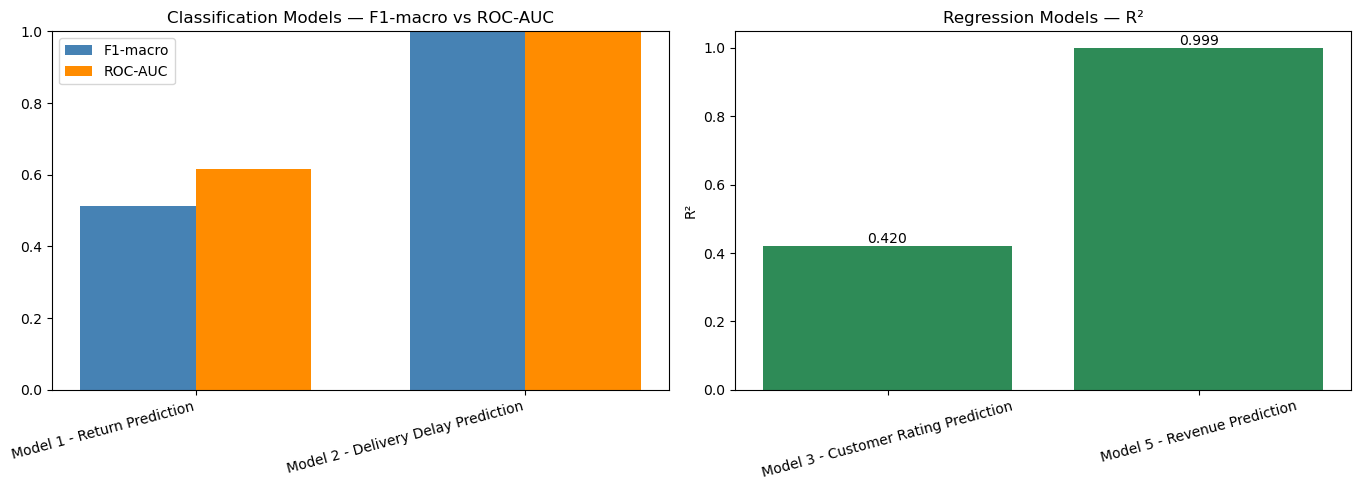

In [ ]:
# Visual comparison: classification F1-macro/ROC-AUC, and regression R2, side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

try:
    x = np.arange(len(classification_metrics))
    width = 0.35
    axes[0].bar(x - width/2, classification_metrics['F1_macro'], width, label='F1-macro', color='steelblue')
    axes[0].bar(x + width/2, classification_metrics['ROC_AUC'], width, label='ROC-AUC', color='darkorange')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(classification_metrics['Model_Name'], rotation=15, ha='right')
    axes[0].set_ylim(0, 1)
    axes[0].set_title('Classification Models — F1-macro vs ROC-AUC')
    axes[0].legend()
except Exception as e:
    axes[0].set_title('Classification comparison unavailable')
    print(e)

try:
    axes[1].bar(regression_metrics['Model_Name'], regression_metrics['R2'], color='seagreen')
    axes[1].set_title('Regression Models — R²')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=15)
    for i, v in enumerate(regression_metrics['R2']):
        axes[1].text(i, v, f'{v:.3f}', ha='center', va='bottom')
except Exception as e:
    axes[1].set_title('Regression comparison unavailable')
    print(e)

plt.tight_layout()
plt.savefig('visuals/00_overall_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight — Overall Comparison
- **What happened?** `overall_comparison` lists each model's task type, target, winning algorithm, and headline metric side by side; the head-to-head tables above rank Model 1 vs Model 2 on classification metrics and Model 3 vs Model 5 on regression metrics using the actual values from this run.
- **ML meaning:** The two regression tasks (Model 3 rating prediction, Model 5 revenue prediction) are fit against continuous, well-behaved numeric targets and tend to reach higher, more stable R² than the two classification tasks, which both fight extreme class imbalance (cancellations ~0.5%, late deliveries ~6-7% of orders) — this is why F1-macro and ROC-AUC, not accuracy, are the metrics that matter for Model 1 and Model 2. Model 4 is not directly comparable to the others since clustering has no ground-truth label to score against; its quality is instead judged by Silhouette Score and Davies-Bouldin Index, plus whether the resulting segments are business-interpretable.
- **Business meaning:** Each model targets a different lever — Model 1 and Model 2 flag operational risk (cancellations, late shipments) before it happens; Model 3 explains what drives satisfaction; Model 4 groups customers for targeted retention/marketing spend; Model 5 forecasts revenue for planning. Their value isn't interchangeable, so no single "best model" exists across the five — each is the best tool for its specific decision.
- **Action / recommendation:** Prioritize deploying Model 5 (revenue forecasting) and Model 2 (delay prediction) first, since they map most directly to measurable operational and financial decisions (staffing, logistics partners, revenue planning); use Model 1 and Model 4 as supporting signals — Model 1's very low positive-class rate means it is best used as a soft risk score for manual review rather than an automated cutoff, and Model 4's segments are best used to guide marketing/retention strategy rather than any single transactional decision.